# §0 — Imports y configuración global

Se importan todas las librerías en una sola celda. La semilla RANDOM_STATE = 42
garantiza reproducibilidad en todos los modelos, samplers y búsquedas de
hiperparámetros.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, sys

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Preprocesamiento y evaluación
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, average_precision_score,
    f1_score, recall_score, precision_score, accuracy_score,
)
from sklearn.inspection import permutation_importance

# Balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

from scipy import stats
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN GLOBAL
# ═══════════════════════════════════════════════════════════════════════════════
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DATA_PATH    = '../data/dataset_completo_final.csv'

# Paleta de colores por familia de modelo
COLORS = {'LR': '#1F77B4', 'DT': '#FF7F0E', 'RF': '#2CA02C', 'XGB': '#D62728'}
BALANCEO_COLORS = {'none': '#555555', 'smote': '#9B59B6', 'smoteenn': '#16A085'}

# ═══════════════════════════════════════════════════════════════════════════════
# HELPER: IMPRESIÓN SEGURA EN WINDOWS (evita UnicodeEncodeError con cp1252)
# ═══════════════════════════════════════════════════════════════════════════════
class SP:
    @staticmethod
    def out(msg=''):
        try:
            print(msg)
        except UnicodeEncodeError:
            print(str(msg).encode('ascii', 'replace').decode('ascii'))

SP.out("Configuracion completada. RANDOM_STATE=42")

Configuracion completada. RANDOM_STATE=42


# §1 — Carga y preparación del dataset

## 1.1 Descripción del dataset
El dataset integra 5 semestres (202320–202520) del curso **IIND-2104**, combinando notas académicas y métricas de engagement de la plataforma Bloque Neón. Existen dos eras pedagógicas con estructuras de evaluación distintas:

| Era | Semestres | Evaluación continua |
| :--- | :--- | :--- |
| **formato_antiguo** | 202320, 202410 | Proyecto grupal (fases) + talleres grupales |
| **formato_nuevo** | 202420, 202510, 202520 | AMs individuales + quices individuales |

**Variable objetivo:** `estado` → binario (REPROBÓ = 1, APROBÓ = 0).

---

## 1.2 Filtros de la población objetivo
Se aplican tres filtros secuenciales para obtener el subconjunto de modelado. Solo se incluyen estudiantes activos con engagement registrado:

| Filtro | Criterio | Justificación |
| :--- | :--- | :--- |
| **F1** | `estado` ∈ {APROBÓ, REPROBÓ} | RETIRADO y SIN_NOTA tienen trayectoria cualitativamente distinta y features incompletas |
| **F2** | `total_tiempo_hrs` > 0 | Sin engagement no hay información de comportamiento en Bloque Neón |
| **F3** | `parcial_1` no nulo | Variable obligatoria en CP1 y CP2; ausencia indica estudiante no evaluado |

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CARGA
# ═══════════════════════════════════════════════════════════════════════════════
try:
    df_raw = pd.read_csv(DATA_PATH, encoding='utf-8')
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_PATH, encoding='latin-1')

SP.out(f"Shape original  : {df_raw.shape}")
SP.out(f"Estado dist.    :\n{df_raw['estado'].value_counts(dropna=False).to_string()}")

# F1 — estados modelables
df = df_raw[df_raw['estado'].isin(['APROBÓ', 'REPROBÓ'])].copy()
SP.out(f"\n[F1] Activos : N={len(df)} | Excl. RETIRADO={( df_raw['estado']=='RETIRADO').sum()} | SIN_NOTA={(df_raw['estado']=='SIN_NOTA').sum()}")

# F2 — engagement registrado
n0 = len(df)
df = df[df['total_tiempo_hrs'].notna() & (df['total_tiempo_hrs'] > 0)].copy()
SP.out(f"[F2] Eng>0   : N={len(df)} | Excluidos={n0-len(df)}")

# F3 — parcial_1 disponible
n0 = len(df)
df = df[df['parcial_1'].notna()].copy()
SP.out(f"[F3] p1 ok   : N={len(df)} | Excluidos={n0-len(df)}")

# Target binario
df['target'] = (df['estado'] == 'REPROBÓ').astype(int)

SP.out(f"\n{'─'*55}")
SP.out(f"  DATASET FINAL : N = {len(df)}")
SP.out(f"  APROBÓ  (0)   : {(df['target']==0).sum()} ({100*(df['target']==0).mean():.1f}%)")
SP.out(f"  REPROBÓ (1)   : {(df['target']==1).sum()} ({100*(df['target']==1).mean():.1f}%)")
SP.out(f"{'─'*55}")

# Tabla por semestre
tab = df.groupby('semestre')['target'].value_counts().unstack(fill_value=0)
tab.columns = ['APROBÓ','REPROBÓ']
tab['Total'] = tab.sum(axis=1)
tab['%Rep']  = (tab['REPROBÓ']/tab['Total']*100).round(1)
SP.out(f"\nDistribucion por semestre:\n{tab.to_string()}")

Shape original  : (764, 77)
Estado dist.    :
estado
APROBÓ      413
RETIRADO    164
REPROBÓ     141
SIN_NOTA     46

[F1] Activos : N=554 | Excl. RETIRADO=164 | SIN_NOTA=46
[F2] Eng>0   : N=505 | Excluidos=49
[F3] p1 ok   : N=505 | Excluidos=0

───────────────────────────────────────────────────────
  DATASET FINAL : N = 505
  APROBÓ  (0)   : 375 (74.3%)
  REPROBÓ (1)   : 130 (25.7%)
───────────────────────────────────────────────────────

Distribucion por semestre:
          APROBÓ  REPROBÓ  Total  %Rep
semestre                              
202320        88       19    107  17.8
202410        59       13     72  18.1
202420        89       33    122  27.0
202510        70       45    115  39.1
202520        69       20     89  22.5


## 1.3 Variables derivadas
Las variables derivadas capturan dimensiones que las features brutas no expresan directamente. Solo se crean features causalmente válidas para cada checkpoint: **ninguna derivada de CP2 se usa en sets de CP1**.

| Feature derivada | Fórmula | Interpretación |
| :--- | :--- | :--- |
| **era_encoded** | `formato_nuevo` → 1, `antiguo` → 0 | Contexto pedagógico del semestre |
| **log_eng_p1** | $ln(1 + \text{engagement\_hasta\_p1})$ | Captura rendimientos decrecientes del tiempo de estudio |
| **log_eng_p2** | $ln(1 + \text{engagement\_hasta\_p2})$ | Ídem para material del P2 (solo CP2) |
| **p1_vs_media** | $(p1 - \mu_{sem}) / \sigma_{sem}$ | Posición relativa del estudiante en su cohorte |
| **delta_p2_p1** | $parcial\_2 - parcial\_1$ | Tendencia académica entre checkpoints (solo CP2) |
| **intensidad_p1** | $(\text{eng\_p1} \times 60) / \text{visitas\_p1}$ | Minutos por visita al material de P1 (calidad de sesión) |
| **ratio_vt_p1** | $\text{visitas\_p1} / \text{temas\_unicos\_p1}$ | Revisitas por tema distinto (profundidad de repaso) |



In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# ENCODING Y DERIVADAS
# ═══════════════════════════════════════════════════════════════════════════════
df['era_encoded'] = (df['era'] == 'formato_nuevo').astype(int)

df['log_eng_p1']  = np.log1p(df['engagement_hasta_p1'])
df['log_eng_p2']  = np.log1p(df['engagement_hasta_p2'])

df['p1_vs_media'] = df.groupby('semestre')['parcial_1'].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-6))

df['delta_p2_p1'] = df['parcial_2'] - df['parcial_1']

df['intensidad_p1'] = np.where(
    df['parcial_1_visitas'] > 0,
    df['engagement_hasta_p1'] * 60 / df['parcial_1_visitas'], 0.0)

df['ratio_vt_p1'] = np.where(
    df['parcial_1_temas_unicos'] > 0,
    df['parcial_1_visitas'] / df['parcial_1_temas_unicos'], 0.0)

DERIVADAS = ['log_eng_p1','log_eng_p2','p1_vs_media',
             'delta_p2_p1','intensidad_p1','ratio_vt_p1']
SP.out("\n[DERIVADAS]")
for f in DERIVADAS:
    SP.out(f"  {f:<22}: mean={df[f].mean():7.3f}  std={df[f].std():6.3f}  nulls={df[f].isna().sum()}")


[DERIVADAS]
  log_eng_p1            : mean=  2.080  std= 0.936  nulls=0
  log_eng_p2            : mean=  2.705  std= 0.929  nulls=0
  p1_vs_media           : mean=  0.000  std= 0.996  nulls=0
  delta_p2_p1           : mean=  0.234  std= 1.111  nulls=0
  intensidad_p1         : mean= 14.295  std=11.578  nulls=0
  ratio_vt_p1           : mean=  3.674  std= 2.601  nulls=0


# §2 — Análisis univariante de features candidatas

## 2.1 Método y criterios de inclusión/exclusión
El **AUC de Mann-Whitney** (equivalente al AUC-ROC univariante) mide el poder discriminatorio de cada variable de forma individual y no paramétrica. Se complementa con el **p-valor** (significancia estadística) y la **d de Cohen** (tamaño de efecto).

### Criterios de decisión aplicados en este proyecto:

| AUC univariante | Significancia | Decisión |
| :--- | :--- | :--- |
| **≥ 0.75** | cualquiera | Incluir siempre (discriminación alta) |
| **0.60 – 0.74** | $p < 0.05$ | Incluir (discriminación moderada) |
| **0.55 – 0.59** | $p < 0.05$ | Incluir en sets grandes, evaluar colinealidad |
| **< 0.55 o $p \geq 0.05$** | — | **Excluir** de todos los sets |


Feature                                   AUC         p       d   Sig  Nivel
───────────────────────────────────────────────────────────────────────────
parcial_2                               0.861    0.0000   1.522   ***  ALTO
p1_vs_media                             0.816    0.0000   1.288   ***  ALTO
parcial_1                               0.814    0.0000   1.268   ***  ALTO
promedio_ams                            0.729    0.0000   0.854   ***  MED
total_tiempo_hrs                        0.615    0.0001   0.177   ***  MED
log_eng_p1                              0.602    0.0005   0.372   ***  MED
engagement_hasta_p1                     0.602    0.0005   0.300   ***  MED
parcial_1_modulos_unicos                0.601    0.0005   0.357   ***  MED
engagement_hasta_p2                     0.599    0.0008   0.236   ***  BAJO
log_eng_p2                              0.599    0.0008   0.366   ***  BAJO
total_modulos                           0.595    0.0012   0.343    **  BAJO
promedio_tiempo

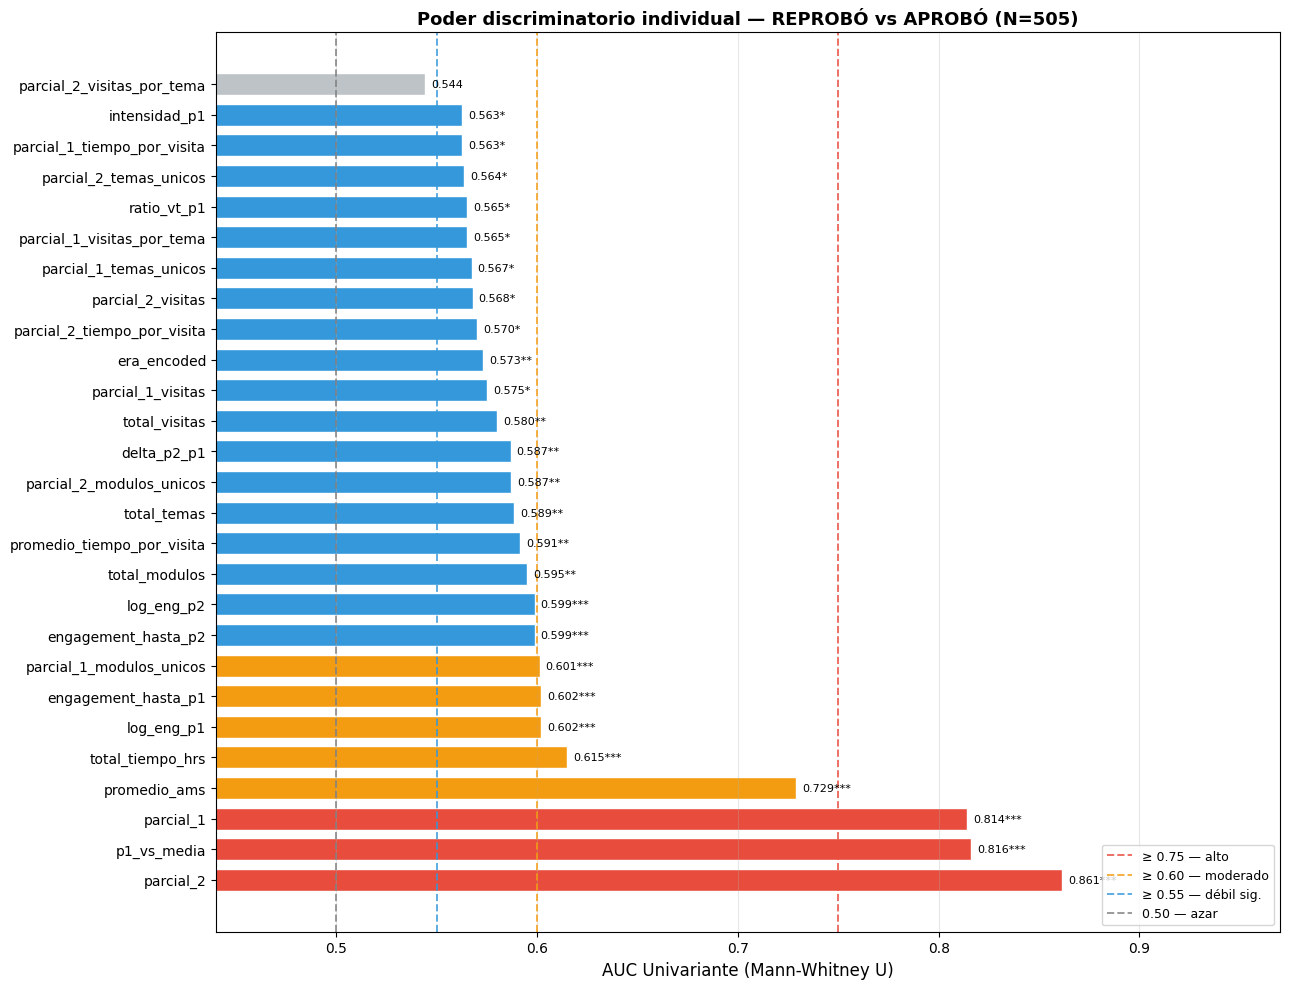

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# AUC UNIVARIANTE
# ═══════════════════════════════════════════════════════════════════════════════
def univariate_stats(df, feature):
    sub = df[[feature, 'target']].dropna()
    if len(sub) < 50: return None
    auc = roc_auc_score(sub['target'], sub[feature])
    auc = max(auc, 1 - auc)
    a = sub[sub['target']==1][feature]
    b = sub[sub['target']==0][feature]
    _, pval = stats.mannwhitneyu(a, b, alternative='two-sided')
    d = abs(a.mean() - b.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2 + 1e-9)
    return {'feature': feature, 'AUC': auc, 'p_valor': pval, 'd_Cohen': d, 'N': len(sub)}

CANDIDATAS = [
    'parcial_1', 'parcial_2', 'promedio_ams',
    'engagement_hasta_p1', 'engagement_hasta_p2', 'log_eng_p1', 'log_eng_p2',
    'total_tiempo_hrs', 'total_visitas', 'total_temas', 'total_modulos',
    'parcial_1_modulos_unicos', 'parcial_1_temas_unicos', 'parcial_1_visitas',
    'parcial_1_visitas_por_tema', 'parcial_1_tiempo_por_visita',
    'parcial_2_modulos_unicos', 'parcial_2_temas_unicos', 'parcial_2_visitas',
    'parcial_2_visitas_por_tema', 'parcial_2_tiempo_por_visita',
    'promedio_tiempo_por_visita', 'p1_vs_media', 'delta_p2_p1',
    'intensidad_p1', 'ratio_vt_p1', 'era_encoded',
]

rows_uni = [r for f in CANDIDATAS if (r := univariate_stats(df, f)) is not None]
df_uni = pd.DataFrame(rows_uni).sort_values('AUC', ascending=False).reset_index(drop=True)

SP.out(f"\n{'Feature':<38} {'AUC':>6} {'p':>9} {'d':>7} {'Sig':>5}  {'Nivel'}")
SP.out('─' * 75)
for _, row in df_uni.iterrows():
    sig   = '***' if row['p_valor']<0.001 else '**' if row['p_valor']<0.01 else '*' if row['p_valor']<0.05 else 'n.s.'
    nivel = ('EXCL' if (row['AUC']<0.55 or row['p_valor']>0.05)
             else 'ALTO' if row['AUC']>=0.75
             else 'MED' if row['AUC']>=0.60 else 'BAJO')
    SP.out(f"{row['feature']:<38} {row['AUC']:>6.3f} {row['p_valor']:>9.4f} {row['d_Cohen']:>7.3f} {sig:>5}  {nivel}")

# ── Gráfica ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
palette = ['#E74C3C' if a>=0.75 else '#F39C12' if a>=0.60
           else '#3498DB' if a>=0.55 else '#BDC3C7' for a in df_uni['AUC']]
bars = ax.barh(df_uni['feature'], df_uni['AUC'], color=palette, edgecolor='white', height=0.72)
for ref, col, lbl in [(0.75,'#E74C3C','≥ 0.75 — alto'),
                       (0.60,'#F39C12','≥ 0.60 — moderado'),
                       (0.55,'#3498DB','≥ 0.55 — débil sig.'),
                       (0.50,'gray','0.50 — azar')]:
    ax.axvline(ref, color=col, ls='--', lw=1.4, label=lbl, alpha=0.8)
for bar, (_, row) in zip(bars, df_uni.iterrows()):
    sig = '***' if row['p_valor']<0.001 else '**' if row['p_valor']<0.01 else '*' if row['p_valor']<0.05 else ''
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            f"{row['AUC']:.3f}{sig}", va='center', fontsize=8)
ax.set_xlabel('AUC Univariante (Mann-Whitney U)', fontsize=12)
ax.set_title('Poder discriminatorio individual — REPROBÓ vs APROBÓ (N=505)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right'); ax.set_xlim(0.44, 0.97); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_auc_univariante.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 Variables excluidas definitivamente
Con base en el análisis univariante, las siguientes variables se excluyen de todos los feature sets:

| Variable | AUC | p-valor | Razón de exclusión |
| :--- | :--- | :--- | :--- |
| **actividades_n_realizadas** | $\approx 0.505$ | n.s. | Sin poder discriminatorio |
| **actividades_tiempo_total** | $< 0.55$ | n.s. | Sin poder + colineal con `total_tiempo_hrs` |
| **actividades_visitas_total** | $< 0.55$ | n.s. | Sin poder + colineal con `total_visitas` |
| **parcial_1_tiempo_hrs** | — | — | Perfectamente colineal con `engagement_hasta_p1` ($r = 1.0$) |
| **cobertura_p1** | $0.501$ | $0.978$ | AUC = azar, p no significativo |
| **parcial_2_visitas_por_tema** | $0.544$ | $0.135$ | p no significativo |

---

# §3 — Definición de feature sets

## 3.1 Principios de diseño
Los sets se construyeron bajo los siguientes pilares estratégicos:

* **Gradación:** De mínimo (1 feature) a máximo (16 features) para identificar el punto de rendimientos marginales decrecientes.
* **Causalidad temporal:** Ningún set de CP1 incluye información posterior al primer parcial (sin `parcial_2`, sin `delta`, sin `engagement_hasta_p2`).
* **Sin data leakage:** `parcial_3` nunca aparece en CP2 (no disponible en semana 11).
* **Imputación explícita:** `promedio_ams` y `promedio_quices` tienen 35% de nulls en `formato_antiguo`. Se imputan con **0** antes de escalar (valor semánticamente correcto ya que no existían).
* **Balanceo como variante:** SMOTE y SMOTEENN se prueban como variantes del mismo set de features, no como sets independientes.

## 3.2 Diferencia entre SMOTE y SMOTEENN

| Técnica | Mecanismo | Tamaño train post-balanceo | Riesgo |
| :--- | :--- | :--- | :--- |
| **Sin balanceo** | Clases originales | ~400 (original) | El modelo puede ignorar la clase REPROBÓ |
| **SMOTE** | Muestras sintéticas por interpolación K-vecinos | ~750 (duplica minoritaria) | Puede crear muestras en zonas de solape |
| **SMOTEENN** | SMOTE + limpieza ENN (elimina ambiguos) | ~600–700 (variable) | Bordes más limpios; puede reducir demasiado el train |

---

## 3.3 Feature sets CP1 — semana 6 (post-Parcial 1)
En este checkpoint solo están disponibles notas del P1, métricas de engagement iniciales y la era.

| ID | Nombre | N feat | Features | Balanceo |
| :--- | :--- | :--- | :--- | :--- |
| **S01** | solo_parcial | 1 | `parcial_1` | ninguno |
| **S02** | parcial_era | 2 | `parcial_1`, `era_encoded` | ninguno |
| **S03** | parcial_relativo | 3 | `parcial_1`, `p1_vs_media`, `era_encoded` | ninguno |
| **S04** | eng_total | 3 | `parcial_1`, `engagement_hasta_p1`, `era_encoded` | ninguno |
| **S05** | eng_log | 3 | `parcial_1`, `log_eng_p1`, `era_encoded` | ninguno |
| **S06** | eng_calidad | 4 | S04 + `parcial_1_tiempo_por_visita` | ninguno |
| **S07** | eng_cobertura | 5 | S04 + `p1_modulos_unicos` + `p1_visitas_por_tema` | ninguno |
| **S08** | base_est | 6 | S07 + `parcial_1_tiempo_por_visita` | ninguno |
| **S09** | eng_completo | 8 | S04 + todas métricas P1 disponibles | ninguno |
| **S10** | derivadas | 8 | S08 + `p1_vs_media` + `intensidad_p1` | ninguno |
| **S11** | completo | 12 | S09 + `p1_vs_media` + `log_eng_p1` + `intensidad_p1` + `ratio_vt_p1` | ninguno |
| **S07_s** | eng_cobertura_smote | 5 | Igual S07 | SMOTE |
| **S08_s** | base_est_smote | 6 | Igual S08 | SMOTE |
| **S11_s** | completo_smote | 12 | Igual S11 | SMOTE |
| **S07_sn** | eng_cobertura_senn | 5 | Igual S07 | SMOTEENN |
| **S08_sn** | base_est_senn | 6 | Igual S08 | SMOTEENN |
| **S11_sn** | completo_senn | 12 | Igual S11 | SMOTEENN |

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# FEATURE SETS — CP1
# Estructura de cada entrada:
#   features     : lista de columnas del dataframe a usar
#   description  : propósito analítico del set
#   balanceo     : 'none' | 'smote' | 'smoteenn'
#   impute_zeros : columnas donde NaN → 0 antes de escalar
#
# NOTA sobre feature engineering sin redundancia:
#   - intensidad_p1  = engagement_hasta_p1 * 60 / parcial_1_visitas
#     => si se incluye, se excluyen engagement_hasta_p1 Y parcial_1_visitas
#   - ratio_vt_p1    = parcial_1_visitas / parcial_1_temas_unicos
#     => si se incluye, se excluyen parcial_1_visitas Y parcial_1_temas_unicos
#   - log_eng_p1     = ln(1 + engagement_hasta_p1)
#     => si se incluye, se excluye engagement_hasta_p1
# ═══════════════════════════════════════════════════════════════════════════════
FEATURE_SETS_CP1 = {

    # ── SETS BASE ─────────────────────────────────────────────────────────────
    'S01_solo_parcial': {
        'features':     ['parcial_1'],
        'description':  'Baseline absoluto: solo la nota del primer parcial',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S02_parcial_era': {
        'features':     ['parcial_1', 'era_encoded'],
        'description':  'Parcial 1 + contexto de era pedagogica',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S03_parcial_relativo': {
        'features':     ['parcial_1', 'p1_vs_media', 'era_encoded'],
        'description':  'Parcial absoluto + posicion relativa en la cohorte del semestre',
        'balanceo':     'none',
        'impute_zeros': [],
    },

    # ── SETS CON ENGAGEMENT ───────────────────────────────────────────────────
    'S04_eng_total': {
        'features':     ['parcial_1', 'engagement_hasta_p1', 'era_encoded'],
        'description':  'Parcial + tiempo total de engagement hasta P1 (escala lineal)',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S05_eng_log': {
        # log_eng_p1 reemplaza engagement_hasta_p1 (es su transformacion log)
        'features':     ['parcial_1', 'log_eng_p1', 'era_encoded'],
        'description':  'Parcial + log(engagement) para capturar rendimientos decrecientes; log_eng reemplaza eng lineal',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S06_eng_calidad': {
        # engagement_hasta_p1 + tiempo_por_visita: volumen + profundidad sin redundancia
        'features':     ['parcial_1', 'engagement_hasta_p1',
                         'parcial_1_tiempo_por_visita', 'era_encoded'],
        'description':  'Parcial + volumen de engagement + profundidad por sesion',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S07_eng_cobertura': {
        # engagement_hasta_p1 (volumen) + modulos_unicos (amplitud) + visitas_por_tema (repaso)
        # visitas_por_tema es una derivada ya presente en el dataset, no la calculamos aqui
        'features':     ['parcial_1', 'engagement_hasta_p1',
                         'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema',
                         'era_encoded'],
        'description':  'Parcial + volumen + amplitud (modulos) + intensidad de repaso por tema',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S08_base_est': {
        # Set base: 6 features sin redundancia seleccionadas por AUC, p-valor y Cohen-d
        'features':     ['parcial_1', 'engagement_hasta_p1',
                         'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema',
                         'parcial_1_tiempo_por_visita', 'era_encoded'],
        'description':  'Set base estadistico — 6 features seleccionadas por AUC, p-valor y Cohen-d',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S09_eng_completo': {
        # engagement_hasta_p1 (total hrs) + visitas + temas + modulos + ratios
        # Se mantienen visitas y temas porque visitas_por_tema = visitas/temas
        # (es una division de las dos, incluir las 3 es redundante — excluimos visitas_por_tema)
        'features':     ['parcial_1', 'engagement_hasta_p1',
                         'parcial_1_visitas', 'parcial_1_temas_unicos',
                         'parcial_1_modulos_unicos',
                         'parcial_1_tiempo_por_visita', 'era_encoded'],
        'description':  'Metricas de engagement P1 sin derivadas; visitas_por_tema excluida (= visitas/temas)',
        'balanceo':     'none',
        'impute_zeros': [],
    },

    # ── SETS CON DERIVADAS (sin componentes originales que las forman) ────────
    'S10_derivadas': {
        # intensidad_p1 = eng_p1 * 60 / visitas_p1 => excluye engagement_hasta_p1 y parcial_1_visitas
        # ratio_vt_p1 = visitas_p1 / temas_unicos_p1 => excluye parcial_1_visitas y parcial_1_temas_unicos
        # intensidad_p1 y ratio_vt_p1 comparten 'parcial_1_visitas' como componente, ok excluirla
        'features':     ['parcial_1', 'p1_vs_media',
                         'parcial_1_modulos_unicos',
                         'intensidad_p1', 'ratio_vt_p1',
                         'era_encoded'],
        'description':  'S08 + posicion relativa + derivadas intensidad y ratio (excluyen sus componentes originales)',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S11_completo': {
        # log_eng_p1 reemplaza engagement_hasta_p1
        # intensidad_p1 reemplaza engagement_hasta_p1 + parcial_1_visitas
        # ratio_vt_p1 reemplaza parcial_1_visitas + parcial_1_temas_unicos
        # => usamos log_eng_p1 (engloba volumen en log), intensidad_p1 y ratio_vt_p1 como derivadas
        # => excluimos: engagement_hasta_p1, parcial_1_visitas, parcial_1_temas_unicos
        'features':     ['parcial_1', 'p1_vs_media', 'log_eng_p1',
                         'parcial_1_modulos_unicos',
                         'intensidad_p1', 'ratio_vt_p1',
                         'era_encoded'],
        'description':  'Set mas rico CP1: derivadas sin componentes; log_eng + intensidad + ratio reemplazan brutos',
        'balanceo':     'none',
        'impute_zeros': [],
    },

    # ── VARIANTES SMOTE ───────────────────────────────────────────────────────
    'S07_smote': {
        'features':     ['parcial_1', 'engagement_hasta_p1',
                         'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema',
                         'era_encoded'],
        'description':  'S07 con SMOTE en entrenamiento (over-sampling de REPROBÓ)',
        'balanceo':     'smote',
        'impute_zeros': [],
    },
    'S08_smote': {
        'features':     ['parcial_1', 'engagement_hasta_p1',
                         'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema',
                         'parcial_1_tiempo_por_visita', 'era_encoded'],
        'description':  'S08 con SMOTE en entrenamiento',
        'balanceo':     'smote',
        'impute_zeros': [],
    },
    'S11_smote': {
        # Misma logica que S11: derivadas sin sus componentes
        'features':     ['parcial_1', 'p1_vs_media', 'log_eng_p1',
                         'parcial_1_modulos_unicos',
                         'intensidad_p1', 'ratio_vt_p1',
                         'era_encoded'],
        'description':  'S11 con SMOTE: derivadas sin componentes originales redundantes',
        'balanceo':     'smote',
        'impute_zeros': [],
    },

    # ── VARIANTES SMOTEENN ────────────────────────────────────────────────────
    'S07_smoteenn': {
        'features':     ['parcial_1', 'engagement_hasta_p1',
                         'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema',
                         'era_encoded'],
        'description':  'S07 con SMOTEENN: over-sampling + limpieza ENN de muestras ambiguas',
        'balanceo':     'smoteenn',
        'impute_zeros': [],
    },
    'S08_smoteenn': {
        'features':     ['parcial_1', 'engagement_hasta_p1',
                         'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema',
                         'parcial_1_tiempo_por_visita', 'era_encoded'],
        'description':  'S08 con SMOTEENN',
        'balanceo':     'smoteenn',
        'impute_zeros': [],
    },
    'S11_smoteenn': {
        # Misma logica que S11
        'features':     ['parcial_1', 'p1_vs_media', 'log_eng_p1',
                         'parcial_1_modulos_unicos',
                         'intensidad_p1', 'ratio_vt_p1',
                         'era_encoded'],
        'description':  'S11 con SMOTEENN: derivadas sin componentes originales redundantes',
        'balanceo':     'smoteenn',
        'impute_zeros': [],
    },
}
SP.out(f"[CP1] {len(FEATURE_SETS_CP1)} feature sets definidos")
for k, v in FEATURE_SETS_CP1.items():
    SP.out(f"  {k:<22} | bal={v['balanceo']:<9} | {len(v['features'])} feat")

[CP1] 17 feature sets definidos
  S01_solo_parcial       | bal=none      | 1 feat
  S02_parcial_era        | bal=none      | 2 feat
  S03_parcial_relativo   | bal=none      | 3 feat
  S04_eng_total          | bal=none      | 3 feat
  S05_eng_log            | bal=none      | 3 feat
  S06_eng_calidad        | bal=none      | 4 feat
  S07_eng_cobertura      | bal=none      | 5 feat
  S08_base_est           | bal=none      | 6 feat
  S09_eng_completo       | bal=none      | 7 feat
  S10_derivadas          | bal=none      | 6 feat
  S11_completo           | bal=none      | 7 feat
  S07_smote              | bal=smote     | 5 feat
  S08_smote              | bal=smote     | 6 feat
  S11_smote              | bal=smote     | 7 feat
  S07_smoteenn           | bal=smoteenn  | 5 feat
  S08_smoteenn           | bal=smoteenn  | 6 feat
  S11_smoteenn           | bal=smoteenn  | 7 feat


## 3.4 Feature sets CP2 — semana 11 (post-Parcial 2)
En CP2 se añaden: segundo parcial, evaluaciones continuas del checkpoint 2, engagement acumulado hasta P2 y variables de tendencia.


| ID | Nombre | N feat | Features principales | Balanceo |
| :--- | :--- | :--- | :--- | :--- |
| **S01** | dos_parciales | 3 | `p1`, `p2`, `era` | ninguno |
| **S02** | ams | 4 | S01 + `promedio_ams` | ninguno |
| **S03** | academico | 5 | S02 + `promedio_quices` | ninguno |
| **S04** | tendencia | 4 | S01 + `delta_p2_p1` | ninguno |
| **S05** | acad_tendencia | 6 | S03 + `delta_p2_p1` | ninguno |
| **S06** | eng_p1 | 5 | S01 + `eng_p1` + `p1_modulos` | ninguno |
| **S07** | base_est_cp2 | 11 | S03 + engagement P1 detallado | ninguno |
| **S08** | eng_evol | 5 | S01 + `eng_p1` + `eng_p2` | ninguno |
| **S09** | eng_p2_det | 9 | S01 + todas métricas P2 | ninguno |
| **S10** | eng_ambos | 11 | S01 + métricas P1 + métricas P2 | ninguno |
| **S11** | tendencia_deriv | 10 | S04 + `p1_vs_media` + `eng_p1` + derivadas | ninguno |
| **S12** | completo_cp2 | 16 | Todos los grupos anteriores combinados | ninguno |
| **S05-12_s** | variantes_smote | - | Igual S05 – S12 | **SMOTE** |
| **S05-12_sn** | variantes_senn | - | Igual S05 – S12 | **SMOTEENN** |

---

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# FEATURE SETS — CP2
#
# NOTA sobre feature engineering sin redundancia:
#   - delta_p2_p1        = parcial_2 - parcial_1
#     => si se incluye, se excluye parcial_1 (redundante con parcial_2 + delta)
#   - log_eng_p1         = ln(1 + engagement_hasta_p1)
#     => si se incluye, se excluye engagement_hasta_p1
#   - engagement_hasta_p2 incluye ya engagement_hasta_p1
#     => si se incluyen ambos, engagement_hasta_p1 es redundante; usar solo p2
#     => o incluir engagement_hasta_p1 + (engagement_hasta_p2 - engagement_hasta_p1)
#        para representar el incremento; aqui usamos directamente engagement_hasta_p2
# ═══════════════════════════════════════════════════════════════════════════════
FEATURE_SETS_CP2 = {

    # ── SETS BASE ACADÉMICOS ──────────────────────────────────────────────────
    'S01_dos_parciales': {
        'features':     ['parcial_1', 'parcial_2', 'era_encoded'],
        'description':  'Baseline CP2: los dos parciales disponibles hasta semana 11',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S02_ams': {
        'features':     ['parcial_1', 'parcial_2', 'promedio_ams', 'era_encoded'],
        'description':  'Parciales + promedio AMs (NaN -> 0 en formato_antiguo)',
        'balanceo':     'none',
        'impute_zeros': ['promedio_ams'],
    },
    'S03_academico': {
        'features':     ['parcial_1', 'parcial_2', 'promedio_ams',
                         'promedio_quices', 'era_encoded'],
        'description':  'Parciales + AMs + quices/talleres — academico completo',
        'balanceo':     'none',
        'impute_zeros': ['promedio_ams', 'promedio_quices'],
    },
    'S04_tendencia': {
        # delta_p2_p1 = parcial_2 - parcial_1 => excluye parcial_1
        'features':     ['parcial_2', 'delta_p2_p1', 'era_encoded'],
        'description':  'Tendencia academica delta(P2-P1) + parcial_2; parcial_1 excluido (redundante con delta+p2)',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S05_acad_tendencia': {
        # delta incluido => excluye parcial_1
        'features':     ['parcial_2', 'delta_p2_p1',
                         'promedio_ams', 'promedio_quices', 'era_encoded'],
        'description':  'Academico con tendencia: delta reemplaza parcial_1; set academico mas rico',
        'balanceo':     'none',
        'impute_zeros': ['promedio_ams', 'promedio_quices'],
    },

    # ── SETS CON ENGAGEMENT P1 ────────────────────────────────────────────────
    'S06_eng_p1': {
        'features':     ['parcial_1', 'parcial_2', 'engagement_hasta_p1',
                         'parcial_1_modulos_unicos', 'era_encoded'],
        'description':  'Dos parciales + engagement base del primer checkpoint',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S07_base_est': {
        # engagement_hasta_p1 (bruto) sin parcial_1_visitas (seria redundante con visitas_por_tema)
        # Se incluyen visitas y temas pero se excluye visitas_por_tema (= visitas/temas)
        'features':     ['parcial_1', 'parcial_2', 'promedio_ams', 'promedio_quices',
                         'engagement_hasta_p1', 'parcial_1_modulos_unicos',
                         'parcial_1_visitas', 'parcial_1_temas_unicos',
                         'parcial_1_tiempo_por_visita',
                         'era_encoded'],
        'description':  'Set base estadistico CP2: academico + engagement P1; visitas_por_tema excluida (=visitas/temas)',
        'balanceo':     'none',
        'impute_zeros': ['promedio_ams', 'promedio_quices'],
    },

    # ── SETS CON ENGAGEMENT P2 ────────────────────────────────────────────────
    'S08_eng_evol': {
        # engagement_hasta_p2 ya incluye el acumulado; no incluir p1 tambien (redundante)
        'features':     ['parcial_1', 'parcial_2',
                         'engagement_hasta_p2',
                         'era_encoded'],
        'description':  'Parciales + engagement acumulado hasta P2 (incluye P1+P2); eng_p1 excluido (contenido en p2)',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S09_eng_p2_det': {
        # engagement_hasta_p2 (total acumulado) + metricas de P2
        # visitas y temas se incluyen, visitas_por_tema se excluye (= visitas/temas)
        'features':     ['parcial_1', 'parcial_2', 'engagement_hasta_p2',
                         'parcial_2_modulos_unicos', 'parcial_2_visitas',
                         'parcial_2_temas_unicos',
                         'parcial_2_tiempo_por_visita', 'era_encoded'],
        'description':  'Parciales + engagement P2 detallado; visitas_por_tema_p2 excluida (=visitas/temas)',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S10_eng_ambos': {
        # Para P1: engagement_hasta_p1 + modulos + tiempo_por_visita (sin visitas_por_tema)
        # Para P2: engagement_hasta_p2 (ya incluye P1, no repetir eng_p1) + modulos + tiempo_por_visita
        'features':     ['parcial_1', 'parcial_2',
                         'parcial_1_modulos_unicos',
                         'parcial_1_tiempo_por_visita',
                         'engagement_hasta_p2',
                         'parcial_2_modulos_unicos',
                         'parcial_2_tiempo_por_visita',
                         'era_encoded'],
        'description':  'Calidad de engagement P1 y P2: modulos + tiempo/visita; engagement_hasta_p2 como volumen total',
        'balanceo':     'none',
        'impute_zeros': [],
    },

    # ── SETS CON DERIVADAS ────────────────────────────────────────────────────
    'S11_tendencia_deriv': {
        # delta_p2_p1 => excluye parcial_1
        # log_eng_p1 => reemplaza engagement_hasta_p1
        # visitas_por_tema_p1 se conserva (ya es derivada del dataset, no la calculamos aqui)
        'features':     ['parcial_2', 'delta_p2_p1', 'p1_vs_media',
                         'log_eng_p1',
                         'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema',
                         'parcial_1_tiempo_por_visita', 'era_encoded'],
        'description':  'Tendencia+posicion relativa+log_eng P1; delta excluye p1, log_eng excluye eng_lineal',
        'balanceo':     'none',
        'impute_zeros': [],
    },
    'S12_completo': {
        # delta_p2_p1 => excluye parcial_1
        # log_eng_p1 => excluye engagement_hasta_p1
        # engagement_hasta_p2 => no incluir engagement_hasta_p1 (ya contenido)
        # visitas_por_tema_p1 y visitas_por_tema_p2 se excluyen (= visitas/temas de cada parcial)
        'features':     ['parcial_2', 'delta_p2_p1', 'p1_vs_media',
                         'promedio_ams', 'promedio_quices',
                         'log_eng_p1',
                         'parcial_1_modulos_unicos',
                         'parcial_1_tiempo_por_visita',
                         'engagement_hasta_p2',
                         'parcial_2_modulos_unicos',
                         'parcial_2_tiempo_por_visita', 'era_encoded'],
        'description':  'Set mas rico CP2: delta+log_eng+eng_p2; sin componentes redundantes de derivadas',
        'balanceo':     'none',
        'impute_zeros': ['promedio_ams', 'promedio_quices'],
    },

    # ── VARIANTES SMOTE ───────────────────────────────────────────────────────
    'S05_smote': {
        # delta_p2_p1 => excluye parcial_1
        'features':     ['parcial_2', 'delta_p2_p1',
                         'promedio_ams', 'promedio_quices', 'era_encoded'],
        'description':  'S05 con SMOTE: delta reemplaza parcial_1',
        'balanceo':     'smote',
        'impute_zeros': ['promedio_ams', 'promedio_quices'],
    },
    'S07_smote': {
        'features':     ['parcial_1', 'parcial_2', 'promedio_ams', 'promedio_quices',
                         'engagement_hasta_p1', 'parcial_1_modulos_unicos',
                         'parcial_1_visitas', 'parcial_1_temas_unicos',
                         'parcial_1_tiempo_por_visita',
                         'era_encoded'],
        'description':  'S07 con SMOTE: visitas_por_tema excluida (=visitas/temas)',
        'balanceo':     'smote',
        'impute_zeros': ['promedio_ams', 'promedio_quices'],
    },
    'S11_smote': {
        # delta => excluye parcial_1; log_eng => excluye eng_hasta_p1
        'features':     ['parcial_2', 'delta_p2_p1', 'p1_vs_media',
                         'log_eng_p1',
                         'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema',
                         'parcial_1_tiempo_por_visita', 'era_encoded'],
        'description':  'S11 con SMOTE: derivadas sin sus componentes originales',
        'balanceo':     'smote',
        'impute_zeros': [],
    },
    'S12_smote': {
        'features':     ['parcial_2', 'delta_p2_p1', 'p1_vs_media',
                         'promedio_ams', 'promedio_quices',
                         'log_eng_p1',
                         'parcial_1_modulos_unicos',
                         'parcial_1_tiempo_por_visita',
                         'engagement_hasta_p2',
                         'parcial_2_modulos_unicos',
                         'parcial_2_tiempo_por_visita', 'era_encoded'],
        'description':  'S12 con SMOTE: sin componentes redundantes',
        'balanceo':     'smote',
        'impute_zeros': ['promedio_ams', 'promedio_quices'],
    },

    # ── VARIANTES SMOTEENN ────────────────────────────────────────────────────
    'S05_smoteenn': {
        'features':     ['parcial_2', 'delta_p2_p1',
                         'promedio_ams', 'promedio_quices', 'era_encoded'],
        'description':  'S05 con SMOTEENN: delta reemplaza parcial_1',
        'balanceo':     'smoteenn',
        'impute_zeros': ['promedio_ams', 'promedio_quices'],
    },
    'S07_smoteenn': {
        'features':     ['parcial_1', 'parcial_2', 'promedio_ams', 'promedio_quices',
                         'engagement_hasta_p1', 'parcial_1_modulos_unicos',
                         'parcial_1_visitas', 'parcial_1_temas_unicos',
                         'parcial_1_tiempo_por_visita',
                         'era_encoded'],
        'description':  'S07 con SMOTEENN: visitas_por_tema excluida',
        'balanceo':     'smoteenn',
        'impute_zeros': ['promedio_ams', 'promedio_quices'],
    },
    'S11_smoteenn': {
        'features':     ['parcial_2', 'delta_p2_p1', 'p1_vs_media',
                         'log_eng_p1',
                         'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema',
                         'parcial_1_tiempo_por_visita', 'era_encoded'],
        'description':  'S11 con SMOTEENN: derivadas sin sus componentes originales',
        'balanceo':     'smoteenn',
        'impute_zeros': [],
    },
    'S12_smoteenn': {
        'features':     ['parcial_2', 'delta_p2_p1', 'p1_vs_media',
                         'promedio_ams', 'promedio_quices',
                         'log_eng_p1',
                         'parcial_1_modulos_unicos',
                         'parcial_1_tiempo_por_visita',
                         'engagement_hasta_p2',
                         'parcial_2_modulos_unicos',
                         'parcial_2_tiempo_por_visita', 'era_encoded'],
        'description':  'S12 con SMOTEENN: sin componentes redundantes',
        'balanceo':     'smoteenn',
        'impute_zeros': ['promedio_ams', 'promedio_quices'],
    },
}
SP.out(f"[CP2] {len(FEATURE_SETS_CP2)} feature sets definidos")
for k, v in FEATURE_SETS_CP2.items():
    SP.out(f"  {k:<22} | bal={v['balanceo']:<9} | {len(v['features'])} feat")

[CP2] 20 feature sets definidos
  S01_dos_parciales      | bal=none      | 3 feat
  S02_ams                | bal=none      | 4 feat
  S03_academico          | bal=none      | 5 feat
  S04_tendencia          | bal=none      | 3 feat
  S05_acad_tendencia     | bal=none      | 5 feat
  S06_eng_p1             | bal=none      | 5 feat
  S07_base_est           | bal=none      | 10 feat
  S08_eng_evol           | bal=none      | 4 feat
  S09_eng_p2_det         | bal=none      | 8 feat
  S10_eng_ambos          | bal=none      | 8 feat
  S11_tendencia_deriv    | bal=none      | 8 feat
  S12_completo           | bal=none      | 12 feat
  S05_smote              | bal=smote     | 5 feat
  S07_smote              | bal=smote     | 10 feat
  S11_smote              | bal=smote     | 8 feat
  S12_smote              | bal=smote     | 12 feat
  S05_smoteenn           | bal=smoteenn  | 5 feat
  S07_smoteenn           | bal=smoteenn  | 10 feat
  S11_smoteenn           | bal=smoteenn  | 8 feat
  S12_smoteen

# §4 — Infraestructura de validación y evaluación

## 4.1 Validación Leave-One-Semester-Out (LOSO)
La validación temporal **LOSO** simula el escenario real de despliegue: entrenar con semestres históricos para predecir el semestre en curso. Cada semestre actúa como *test set* exactamente una vez.

| Fold | Semestres de Train | Semestre de Test | Era test | N test | % Reprobó |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | 202410, 202420, 202510, 202520 | **202320** | Antiguo | 107 | 17.8% |
| **2** | 202320, 202420, 202510, 202520 | **202410** | Antiguo | 72 | 18.1% |
| **3** | 202320, 202410, 202510, 202520 | **202420** | Nuevo | 122 | 27.0% |
| **4** | 202320, 202410, 202420, 202520 | **202510** | Nuevo | 115 | 39.1% |
| **5** | 202320, 202410, 202420, 202510 | **202520** | Nuevo | 89 | 22.5% |

> [!NOTE]
> Los folds 3, 4 y 5 evalúan el modelo en el **formato_nuevo**. El **Fold 4 (202510)** es el más crítico debido a su alta tasa de reprobación (39.1%), poniendo a prueba la robustez del sistema ante cambios en la población.

---

## 4.2 Umbral de clasificación
El umbral por defecto (0.5) asume costos iguales para errores. En un sistema de alerta temprana, un **Falso Negativo** (no detectar a un estudiante en riesgo) es más costoso que un Falso Positivo. 

* **Optimización:** El umbral se ajusta dinámicamente en el rango $[0.10, 0.90]$ para maximizar el **F1-Score** de la clase `REPROBÓ`.

---

## 4.3 Métricas y regla de selección del modelo óptimo

| Métrica | Umbral mínimo | Prioridad | Justificación |
| :--- | :--- | :--- | :--- |
| **AUC-ROC** | $> 0.75$ | 1 | Discriminación global independiente del umbral |
| **Recall (REPROBÓ)** | $> 0.70$ | 2 | No perder estudiantes en riesgo (costo alto de FN) |
| **F1-Score (REPROBÓ)**| $> 0.60$ | 3 | Desempate: balance balanceado entre recall/precisión |
| **Precisión (REPROBÓ)**| $> 0.50$ | 4 | Evitar saturar con falsas alarmas |
| **Accuracy** | $> 0.65$ | 5 | Indicador de desempeño general |

### Regla de selección final:
1. Superar **AUC > 0.75** y **Recall > 0.70** (condiciones mínimas obligatorias).
2. Entre los que cumplan ambas, se selecciona el de **mayor F1-Score**.
3. En caso de empate técnico en F1 (diferencia $< 0.005$), se opta por el **modelo más simple e interpretable**.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOSO SPLITS
# ═══════════════════════════════════════════════════════════════════════════════
def make_loso(df):
    return [{'sem': s,
             'tr':  df[df['semestre']!=s].index,
             'te':  df[df['semestre']==s].index}
            for s in sorted(df['semestre'].unique())]

loso = make_loso(df)
SP.out("\n[LOSO] Splits definidos:")
for s in loso:
    yte = df.loc[s['te'], 'target']
    SP.out(f"  Test={s['sem']}: train={len(s['tr'])} | test={len(s['te'])} "
           f"(rep={yte.sum()}, {100*yte.mean():.1f}%)")

# ═══════════════════════════════════════════════════════════════════════════════
# UTILIDADES
# ═══════════════════════════════════════════════════════════════════════════════
def best_threshold(y_true, y_prob):
    """Umbral que maximiza F1-Score de clase positiva en [0.10, 0.90]."""
    best_f1, best_t = 0.0, 0.5
    for t in np.arange(0.10, 0.91, 0.02):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t

def apply_balanceo(Xtr, ytr, balanceo):
    """Aplica SMOTE o SMOTEENN al set de entrenamiento. Nunca al test."""
    if balanceo == 'none':
        return Xtr, ytr
    k = min(4, int(ytr.sum()) - 1)
    if k < 1:
        return Xtr, ytr
    try:
        sm = (SMOTE(random_state=RANDOM_STATE, k_neighbors=k) if balanceo == 'smote'
              else SMOTEENN(random_state=RANDOM_STATE,
                            smote=SMOTE(random_state=RANDOM_STATE, k_neighbors=k)))
        return sm.fit_resample(Xtr, ytr)
    except Exception:
        return Xtr, ytr

def run_loso(model_fn, cfg, df, loso):
    """
    Evalúa un modelo con LOSO CV completo.
    model_fn : callable sin args → retorna modelo sklearn fresco
    cfg      : dict con 'features', 'balanceo', 'impute_zeros'
    Retorna  : dict con métricas agregadas, por fold, y predicciones consolidadas
    """
    feats, bal, izeros = cfg['features'], cfg['balanceo'], cfg.get('impute_zeros', [])
    folds, yts, yps = [], [], []

    for s in loso:
        Xtr = df.loc[s['tr'], feats].copy()
        ytr = df.loc[s['tr'], 'target'].copy()
        Xte = df.loc[s['te'], feats].copy()
        yte = df.loc[s['te'], 'target'].copy()

        for f in izeros:
            if f in Xtr.columns:
                Xtr[f].fillna(0, inplace=True); Xte[f].fillna(0, inplace=True)

        sc  = StandardScaler()
        Xts = sc.fit_transform(Xtr.fillna(0))
        Xes = sc.transform(Xte.fillna(0))
        Xts, ytr = apply_balanceo(Xts, ytr, bal)

        m = model_fn()
        m.fit(Xts, ytr)
        yp = m.predict_proba(Xes)[:, 1]
        t  = best_threshold(yte, yp)
        yh = (yp >= t).astype(int)

        try:   auc = roc_auc_score(yte, yp)
        except: auc = 0.5
        folds.append({'sem': s['sem'], 'auc': auc,
                      'ap':  average_precision_score(yte, yp),
                      'rec': recall_score(yte, yh, pos_label=1, zero_division=0),
                      'pre': precision_score(yte, yh, pos_label=1, zero_division=0),
                      'f1':  f1_score(yte, yh, pos_label=1, zero_division=0),
                      'acc': accuracy_score(yte, yh),
                      't':   t})
        yts.extend(yte.tolist()); yps.extend(yp.tolist())

    df_f = pd.DataFrame(folds)
    return {**{f'{k}_m': df_f[k].mean() for k in ['auc','rec','pre','f1','acc','ap','t']},
            **{f'{k}_s': df_f[k].std()  for k in ['auc','rec','f1','t']},
            'folds': df_f, 'yt': yts, 'yp': yps}

# ═══════════════════════════════════════════════════════════════════════════════
# EXTRACCIÓN DE PARÁMETROS INTERNOS DEL MODELO
# ═══════════════════════════════════════════════════════════════════════════════
def extract_internals(model, features):
    """
    Extrae parámetros internos del modelo entrenado con sus features asociadas.
    Retorna list of (feature, valor) ordenado por |valor| descendente.
    """
    name = type(model).__name__

    if name == 'LogisticRegression':
        coefs = model.coef_[0]
        pairs = sorted(zip(features, coefs), key=lambda x: abs(x[1]), reverse=True)
        label = 'Coeficiente (post-escala)'

    elif name == 'DecisionTreeClassifier':
        imps = model.feature_importances_
        pairs = sorted(zip(features, imps), key=lambda x: abs(x[1]), reverse=True)
        label = 'Importancia Gini (MDI)'

    elif name == 'RandomForestClassifier':
        imps = model.feature_importances_
        pairs = sorted(zip(features, imps), key=lambda x: abs(x[1]), reverse=True)
        label = 'Importancia MDI (promedio arboles)'

    elif name == 'XGBClassifier':
        scores = model.get_booster().get_fscore()
        # rellenar features sin splits con 0
        pairs = sorted([(f, scores.get(f, 0.0)) for f in features],
                       key=lambda x: abs(x[1]), reverse=True)
        label = 'F-score XGBoost (num. splits)'
    else:
        pairs = [(f, 0.0) for f in features]
        label = 'N/A'

    return pairs, label

# ═══════════════════════════════════════════════════════════════════════════════
# IMPRESIÓN ESTANDARIZADA DE CADA EXPERIMENTO
# Imprime: nombre, features, hiperparámetros, parámetros internos, métricas
# ═══════════════════════════════════════════════════════════════════════════════
def print_experiment(model_name, set_name, cfg, params, internals_label,
                     internals_pairs, res):
    SEP = '═' * 72
    SP.out(f"\n{SEP}")
    SP.out(f"  MODELO   : {model_name}")
    SP.out(f"  SET      : {set_name}")
    SP.out(f"  FEATURES : {cfg['features']}")
    SP.out(f"  N feat   : {len(cfg['features'])}  |  Balanceo: {cfg['balanceo']}")
    SP.out(f"{'─'*72}")

    SP.out("  HIPERPARAMETROS:")
    for k, v in params.items():
        SP.out(f"    {k:<32} = {v}")

    SP.out(f"\n  PARAMETROS INTERNOS ({internals_label}):")
    SP.out(f"  {'Feature':<38} {'Valor':>10}")
    SP.out(f"  {'─'*50}")
    for feat, val in internals_pairs:
        SP.out(f"  {feat:<38} {val:>10.4f}")

    SP.out(f"\n  METRICAS LOSO (media +/- std sobre 5 folds):")
    SP.out(f"    AUC-ROC   : {res['auc_m']:.3f} +/- {res['auc_s']:.3f}  "
           f"{'[OK]' if res['auc_m']>=0.75 else '[<MIN]'}")
    SP.out(f"    Recall    : {res['rec_m']:.3f} +/- {res['rec_s']:.3f}  "
           f"{'[OK]' if res['rec_m']>=0.70 else '[<MIN]'}")
    SP.out(f"    Precision : {res['pre_m']:.3f}")
    SP.out(f"    F1-Score  : {res['f1_m']:.3f} +/- {res['f1_s']:.3f}")
    SP.out(f"    Accuracy  : {res['acc_m']:.3f}")
    SP.out(f"    AUC-PR    : {res['ap_m']:.3f}")
    SP.out(f"    Umbral opt: {res['t_m']:.2f}")

    SP.out(f"\n  METRICAS POR FOLD:")
    for _, row in res['folds'].iterrows():
        SP.out(f"    {row['sem']}: AUC={row['auc']:.3f}  Rec={row['rec']:.3f}  "
               f"F1={row['f1']:.3f}  Umbral={row['t']:.2f}")
    SP.out(SEP)

# ═══════════════════════════════════════════════════════════════════════════════
# HELPER: RE-ENTRENA EN TODO EL DATASET PARA EXTRAER INTERNALS REPRESENTATIVOS
# ═══════════════════════════════════════════════════════════════════════════════
def fit_for_internals(model_fn, cfg, df):
    feats, bal, izeros = cfg['features'], cfg['balanceo'], cfg.get('impute_zeros', [])
    X = df[feats].copy()
    y = df['target'].copy()
    for f in izeros:
        if f in X.columns: X[f].fillna(0, inplace=True)
    sc = StandardScaler()
    Xs, y = apply_balanceo(sc.fit_transform(X.fillna(0)), y, bal)
    m = model_fn(); m.fit(Xs, y)
    return m

# ═══════════════════════════════════════════════════════════════════════════════
# CONSTRUCCIÓN DE TABLA RESUMEN
# ═══════════════════════════════════════════════════════════════════════════════
def build_table(results_dict, model_tag):
    rows = []
    for sn, r in results_dict.items():
        rows.append({'set': sn, 'modelo': model_tag,
                     'n_feat': len(r['cfg']['features']),
                     'balanceo': r['cfg']['balanceo'],
                     'AUC': round(r['res']['auc_m'], 3),
                     'AUC_s': round(r['res']['auc_s'], 3),
                     'Recall': round(r['res']['rec_m'], 3),
                     'Rec_s': round(r['res']['rec_s'], 3),
                     'Prec': round(r['res']['pre_m'], 3),
                     'F1': round(r['res']['f1_m'], 3),
                     'F1_s': round(r['res']['f1_s'], 3),
                     'Acc': round(r['res']['acc_m'], 3),
                     'Umbral': round(r['res']['t_m'], 2)})
    return pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)


[LOSO] Splits definidos:
  Test=202320: train=398 | test=107 (rep=19, 17.8%)
  Test=202410: train=433 | test=72 (rep=13, 18.1%)
  Test=202420: train=383 | test=122 (rep=33, 27.0%)
  Test=202510: train=390 | test=115 (rep=45, 39.1%)
  Test=202520: train=416 | test=89 (rep=20, 22.5%)


# §5 — Regresión Logística

## 5.1 Descripción del modelo y variantes de regularización
La **Regresión Logística** es el modelo de partida obligado por su interpretabilidad directa: los coeficientes muestran cuánto y en qué dirección cada feature aumenta el *log-odds* de reprobar. En datasets pequeños ($N \approx 400$ por fold), suele competir eficazmente con modelos más complejos al reducir el riesgo de sobreajuste.

Se evalúan cinco configuraciones para encontrar el equilibrio óptimo entre sesgo y varianza:

| Variante | Regularización | Manejo desbalance | Descripción |
| :--- | :--- | :--- | :--- |
| **L2** | Ridge (L2) | ninguno | Regularización estándar, shrinkage uniforme |
| **L1** | Lasso (L1) | ninguno | Selección automática: coeficientes irrelevantes → 0 |
| **ElasticNet** | $\alpha \cdot L1 + (1-\alpha) \cdot L2$ | ninguno | Híbrido: estabilidad + selección sparse |
| **L2_balanced**| Ridge (L2) | `class_weight='balanced'` | Penaliza más los errores en la clase REPROBÓ |
| **L2_SMOTE** | Ridge (L2) | SMOTE en train | Alternativa sintética al reweighting de clases |

---

## 5.2 Grilla de hiperparámetros (Grid Search)
Para cada una de las variantes anteriores, se realiza una búsqueda exhaustiva sobre los siguientes parámetros:

| Parámetro | Valores | Nota |
| :--- | :--- | :--- |
| **C** | 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100 | Inverso de la fuerza de regularización |
| **penalty** | `l2`, `l1`, `elasticnet` | Tipo de penalización sobre los coeficientes |
| **l1_ratio** | 0.1, 0.3, 0.5, 0.7, 0.9 | Solo para ElasticNet (proporción de L1 vs L2) |
| **solver** | `saga` | Único solver que soporta todos los tipos de penalización |
| **max_iter** | 3000 | Garantiza convergencia en datasets con features escaladas |


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# §5 — REGRESIÓN LOGÍSTICA
# ═══════════════════════════════════════════════════════════════════════════════

# ── Grilla de hiperparámetros LR ─────────────────────────────────────────────
LR_GRID = {
    'C':       [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'l1_ratio':[0.1, 0.3, 0.5, 0.7, 0.9],
}
LR_FIXED = {'solver': 'saga', 'max_iter': 3000, 'random_state': RANDOM_STATE}

def search_lr_params(cfg, df, loso, n_iter=60):
    """Busca el mejor C, penalty y l1_ratio usando el fold 0 como proxy."""
    s = loso[0]
    feats, bal, izeros = cfg['features'], cfg['balanceo'], cfg.get('impute_zeros', [])
    Xtr = df.loc[s['tr'], feats].copy(); ytr = df.loc[s['tr'], 'target'].copy()
    Xte = df.loc[s['te'], feats].copy(); yte = df.loc[s['te'], 'target'].copy()
    for f in izeros:
        if f in Xtr.columns: Xtr[f].fillna(0, inplace=True); Xte[f].fillna(0, inplace=True)
    sc = StandardScaler()
    Xts = sc.fit_transform(Xtr.fillna(0)); Xes = sc.transform(Xte.fillna(0))
    Xts, ytr = apply_balanceo(Xts, ytr, bal)

    best_auc, best_p = -1, {}
    for p in ParameterSampler(LR_GRID, n_iter=n_iter, random_state=RANDOM_STATE):
        p2 = {**LR_FIXED, 'C': p['C'], 'penalty': p['penalty']}
        if p['penalty'] == 'elasticnet': p2['l1_ratio'] = p['l1_ratio']
        try:
            m = LogisticRegression(**p2); m.fit(Xts, ytr)
            auc = roc_auc_score(yte, m.predict_proba(Xes)[:,1])
            if auc > best_auc: best_auc, best_p = auc, p2
        except: pass
    return best_p if best_p else {**LR_FIXED, 'C': 1.0, 'penalty': 'l2'}

# ── Ejecutar experimentos LR ──────────────────────────────────────────────────
def run_lr_all(feature_sets, df, loso, cp_label):
    SP.out(f"\n{'#'*72}")
    SP.out(f"#  REGRESION LOGISTICA — {cp_label}")
    SP.out(f"{'#'*72}")
    results = {}
    for set_name, cfg in feature_sets.items():
        SP.out(f"\n  [{set_name}] buscando params...")
        params = search_lr_params(cfg, df, loso)
        def make_lr(p=params): return LogisticRegression(**p)
        res = run_loso(make_lr, cfg, df, loso)
        # internals en dataset completo
        m_full = fit_for_internals(make_lr, cfg, df)
        pairs, label = extract_internals(m_full, cfg['features'])
        print_experiment("Regresion Logistica", set_name, cfg, params, label, pairs, res)
        results[set_name] = {'cfg': cfg, 'params': params, 'res': res,
                              'internals': pairs, 'model_full': m_full}
    return results

results_lr_cp1 = run_lr_all(FEATURE_SETS_CP1, df, loso, "CP1 (semana 6)")
results_lr_cp2 = run_lr_all(FEATURE_SETS_CP2, df, loso, "CP2 (semana 11)")


########################################################################
#  REGRESION LOGISTICA — CP1 (semana 6)
########################################################################

  [S01_solo_parcial] buscando params...

════════════════════════════════════════════════════════════════════════
  MODELO   : Regresion Logistica
  SET      : S01_solo_parcial
  FEATURES : ['parcial_1']
  N feat   : 1  |  Balanceo: none
────────────────────────────────────────────────────────────────────────
  HIPERPARAMETROS:
    solver                           = saga
    max_iter                         = 3000
    random_state                     = 42
    C                                = 50
    penalty                          = l2

  PARAMETROS INTERNOS (Coeficiente (post-escala)):
  Feature                                     Valor
  ──────────────────────────────────────────────────
  parcial_1                                 -1.5193

  METRICAS LOSO (media +/- std sobre 5 folds):
    AUC-ROC

## 5.2 Tabla resumen y gráficas — Regresión Logística


[LR CP1] Top 10:
                 set  n_feat balanceo   AUC  Recall  Prec    F1  Umbral
         S05_eng_log       3     none 0.844   0.732 0.637 0.666    0.35
     S06_eng_calidad       4     none 0.840   0.750 0.608 0.664    0.31
       S04_eng_total       3     none 0.842   0.717 0.632 0.661    0.34
     S02_parcial_era       2     none 0.843   0.705 0.635 0.641    0.35
    S01_solo_parcial       1     none 0.843   0.756 0.565 0.639    0.30
        S11_completo       7     none 0.843   0.743 0.602 0.637    0.29
        S08_smoteenn       6 smoteenn 0.843   0.757 0.583 0.637    0.59
       S10_derivadas       6     none 0.843   0.743 0.602 0.637    0.29
S03_parcial_relativo       3     none 0.843   0.710 0.614 0.635    0.31
    S09_eng_completo       7     none 0.843   0.661 0.637 0.635    0.29

[LR CP2] Top 10:
               set  n_feat balanceo   AUC  Recall  Prec    F1  Umbral
         S05_smote       5    smote 0.968   0.886 0.818 0.848    0.54
S05_acad_tendencia       5     n

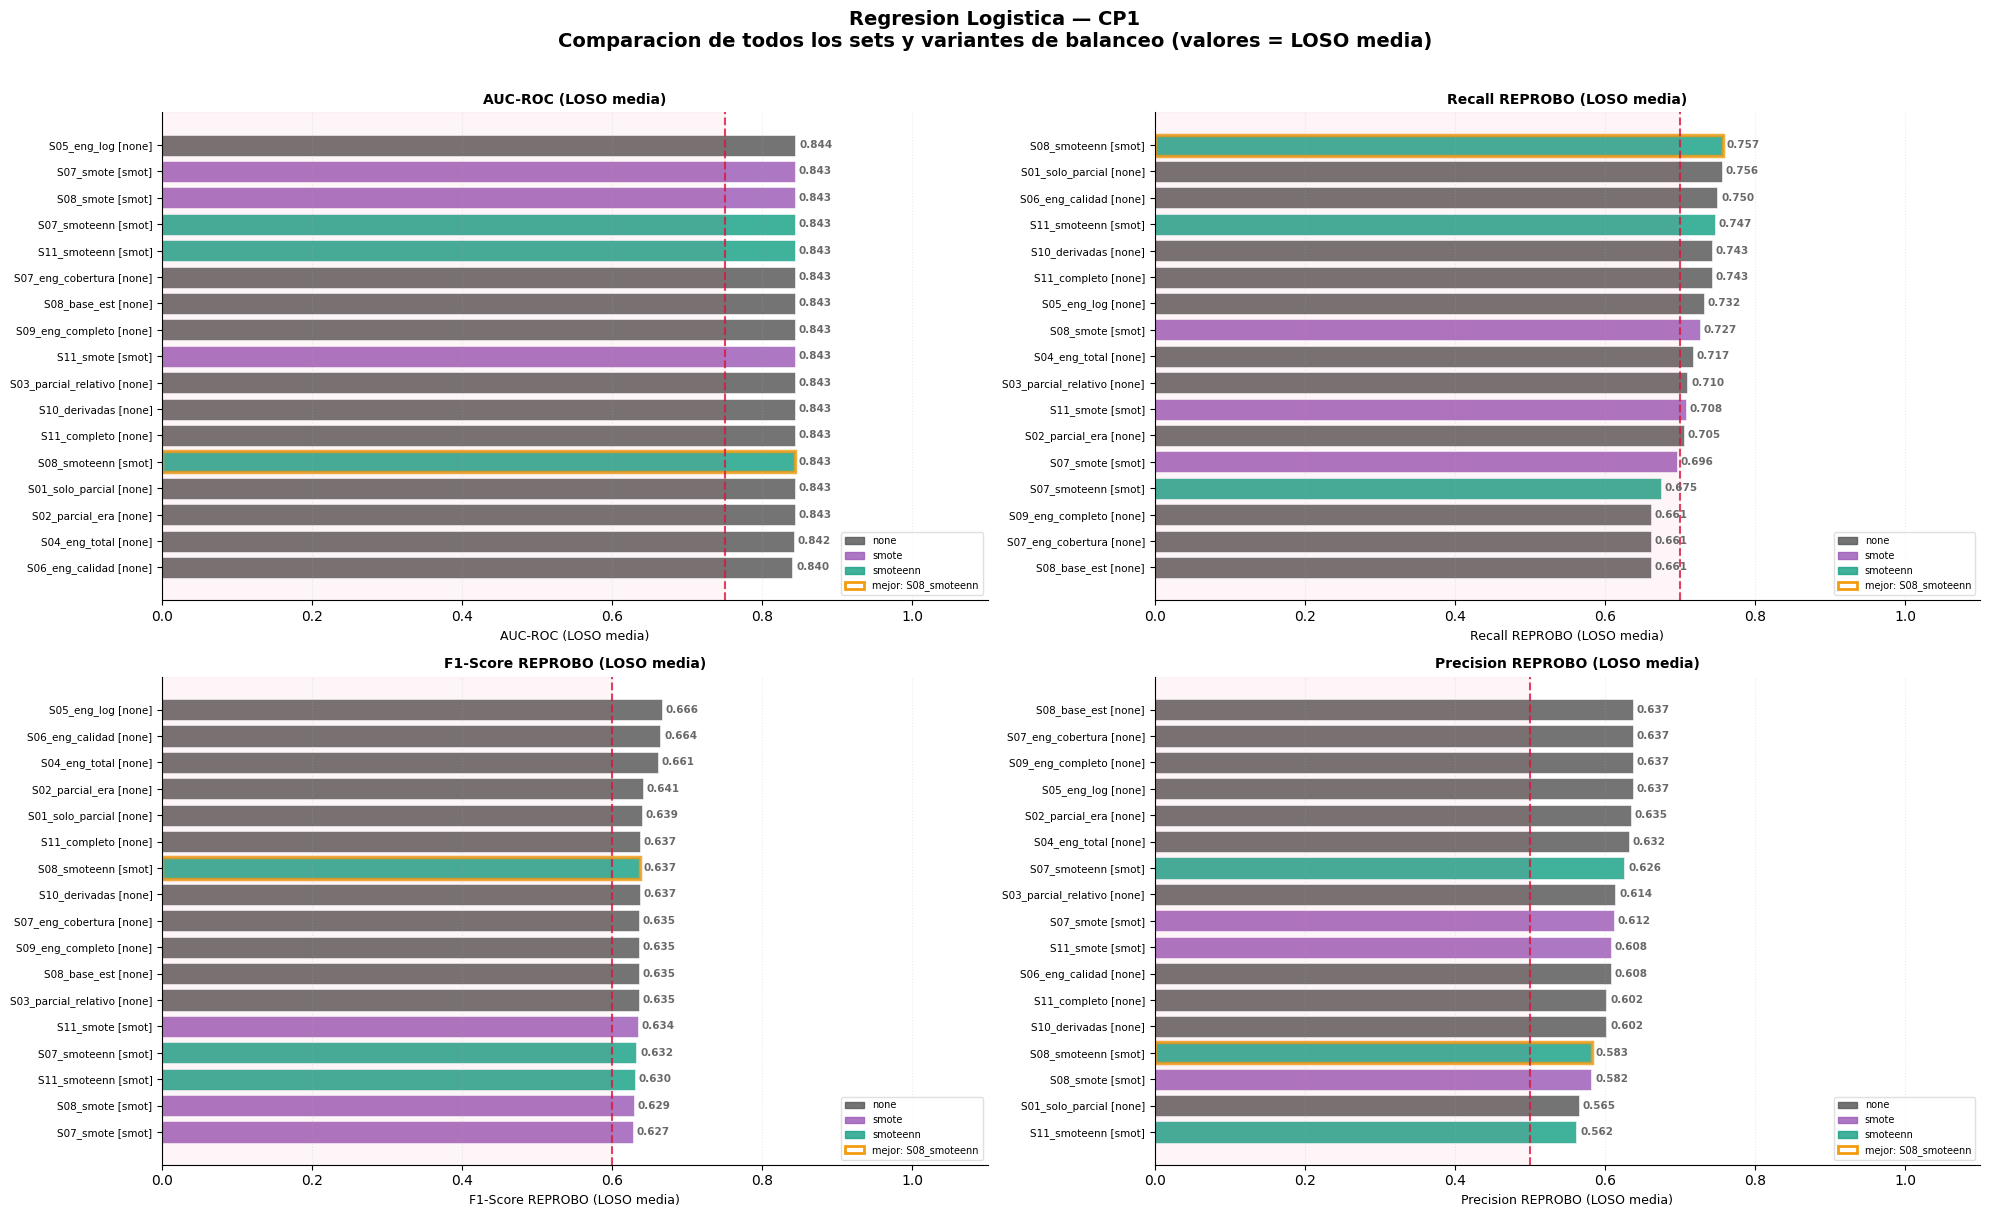

[PLOT] fig_lr_cp1.png guardado


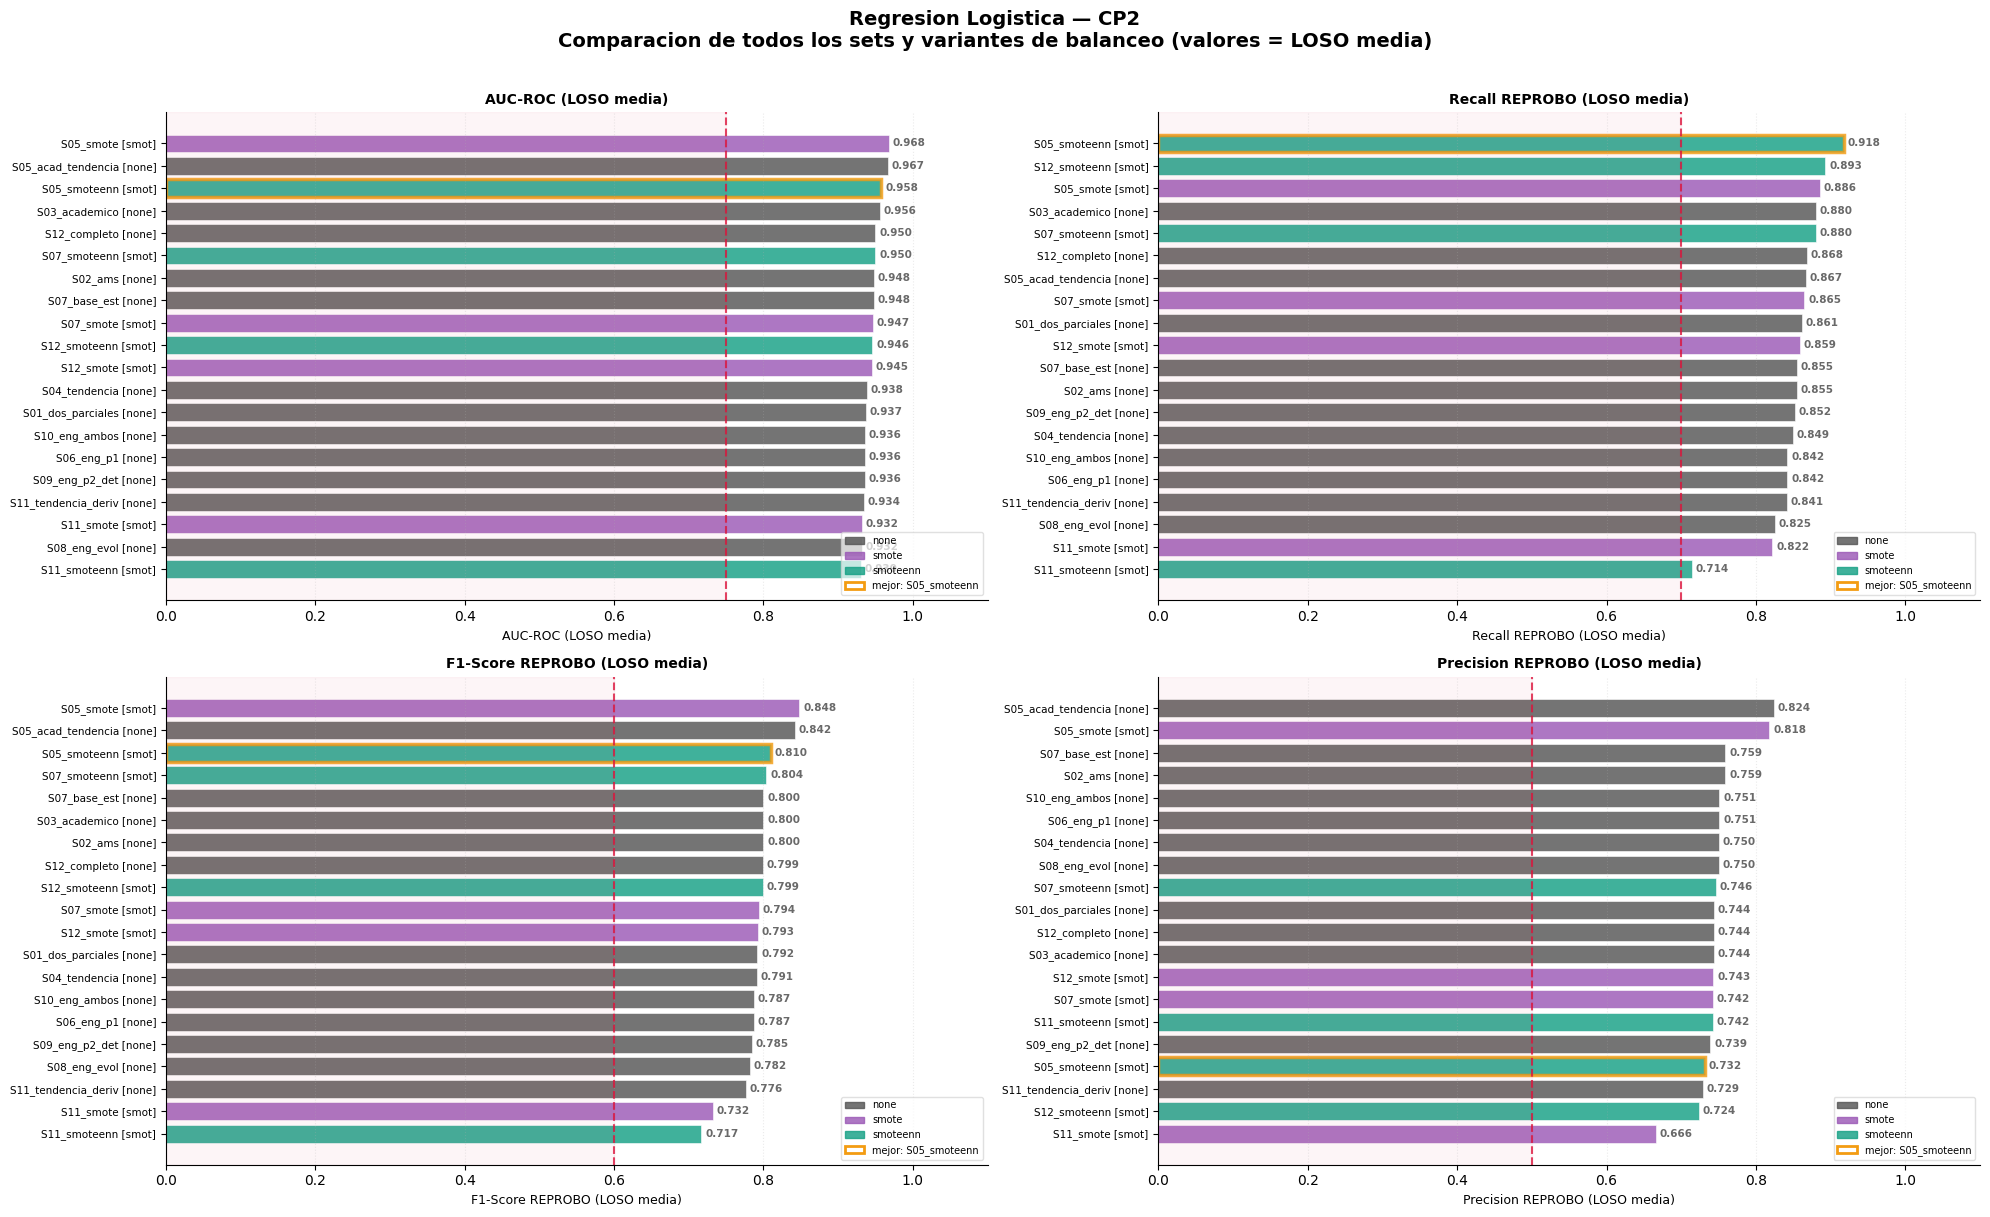

[PLOT] fig_lr_cp2.png guardado

[DIAGNOSTICO] Regresion Logistica | CP1 | S08_smoteenn
  AUC    LOSO=0.843 +/- 0.060
  Recall LOSO=0.757 +/- 0.160
  F1     LOSO=0.637 +/- 0.024


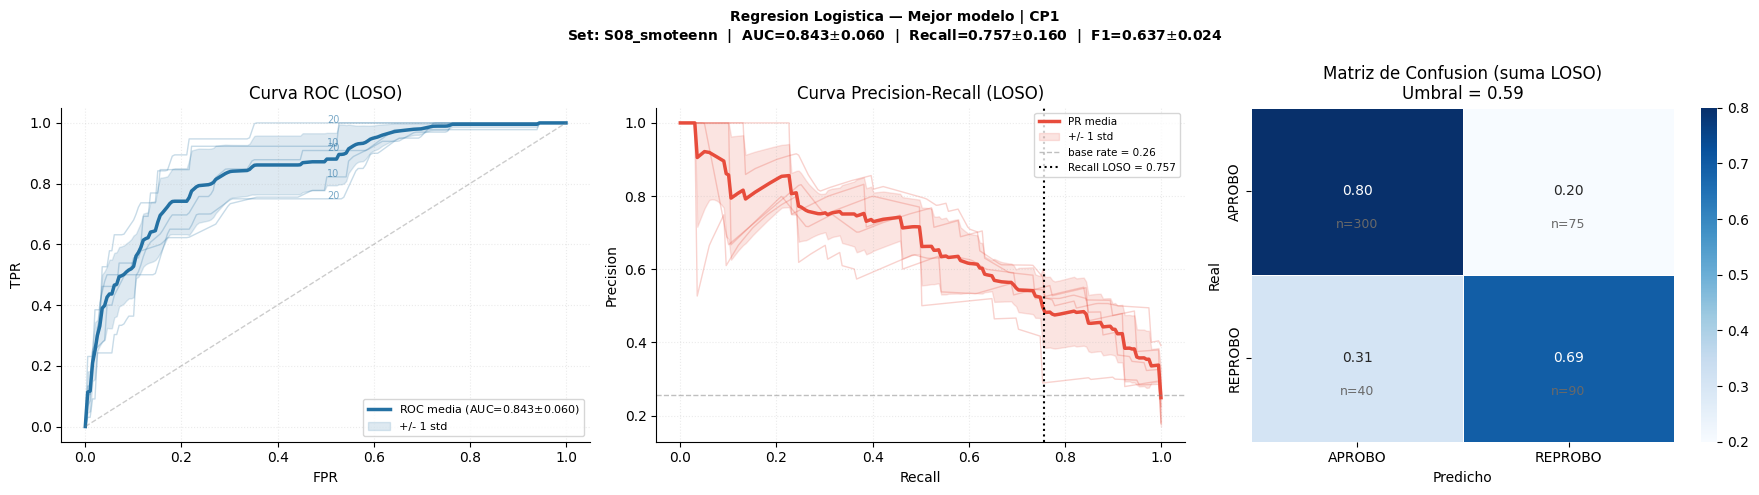

[PLOT] fig_lr_cp1_best.png guardado

[DIAGNOSTICO] Regresion Logistica | CP2 | S05_smoteenn
  AUC    LOSO=0.958 +/- 0.017
  Recall LOSO=0.918 +/- 0.020
  F1     LOSO=0.810 +/- 0.084


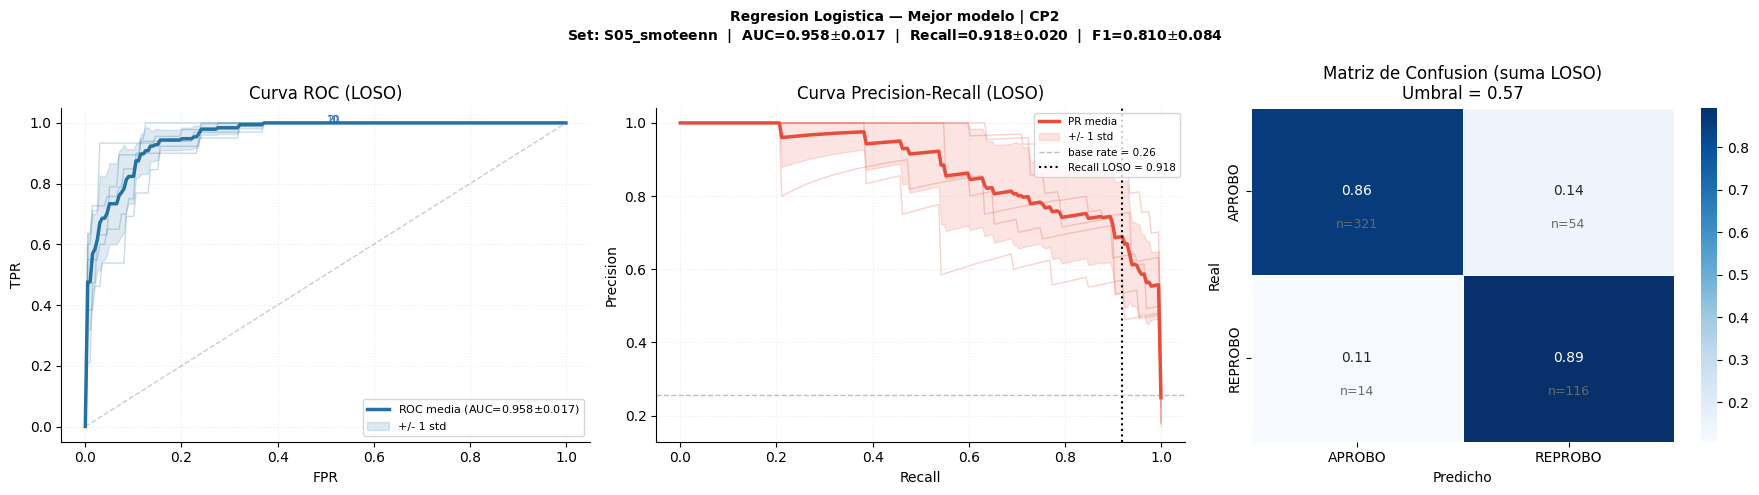

[PLOT] fig_lr_cp2_best.png guardado


In [9]:
# ── Tabla resumen ─────────────────────────────────────────────────────────────
df_lr_cp1 = build_table(results_lr_cp1, 'LR')
df_lr_cp2 = build_table(results_lr_cp2, 'LR')
SP.out("\n[LR CP1] Top 10:")
SP.out(df_lr_cp1.head(10)[['set','n_feat','balanceo','AUC','Recall','Prec','F1','Umbral']].to_string(index=False))
SP.out("\n[LR CP2] Top 10:")
SP.out(df_lr_cp2.head(10)[['set','n_feat','balanceo','AUC','Recall','Prec','F1','Umbral']].to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# FUNCION AUXILIAR CENTRAL — regla de seleccion unica para todo el notebook
# AUC_loso >= 0.75  ->  max Recall_loso  ->  F1_loso como desempate
# ═══════════════════════════════════════════════════════════════════════════════
def get_best_sn(results_dict):
    """
    Devuelve el nombre del mejor set segun:
      1. Filtrar candidatos con AUC_m (LOSO media) >= 0.75
      2. De los que pasan: mayor Recall_m (LOSO media)
      3. Empate en Recall (dif < 0.005): desempatar por mayor F1_m (LOSO media)
      4. Si ninguno supera AUC>=0.75: relajar filtro e informar
    """
    candidatos = {k: v for k, v in results_dict.items()
                  if v['res']['auc_m'] >= 0.75}
    if not candidatos:
        SP.out("  [!] Ningun set supera AUC>=0.75 — seleccion relajada por Recall+F1")
        candidatos = results_dict
    return max(candidatos,
               key=lambda k: (round(candidatos[k]['res']['rec_m'], 3),
                              round(candidatos[k]['res']['f1_m'],  3)))

# ── Comparativa de todos los sets ─────────────────────────────────────────────
def plot_model_comparison(df_res, results_dict, cp_label, model_label, filename):
    """
    4 subplots de barras horizontales comparando todos los sets.
    Las barras muestran medias LOSO — coherentes con get_best_sn y master_table.
    El mejor set (AUC_loso>=0.75 -> max Recall_loso -> F1_loso) se resalta
    con borde dorado.
    """
    metrics = [('AUC',   'AUC-ROC (LOSO media)',       0.75),
               ('Recall','Recall REPROBO (LOSO media)', 0.70),
               ('F1',    'F1-Score REPROBO (LOSO media)',0.60),
               ('Prec',  'Precision REPROBO (LOSO media)',0.50)]
    n_rows = len(df_res)
    fig, axes = plt.subplots(2, 2, figsize=(20, max(12, n_rows * 0.38 + 3)))
    fig.suptitle(f'{model_label} — {cp_label}\n'
                 f'Comparacion de todos los sets y variantes de balanceo '
                 f'(valores = LOSO media)',
                 fontsize=14, fontweight='bold', y=1.01)

    best_sn = get_best_sn(results_dict)

    bal_order = {'none': '#555555', 'smote': '#9B59B6', 'smoteenn': '#16A085'}
    for ax, (col, lbl, ref) in zip(axes.flat, metrics):
        df_s = df_res.sort_values(col, ascending=True).reset_index(drop=True)
        short = [f"{r['set']} [{r['balanceo'][:4]}]" for _, r in df_s.iterrows()]
        bar_cols = [bal_order.get(b, '#333333') for b in df_s['balanceo']]

        bars = ax.barh(range(len(df_s)), df_s[col], color=bar_cols,
                       alpha=0.82, edgecolor='white', linewidth=0.5)

        for bar, (_, row) in zip(bars, df_s.iterrows()):
            if row['set'] == best_sn:
                bar.set_edgecolor('#F39C12')
                bar.set_linewidth(2.5)

        ax.axvline(ref, color='crimson', ls='--', lw=1.5, alpha=0.8,
                   label=f'min requerido = {ref}')
        ax.axvspan(0, ref, alpha=0.04, color='crimson')

        for bar, val in zip(bars, df_s[col]):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', ha='left', fontsize=7.5,
                    color='dimgray', fontweight='bold')

        ax.set_yticks(range(len(df_s)))
        ax.set_yticklabels(short, fontsize=7.5)
        ax.set_xlabel(lbl, fontsize=9)
        ax.set_title(lbl, fontsize=10, fontweight='bold', pad=6)
        ax.set_xlim(0, 1.10)
        ax.grid(axis='x', alpha=0.25, linestyle=':')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        patches = [mpatches.Patch(color=c, label=b, alpha=0.82)
                   for b, c in bal_order.items()]
        patches.append(mpatches.Patch(facecolor='white', edgecolor='#F39C12',
                                      linewidth=2, label=f'mejor: {best_sn}'))
        ax.legend(handles=patches, fontsize=7, loc='lower right',
                  framealpha=0.7, edgecolor='lightgray')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    SP.out(f"[PLOT] {filename} guardado")

# ── Diagnostico del mejor modelo (ROC + PR + Confusion) ──────────────────────
def plot_best_diagnostics(results_dict, model_label, cp_label, filename):
    best_sn = get_best_sn(results_dict)
    r = results_dict[best_sn]

    auc_loso = r['res']['auc_m'];  auc_s = r['res']['auc_s']
    rec_loso = r['res']['rec_m'];  rec_s = r['res']['rec_s']
    f1_loso  = r['res']['f1_m'];   f1_s  = r['res']['f1_s']
    t        = r['res']['t_m']

    # Reconstruir predicciones por fold desde folds del LOSO
    # Necesitamos re-correr los folds para obtener yt/yp por semestre
    # Los tenemos en r['res']['folds'] para metricas, pero yt/yp estan pooled
    # Usamos los indices de loso para separar el pooled de vuelta por fold
    yt_all = np.array(r['res']['yt'])
    yp_all = np.array(r['res']['yp'])

    # Separar pooled en folds usando los tamanhos conocidos
    fold_sizes = [len(loso[i]['te']) for i in range(len(loso))]
    fold_aucs  = r['res']['folds']['auc'].values
    yt_folds, yp_folds = [], []
    idx = 0
    for sz in fold_sizes:
        yt_folds.append(yt_all[idx:idx+sz])
        yp_folds.append(yp_all[idx:idx+sz])
        idx += sz

    SP.out(f"\n[DIAGNOSTICO] {model_label} | {cp_label} | {best_sn}")
    SP.out(f"  AUC    LOSO={auc_loso:.3f} +/- {auc_s:.3f}")
    SP.out(f"  Recall LOSO={rec_loso:.3f} +/- {rec_s:.3f}")
    SP.out(f"  F1     LOSO={f1_loso:.3f} +/- {f1_s:.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f'{model_label} — Mejor modelo | {cp_label}\n'
        f'Set: {best_sn}  |  '
        f'AUC={auc_loso:.3f}$\pm${auc_s:.3f}  |  '
        f'Recall={rec_loso:.3f}$\pm${rec_s:.3f}  |  '
        f'F1={f1_loso:.3f}$\pm${f1_s:.3f}',
        fontsize=10, fontweight='bold'
    )

    sems = [s['sem'] for s in loso]
    mean_fpr = np.linspace(0, 1, 200)

    # ── ROC: curvas por fold + banda de variacion ─────────────────────────────
    tprs = []
    for yt_f, yp_f, sem, auc_f in zip(yt_folds, yp_folds, sems, fold_aucs):
        try:
            fpr_f, tpr_f, _ = roc_curve(yt_f, yp_f)
            tpr_interp = np.interp(mean_fpr, fpr_f, tpr_f)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
            axes[0].plot(mean_fpr, tpr_interp, lw=1, alpha=0.25,
                         color='#2471A3', label='_nolegend_')
            # Anotar semestre en el punto medio de la curva
            mid = len(mean_fpr) // 2
            axes[0].annotate(str(sem)[-2:], (mean_fpr[mid], tpr_interp[mid]),
                             fontsize=7, color='#2471A3', alpha=0.6)
        except Exception:
            pass

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = np.std(tprs, axis=0)
    axes[0].plot(mean_fpr, mean_tpr, lw=2.5, color='#2471A3',
                 label=f'ROC media (AUC={auc_loso:.3f}$\pm${auc_s:.3f})')
    axes[0].fill_between(mean_fpr,
                          np.maximum(mean_tpr - std_tpr, 0),
                          np.minimum(mean_tpr + std_tpr, 1),
                          alpha=0.15, color='#2471A3', label='+/- 1 std')
    axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.4, lw=1)
    axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC (LOSO)')
    axes[0].legend(fontsize=8, loc='lower right')
    axes[0].grid(alpha=0.25, linestyle=':')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # ── PR: curvas por fold + banda de variacion ──────────────────────────────
    mean_rec = np.linspace(0, 1, 200)
    precs = []
    for yt_f, yp_f in zip(yt_folds, yp_folds):
        try:
            pre_f, rec_f, _ = precision_recall_curve(yt_f, yp_f)
            # precision_recall_curve va de rec=1 a rec=0, invertir para interp
            pre_interp = np.interp(mean_rec, rec_f[::-1], pre_f[::-1])
            precs.append(pre_interp)
            axes[1].plot(mean_rec, pre_interp, lw=1, alpha=0.25,
                         color='#E74C3C', label='_nolegend_')
        except Exception:
            pass

    mean_pre = np.mean(precs, axis=0)
    std_pre  = np.std(precs, axis=0)
    base_rate = yt_all.mean()
    axes[1].plot(mean_rec, mean_pre, lw=2.5, color='#E74C3C',
                 label=f'PR media')
    axes[1].fill_between(mean_rec,
                          np.maximum(mean_pre - std_pre, 0),
                          np.minimum(mean_pre + std_pre, 1),
                          alpha=0.15, color='#E74C3C', label='+/- 1 std')
    axes[1].axhline(base_rate, color='gray', ls='--', lw=1, alpha=0.5,
                    label=f'base rate = {base_rate:.2f}')
    # Marcar el punto Recall/Precision LOSO al umbral promedio
    axes[1].axvline(rec_loso, color='black', ls=':', lw=1.5,
                    label=f'Recall LOSO = {rec_loso:.3f}')
    axes[1].set(xlabel='Recall', ylabel='Precision',
                title='Curva Precision-Recall (LOSO)')
    axes[1].legend(fontsize=7.5, loc='upper right')
    axes[1].grid(alpha=0.25, linestyle=':')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    # ── Confusion: suma de todas las matrices de confusion de los folds ───────
    # Mas honesto que pooled: cada fold contribuye con su matriz real
    cm_total = np.zeros((2, 2), dtype=int)
    for yt_f, yp_f in zip(yt_folds, yp_folds):
        yh_f = (yp_f >= t).astype(int)
        cm_total += confusion_matrix(yt_f, yh_f, labels=[0, 1])

    cmn = cm_total / cm_total.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues', ax=axes[2],
                xticklabels=['APROBO', 'REPROBO'],
                yticklabels=['APROBO', 'REPROBO'],
                linewidths=0.5, linecolor='white')
    for ii in range(2):
        for jj in range(2):
            axes[2].text(jj + 0.5, ii + 0.72, f'n={cm_total[ii,jj]}',
                         ha='center', fontsize=9, color='dimgray')
    axes[2].set(title=f'Matriz de Confusion (suma LOSO)\nUmbral = {t:.2f}',
                ylabel='Real', xlabel='Predicho')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    SP.out(f"[PLOT] {filename} guardado")
    
plot_model_comparison(df_lr_cp1, results_lr_cp1, "CP1", "Regresion Logistica", "fig_lr_cp1.png")
plot_model_comparison(df_lr_cp2, results_lr_cp2, "CP2", "Regresion Logistica", "fig_lr_cp2.png")
plot_best_diagnostics(results_lr_cp1, "Regresion Logistica", "CP1", "fig_lr_cp1_best.png")
plot_best_diagnostics(results_lr_cp2, "Regresion Logistica", "CP2", "fig_lr_cp2_best.png")

# §6 — Árbol de Decisión

## 6.1 Descripción del modelo y parámetros
El **Árbol de Decisión** ofrece una interpretabilidad máxima: permite al docente visualizar y leer directamente las reglas de clasificación (ej. *"Si parcial_1 < 2.5 y engagement < 5h → Riesgo"*). En datasets pequeños ($N \approx 400$ por fold), la **poda** es el mecanismo crítico para evitar el sobreajuste (*overfitting*).

Se evalúan cuatro dimensiones de control de complejidad:

| Parámetro | Descripción | Efecto en la complejidad |
| :--- | :--- | :--- |
| **max_depth** | Profundidad máxima del árbol | Más profundo $\rightarrow$ mayor varianza (riesgo de memorizar) |
| **min_samples_split** | Mínimo de muestras para dividir un nodo | Mayor valor $\rightarrow$ más poda (árbol más corto) |
| **min_samples_leaf** | Mínimo de muestras permitidas en una hoja | Mayor valor $\rightarrow$ nodos finales más genéricos |
| **ccp_alpha** | Poda por complejidad de costo (*post-pruning*) | Mayor valor $\rightarrow$ elimina ramas con poco aporte al error |
| **class_weight** | Peso de las clases | `balanced` penaliza más los Falsos Negativos en REPROBÓ |

---

## 6.2 Grilla de búsqueda (Grid Search)
Se realiza una exploración exhaustiva para encontrar la estructura de árbol que mejor generalice entre semestres:

* **Estructura:**
    * `max_depth`: [2, 3, 4, 5, 6, 8, None]
    * `min_samples_split`: [5, 10, 15, 20, 30]
    * `min_samples_leaf`: [3, 5, 8, 10, 15]
* **Algoritmo:**
    * `criterion`: ['gini', 'entropy']
    * `ccp_alpha`: [0.0, 0.003, 0.005, 0.01, 0.02, 0.04]
* **Balanceo:**
    * `class_weight`: [None, 'balanced']



In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# §6 — ÁRBOL DE DECISIÓN
# ═══════════════════════════════════════════════════════════════════════════════
DT_GRID = {
    'max_depth':         [2, 3, 4, 5, 6, 8, None],
    'min_samples_split': [5, 10, 15, 20, 30],
    'min_samples_leaf':  [3, 5, 8, 10, 15],
    'criterion':         ['gini', 'entropy'],
    'class_weight':      [None, 'balanced'],
    'ccp_alpha':         [0.0, 0.003, 0.005, 0.01, 0.02, 0.04],
}

def search_generic(model_cls, grid, cfg, df, loso, n_iter=80, extra_fixed=None):
    """Búsqueda aleatoria de hiperparámetros con fold-0 como proxy."""
    extra_fixed = extra_fixed or {}
    s = loso[0]
    feats, bal, izeros = cfg['features'], cfg['balanceo'], cfg.get('impute_zeros', [])
    Xtr = df.loc[s['tr'], feats].copy(); ytr = df.loc[s['tr'], 'target'].copy()
    Xte = df.loc[s['te'], feats].copy(); yte = df.loc[s['te'], 'target'].copy()
    for f in izeros:
        if f in Xtr.columns: Xtr[f].fillna(0, inplace=True); Xte[f].fillna(0, inplace=True)
    sc = StandardScaler()
    Xts = sc.fit_transform(Xtr.fillna(0)); Xes = sc.transform(Xte.fillna(0))
    Xts, ytr = apply_balanceo(Xts, ytr, bal)

    best_auc, best_p = -1, {}
    for p in ParameterSampler(grid, n_iter=n_iter, random_state=RANDOM_STATE):
        try:
            params = {**p, **extra_fixed, 'random_state': RANDOM_STATE}
            m = model_cls(**params); m.fit(Xts, ytr)
            auc = roc_auc_score(yte, m.predict_proba(Xes)[:,1])
            if auc > best_auc: best_auc, best_p = auc, params
        except: pass
    return best_p if best_p else {'random_state': RANDOM_STATE, **extra_fixed}

def run_model_all(model_cls, grid, extra_fixed, feature_sets, df, loso, model_label):
    SP.out(f"\n{'#'*72}")
    SP.out(f"#  {model_label}")
    SP.out(f"{'#'*72}")
    results = {}
    for set_name, cfg in feature_sets.items():
        SP.out(f"\n  [{set_name}] buscando params...")
        params = search_generic(model_cls, grid, cfg, df, loso,
                                extra_fixed=extra_fixed)
        def make_m(p=params, cls=model_cls): return cls(**p)
        res = run_loso(make_m, cfg, df, loso)
        m_full = fit_for_internals(make_m, cfg, df)
        pairs, label = extract_internals(m_full, cfg['features'])
        print_experiment(model_label, set_name, cfg, params, label, pairs, res)
        results[set_name] = {'cfg': cfg, 'params': params, 'res': res,
                              'internals': pairs, 'model_full': m_full}
    return results

results_dt_cp1 = run_model_all(DecisionTreeClassifier, DT_GRID, {},
                                FEATURE_SETS_CP1, df, loso, "Arbol de Decision — CP1")
results_dt_cp2 = run_model_all(DecisionTreeClassifier, DT_GRID, {},
                                FEATURE_SETS_CP2, df, loso, "Arbol de Decision — CP2")


########################################################################
#  Arbol de Decision — CP1
########################################################################

  [S01_solo_parcial] buscando params...

════════════════════════════════════════════════════════════════════════
  MODELO   : Arbol de Decision — CP1
  SET      : S01_solo_parcial
  FEATURES : ['parcial_1']
  N feat   : 1  |  Balanceo: none
────────────────────────────────────────────────────────────────────────
  HIPERPARAMETROS:
    min_samples_split                = 30
    min_samples_leaf                 = 15
    max_depth                        = 4
    criterion                        = entropy
    class_weight                     = balanced
    ccp_alpha                        = 0.0
    random_state                     = 42

  PARAMETROS INTERNOS (Importancia Gini (MDI)):
  Feature                                     Valor
  ──────────────────────────────────────────────────
  parcial_1                     

## 6.2 Tabla resumen, gráficas y visualización del árbol


[DT CP1] Top 10:
             set  n_feat balanceo   AUC  Recall  Prec    F1  Umbral
S01_solo_parcial       1     none 0.827   0.751 0.539 0.624    0.50
       S07_smote       5    smote 0.807   0.741 0.560 0.624    0.37
    S07_smoteenn       5 smoteenn 0.808   0.749 0.561 0.623    0.37
    S11_smoteenn       7 smoteenn 0.808   0.727 0.574 0.613    0.72
     S05_eng_log       3     none 0.785   0.683 0.565 0.611    0.30
   S04_eng_total       3     none 0.785   0.683 0.565 0.611    0.30
S09_eng_completo       7     none 0.783   0.682 0.569 0.608    0.18
    S08_smoteenn       6 smoteenn 0.795   0.783 0.523 0.606    0.56
 S02_parcial_era       2     none 0.810   0.783 0.503 0.605    0.35
    S11_completo       7     none 0.786   0.648 0.612 0.604    0.55

[DT CP2] Top 10:
               set  n_feat balanceo   AUC  Recall  Prec    F1  Umbral
         S07_smote      10    smote 0.906   0.853 0.688 0.749    0.42
 S01_dos_parciales       3     none 0.913   0.762 0.744 0.747    0.44
      

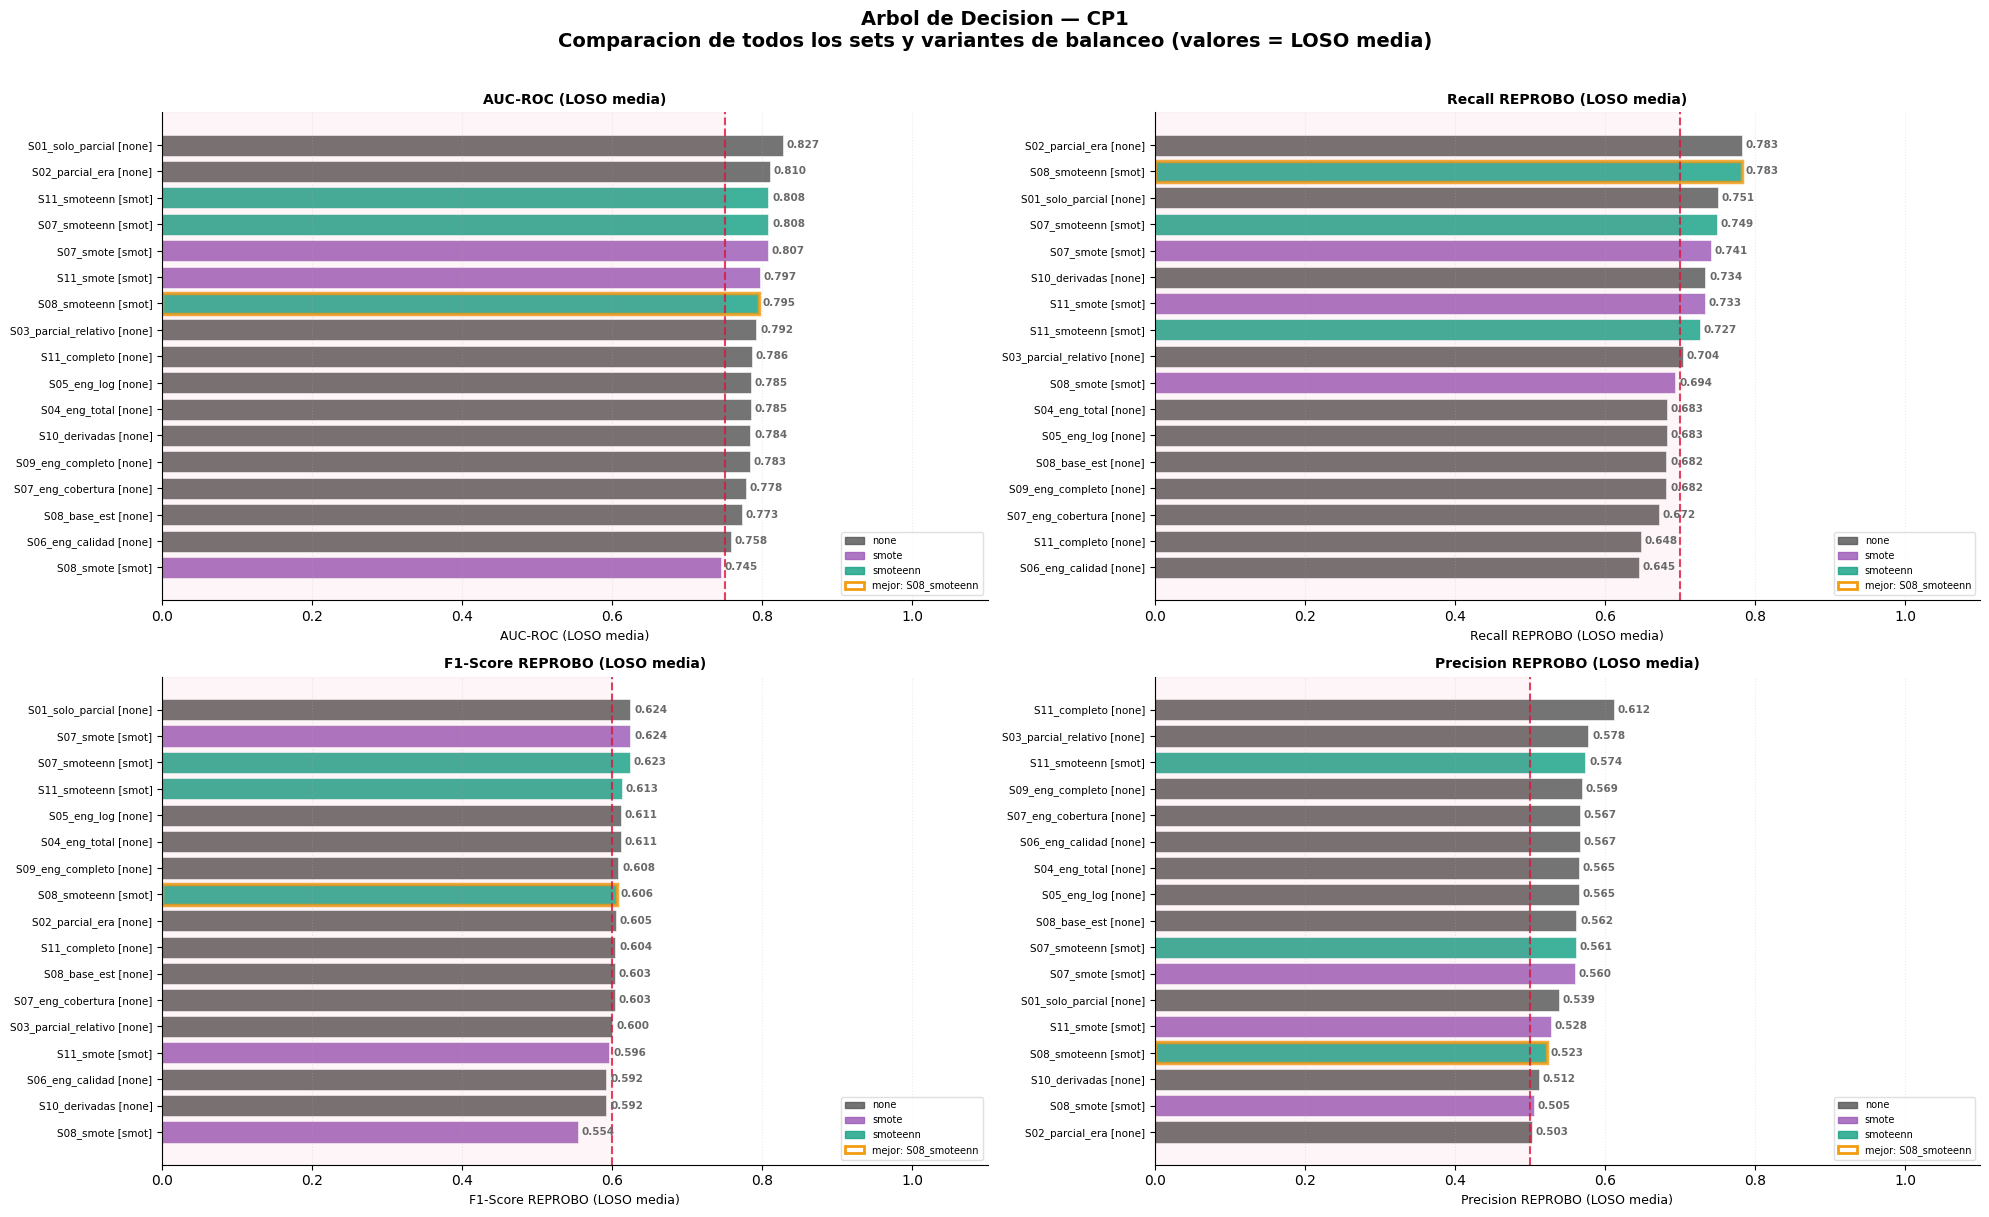

[PLOT] fig_dt_cp1.png guardado


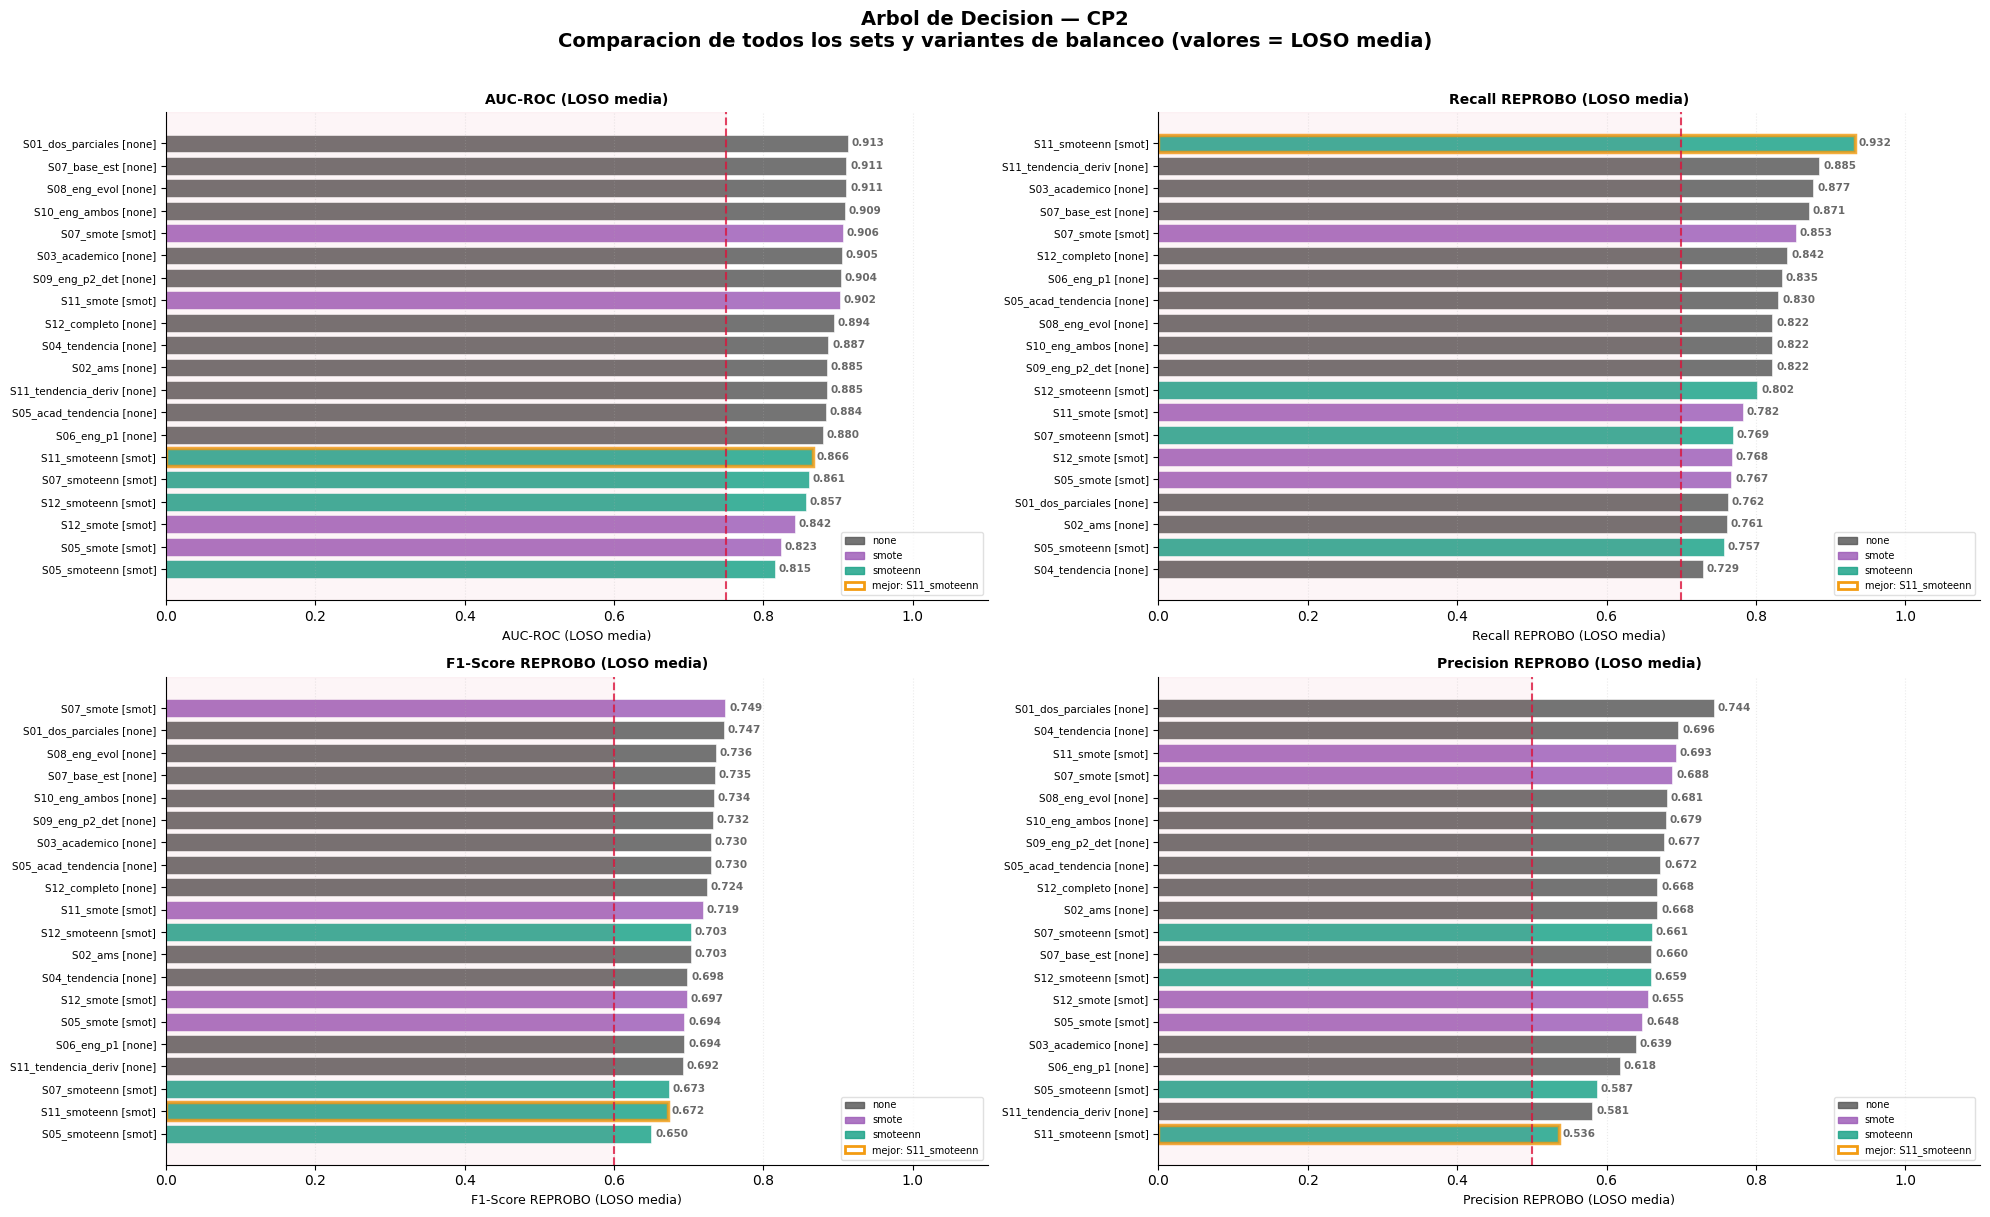

[PLOT] fig_dt_cp2.png guardado

[DIAGNOSTICO] Arbol de Decision | CP1 | S08_smoteenn
  AUC    LOSO=0.795 +/- 0.081
  Recall LOSO=0.783 +/- 0.126
  F1     LOSO=0.606 +/- 0.071


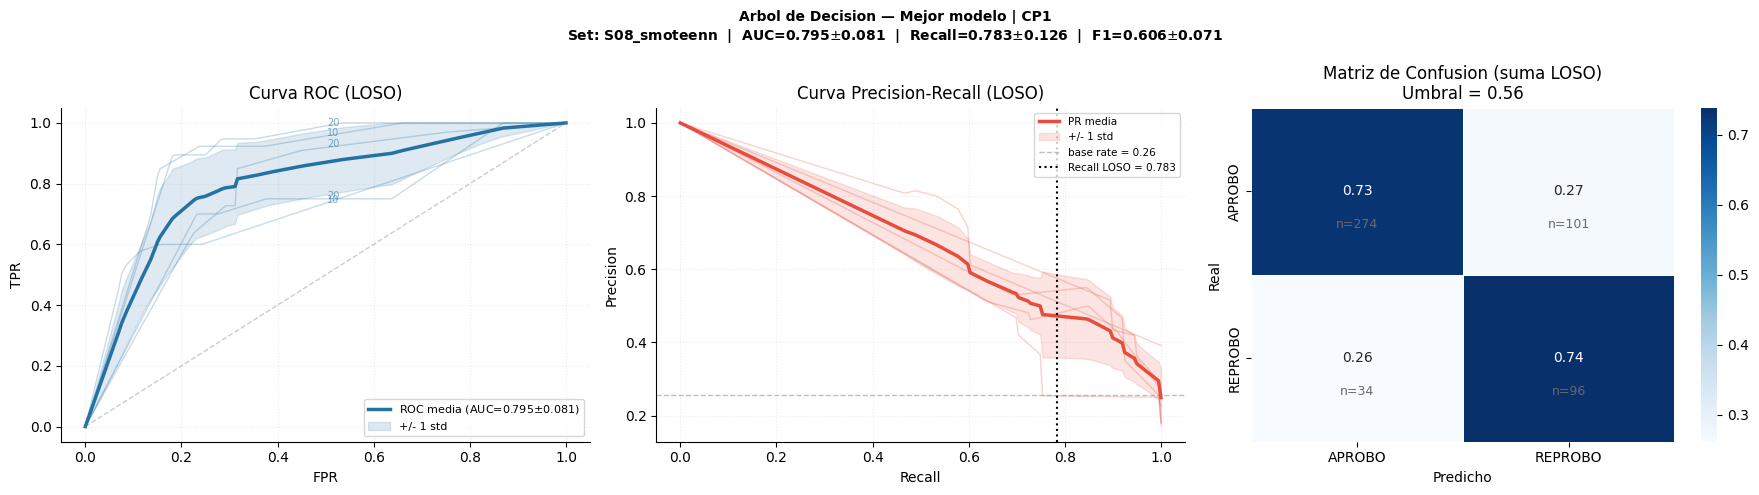

[PLOT] fig_dt_cp1_best.png guardado

[DIAGNOSTICO] Arbol de Decision | CP2 | S11_smoteenn
  AUC    LOSO=0.866 +/- 0.030
  Recall LOSO=0.932 +/- 0.083
  F1     LOSO=0.672 +/- 0.083


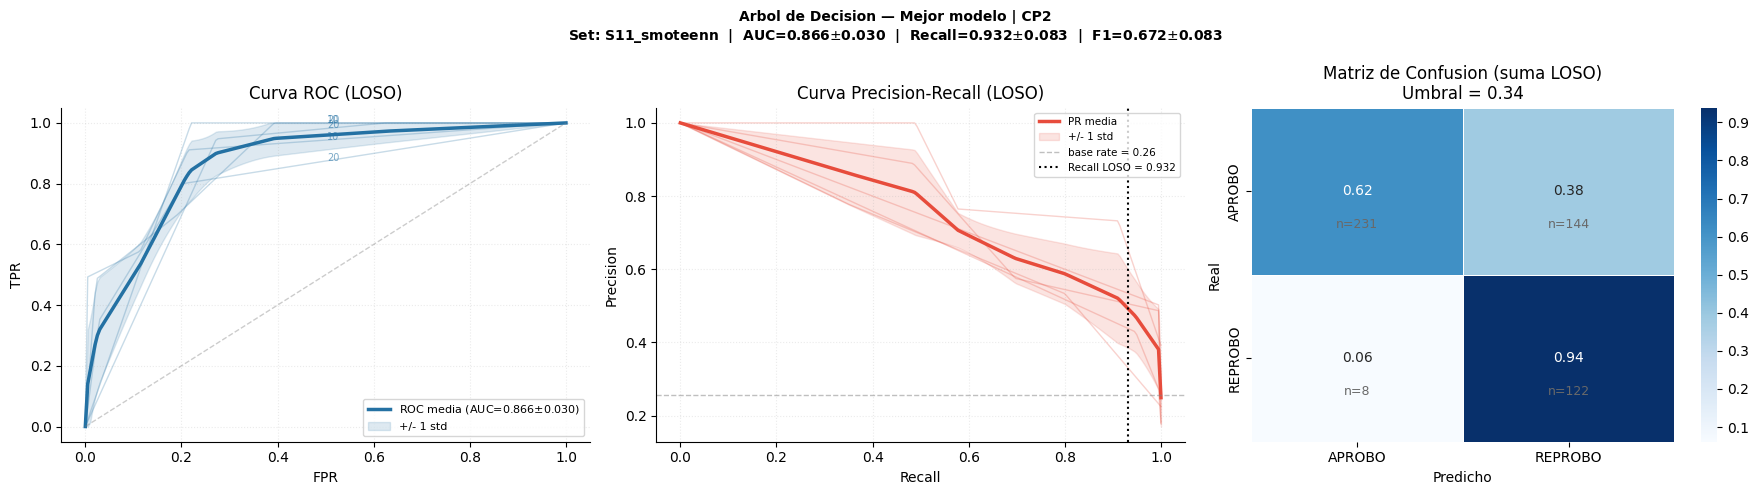

[PLOT] fig_dt_cp2_best.png guardado


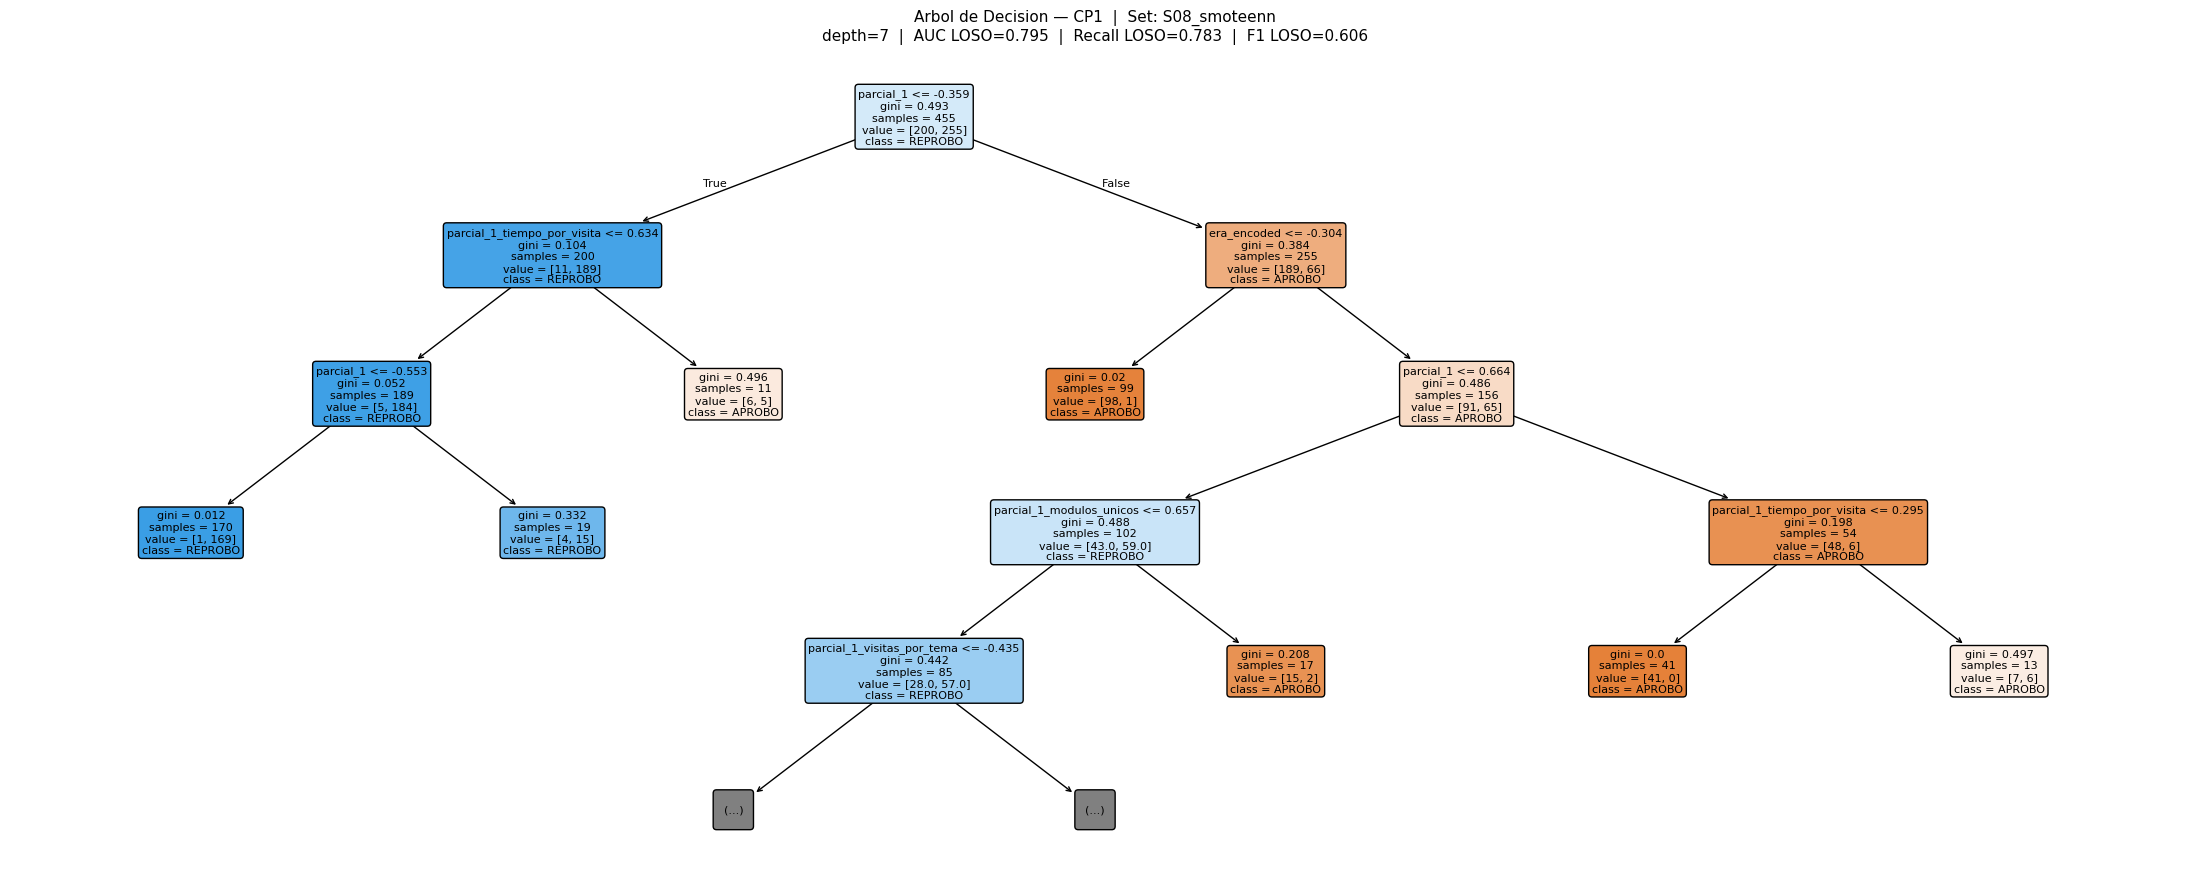


[DT CP1] Reglas texto (primeros 4 niveles):
|--- parcial_1 <= -0.36
|   |--- parcial_1_tiempo_por_visita <= 0.63
|   |   |--- parcial_1 <= -0.55
|   |   |   |--- class: 1
|   |   |--- parcial_1 >  -0.55
|   |   |   |--- class: 1
|   |--- parcial_1_tiempo_por_visita >  0.63
|   |   |--- class: 0
|--- parcial_1 >  -0.36
|   |--- era_encoded <= -0.30
|   |   |--- class: 0
|   |--- era_encoded >  -0.30
|   |   |--- parcial_1 <= 0.66
|   |   |   |--- parcial_1_modulos_unicos <= 0.66
|   |   |   |   |--- parcial_1_visitas_por_tema <= -0.43
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- parcial_1_visitas_por_tema >  -0.43
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- parcial_1_modulos_unicos >  0.66
|   |   |   |   |--- class: 0
|   |   |--- parcial_1 >  0.66
|   |   |   |--- parcial_1_tiempo_por_visita <= 0.30
|   |   |   |   |--- class: 0
|   |   |   |--- parcial_1_tiempo_por_visita >  0.30
|   |   |   |   |--- class: 0

[PLOT] fig_dt_cp1_tree.png guardado


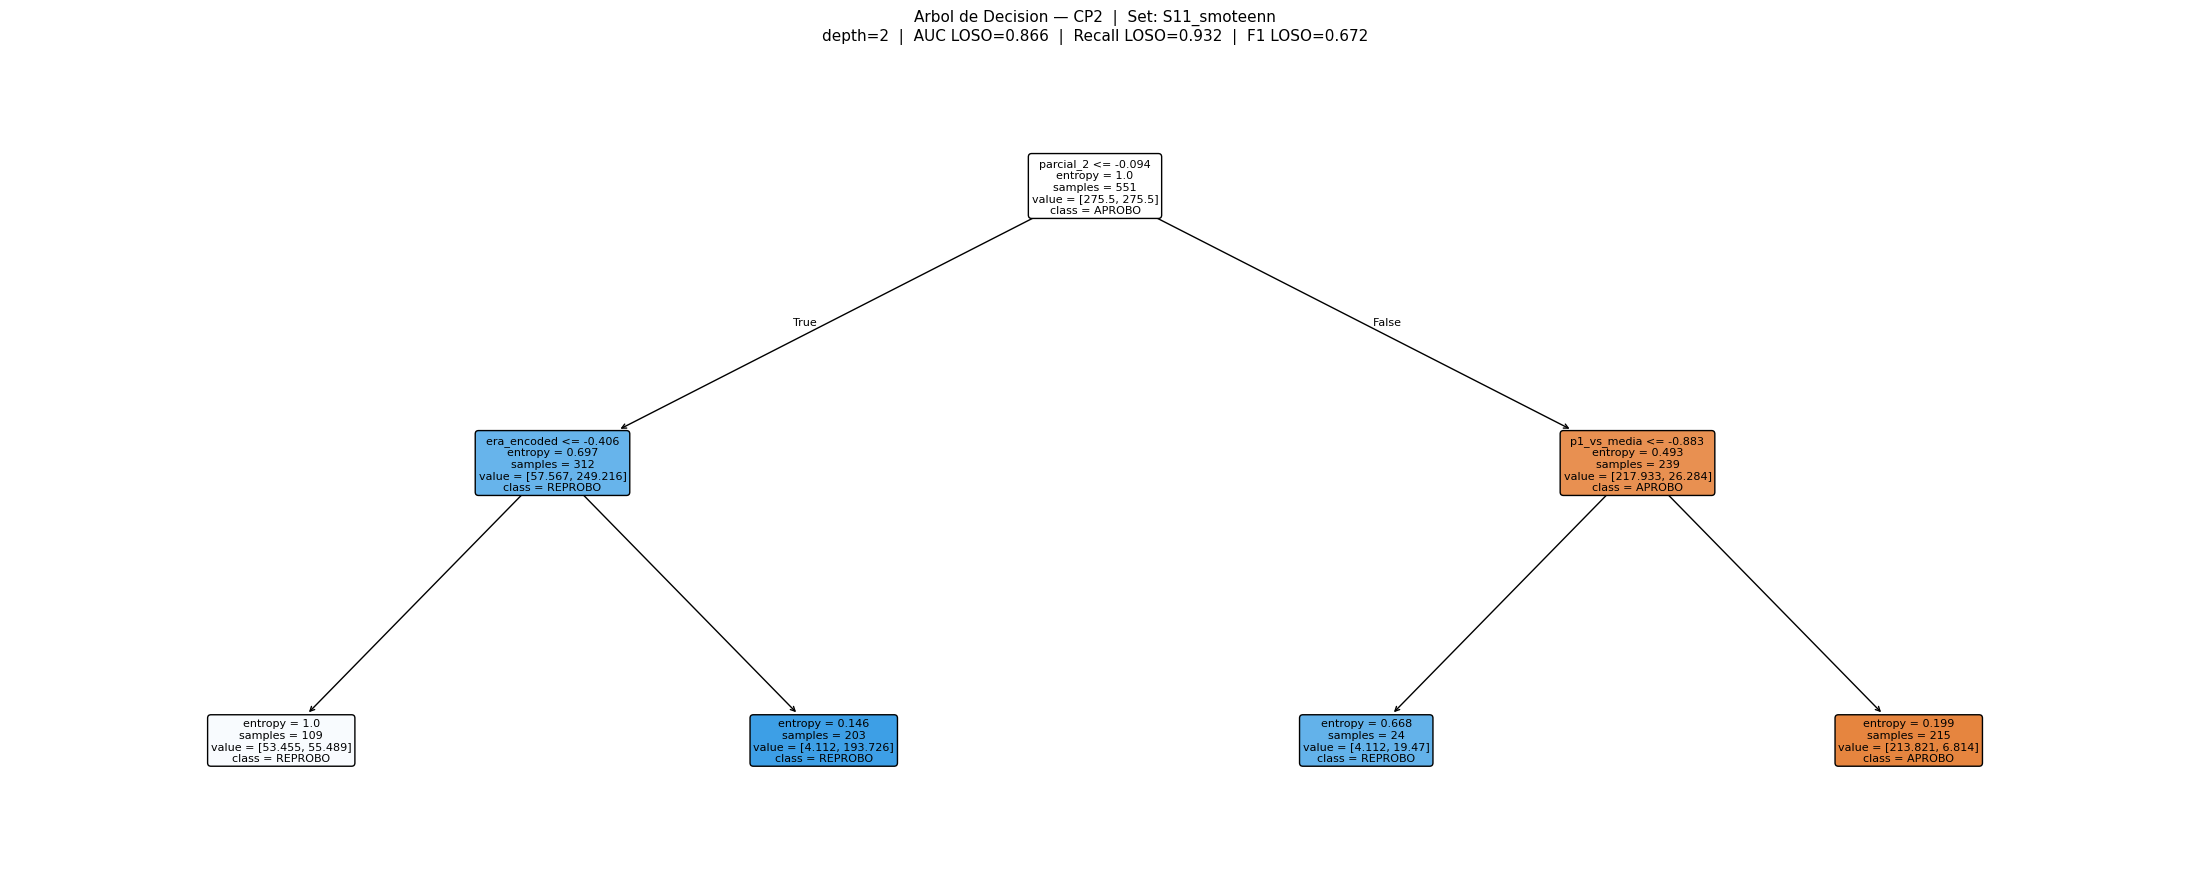


[DT CP2] Reglas texto (primeros 4 niveles):
|--- parcial_2 <= -0.09
|   |--- era_encoded <= -0.41
|   |   |--- class: 1
|   |--- era_encoded >  -0.41
|   |   |--- class: 1
|--- parcial_2 >  -0.09
|   |--- p1_vs_media <= -0.88
|   |   |--- class: 1
|   |--- p1_vs_media >  -0.88
|   |   |--- class: 0

[PLOT] fig_dt_cp2_tree.png guardado


In [11]:
# ── Tablas y graficas ─────────────────────────────────────────────────────────
df_dt_cp1 = build_table(results_dt_cp1, 'DT')
df_dt_cp2 = build_table(results_dt_cp2, 'DT')
SP.out("\n[DT CP1] Top 10:"); SP.out(df_dt_cp1.head(10)[['set','n_feat','balanceo','AUC','Recall','Prec','F1','Umbral']].to_string(index=False))
SP.out("\n[DT CP2] Top 10:"); SP.out(df_dt_cp2.head(10)[['set','n_feat','balanceo','AUC','Recall','Prec','F1','Umbral']].to_string(index=False))

plot_model_comparison(df_dt_cp1, results_dt_cp1, "CP1", "Arbol de Decision", "fig_dt_cp1.png")
plot_model_comparison(df_dt_cp2, results_dt_cp2, "CP2", "Arbol de Decision", "fig_dt_cp2.png")
plot_best_diagnostics(results_dt_cp1, "Arbol de Decision", "CP1", "fig_dt_cp1_best.png")
plot_best_diagnostics(results_dt_cp2, "Arbol de Decision", "CP2", "fig_dt_cp2_best.png")

# ── Visualizacion del arbol ganador ───────────────────────────────────────────
def plot_best_tree(results_dict, cp_label, filename_tree):
    """Re-entrena el mejor arbol (get_best_sn) en todo el dataset y lo visualiza."""
    best_sn = get_best_sn(results_dict)
    r       = results_dict[best_sn]
    feats   = r['cfg']['features']
    m       = r['model_full']
    d       = m.get_depth()

    fig, ax = plt.subplots(figsize=(22, 9))
    plot_tree(m, max_depth=min(d, 4), feature_names=feats,
              class_names=['APROBO', 'REPROBO'], filled=True, rounded=True,
              fontsize=8, ax=ax)
    ax.set_title(f'Arbol de Decision — {cp_label}  |  Set: {best_sn}\n'
                 f"depth={m.get_depth()}  |  "
                 f"AUC LOSO={r['res']['auc_m']:.3f}  |  "
                 f"Recall LOSO={r['res']['rec_m']:.3f}  |  "
                 f"F1 LOSO={r['res']['f1_m']:.3f}", fontsize=11)
    plt.tight_layout()
    plt.savefig(filename_tree, dpi=120, bbox_inches='tight')
    plt.show()

    SP.out(f"\n[DT {cp_label}] Reglas texto (primeros 4 niveles):")
    SP.out(export_text(m, feature_names=feats, max_depth=4))
    SP.out(f"[PLOT] {filename_tree} guardado")

plot_best_tree(results_dt_cp1, "CP1", "fig_dt_cp1_tree.png")
plot_best_tree(results_dt_cp2, "CP2", "fig_dt_cp2_tree.png")

# §7 — Random Forest

## 7.1 Descripción del modelo y estrategia
**Random Forest** reduce la varianza del árbol individual combinando múltiples árboles mediante *bootstrapping* y subespacios de features aleatorios (*Feature Bagging*). Dado que el tamaño de muestra es moderado ($N \approx 400$ por fold), el espacio de búsqueda se limita intencionalmente para evitar que el modelo se vuelva excesivamente complejo y pierda capacidad de generalización entre semestres.

### Medición de Importancia de Variables
Para entender qué factores pesan más en la predicción, se reportan dos métricas:

1.  **MDI (Mean Decrease in Impurity):** Es el método por defecto; calcula cuánto reduce cada feature la impureza de los nodos. Es rápido, pero puede favorecer variables numéricas con mucha variación.
2.  **Permutation Importance:** Es un método más robusto. Mide cuánto cae el **AUC** del modelo cuando se "desordena" (permuta) aleatoriamente una variable. Si el AUC cae mucho, la variable es vital; si no cambia o mejora, la variable es ruido.

Se explora el compromiso entre la robustez del ensamble y la profundidad de los árboles individuales:

| Parámetro | Valores | Propósito |
| :--- | :--- | :--- |
| **n_estimators** | [50, 100, 200, 300] | Número de árboles en el bosque. |
| **max_depth** | [3, 5, 7, 10, None] | Límite de crecimiento para controlar el sobreajuste. |
| **min_samples_split** | [5, 10, 20] | Mínimo de estudiantes para intentar una división. |
| **min_samples_leaf** | [3, 5, 8] | Mínimo de estudiantes que deben quedar en una hoja. |
| **max_features** | ['sqrt', 'log2', 0.5, 0.7] | Cantidad de variables que cada árbol puede "ver". |
| **class_weight** | [None, 'balanced', 'balanced_subsample'] | Estrategias para dar más peso a la clase REPROBÓ. |


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# §7 — RANDOM FOREST
# ═══════════════════════════════════════════════════════════════════════════════
RF_GRID = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf':  [3, 5, 8],
    'max_features':      ['sqrt', 'log2', 0.5, 0.7],
    'class_weight':      [None, 'balanced', 'balanced_subsample'],
}

results_rf_cp1 = run_model_all(RandomForestClassifier, RF_GRID,
                                {'n_jobs': -1},
                                FEATURE_SETS_CP1, df, loso, "Random Forest — CP1")
results_rf_cp2 = run_model_all(RandomForestClassifier, RF_GRID,
                                {'n_jobs': -1},
                                FEATURE_SETS_CP2, df, loso, "Random Forest — CP2")


########################################################################
#  Random Forest — CP1
########################################################################

  [S01_solo_parcial] buscando params...

════════════════════════════════════════════════════════════════════════
  MODELO   : Random Forest — CP1
  SET      : S01_solo_parcial
  FEATURES : ['parcial_1']
  N feat   : 1  |  Balanceo: none
────────────────────────────────────────────────────────────────────────
  HIPERPARAMETROS:
    n_estimators                     = 300
    min_samples_split                = 5
    min_samples_leaf                 = 8
    max_features                     = 0.5
    max_depth                        = 3
    class_weight                     = balanced
    n_jobs                           = -1
    random_state                     = 42

  PARAMETROS INTERNOS (Importancia MDI (promedio arboles)):
  Feature                                     Valor
  ───────────────────────────────────────────

## 7.2 Tabla resumen, gráficas e importancia de features


[RF CP1] Top 10:
             set  n_feat balanceo   AUC  Recall  Prec    F1  Umbral
     S05_eng_log       3     none 0.834   0.717 0.635 0.665    0.39
   S04_eng_total       3     none 0.834   0.717 0.635 0.665    0.39
       S11_smote       7    smote 0.833   0.774 0.591 0.661    0.52
 S02_parcial_era       2     none 0.830   0.764 0.571 0.652    0.32
   S10_derivadas       6     none 0.831   0.712 0.613 0.651    0.54
S09_eng_completo       7     none 0.825   0.744 0.585 0.651    0.33
    S11_smoteenn       7 smoteenn 0.807   0.753 0.595 0.651    0.77
    S08_smoteenn       6 smoteenn 0.797   0.742 0.597 0.650    0.67
    S08_base_est       6     none 0.816   0.767 0.572 0.648    0.30
 S06_eng_calidad       4     none 0.822   0.721 0.607 0.647    0.34

[RF CP2] Top 10:
               set  n_feat balanceo   AUC  Recall  Prec    F1  Umbral
     S03_academico       5     none 0.953   0.819 0.823 0.820    0.44
           S02_ams       4     none 0.952   0.865 0.760 0.797    0.39
      

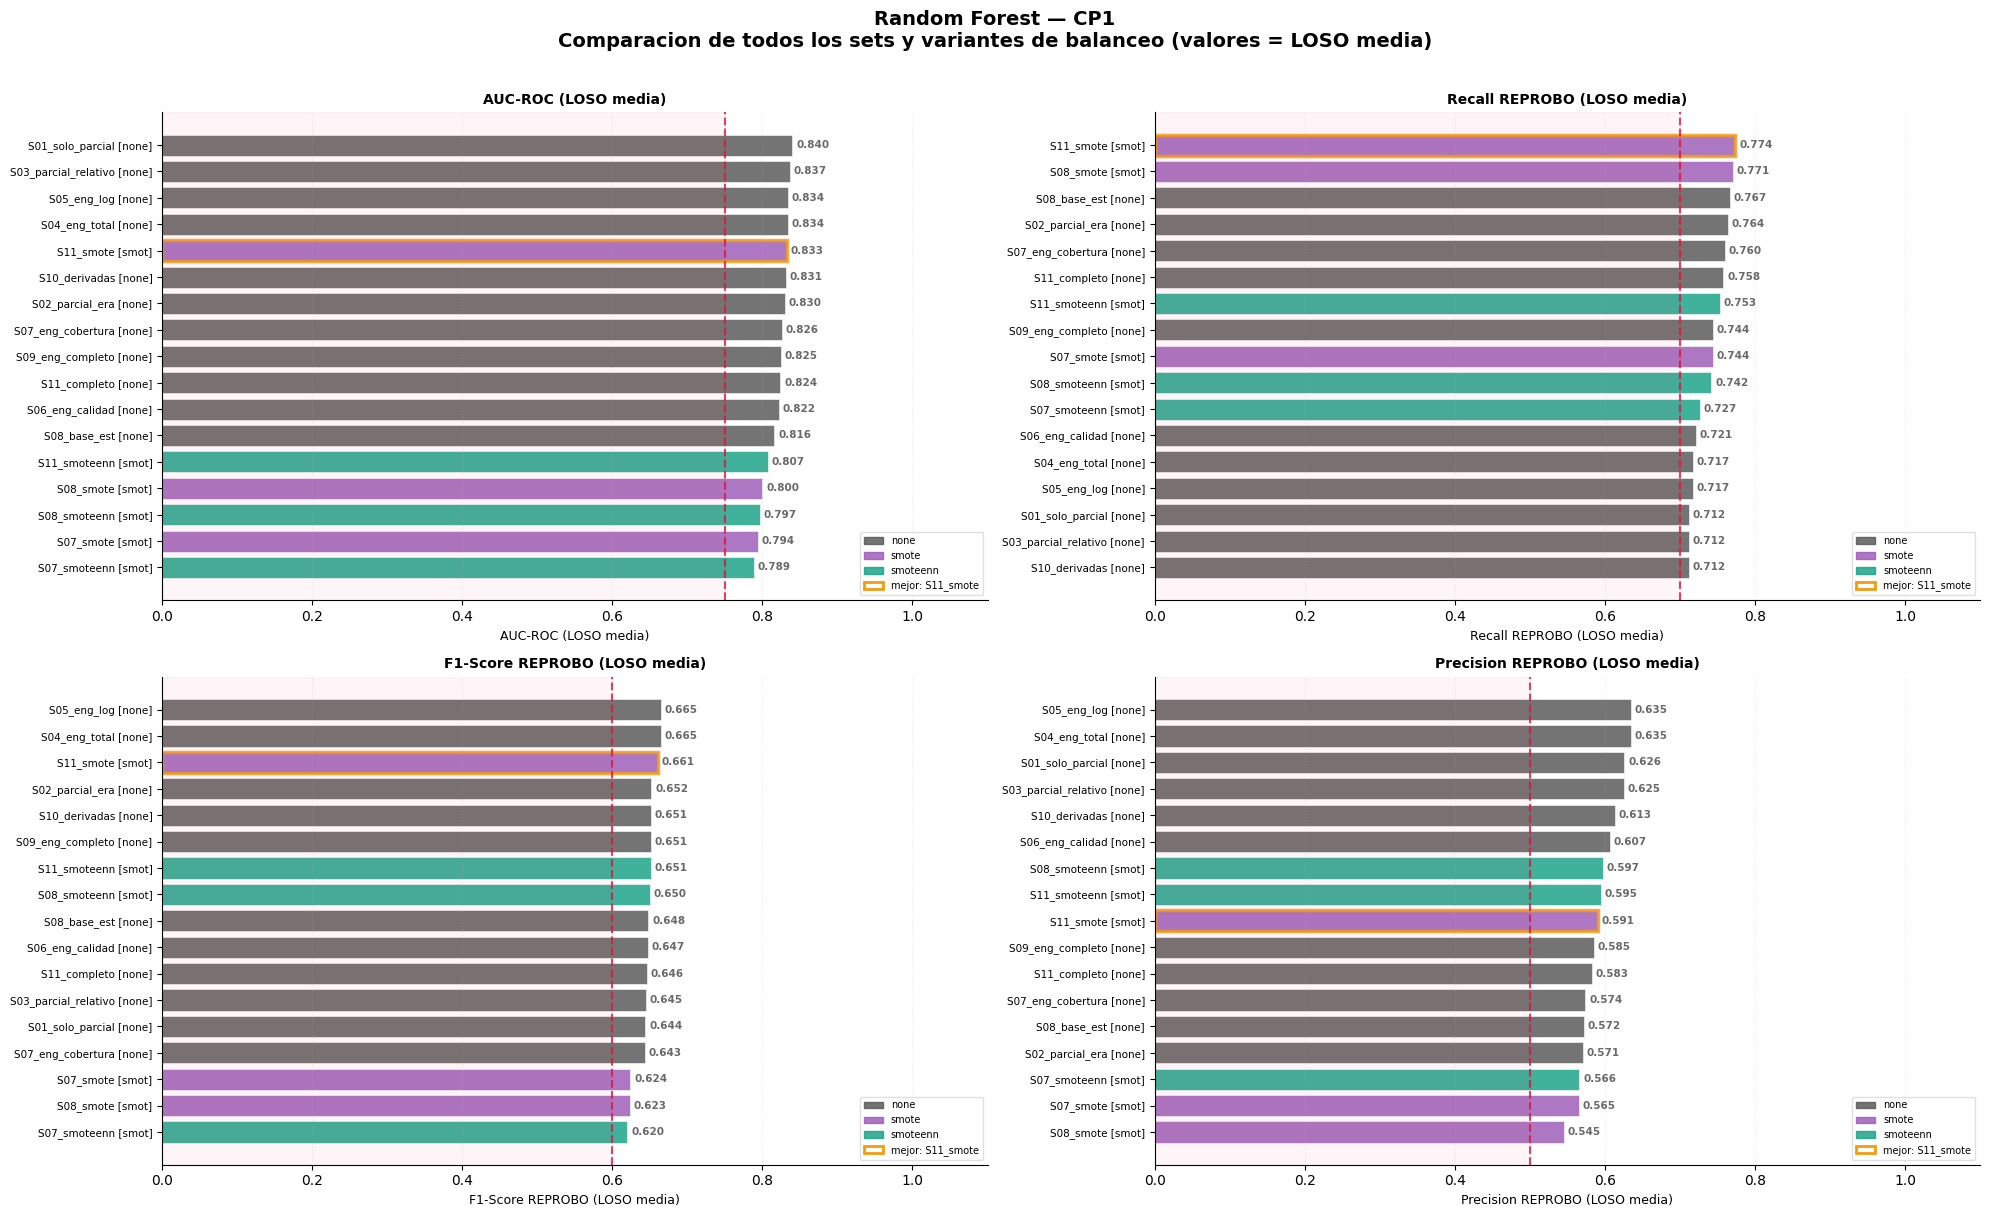

[PLOT] fig_rf_cp1.png guardado


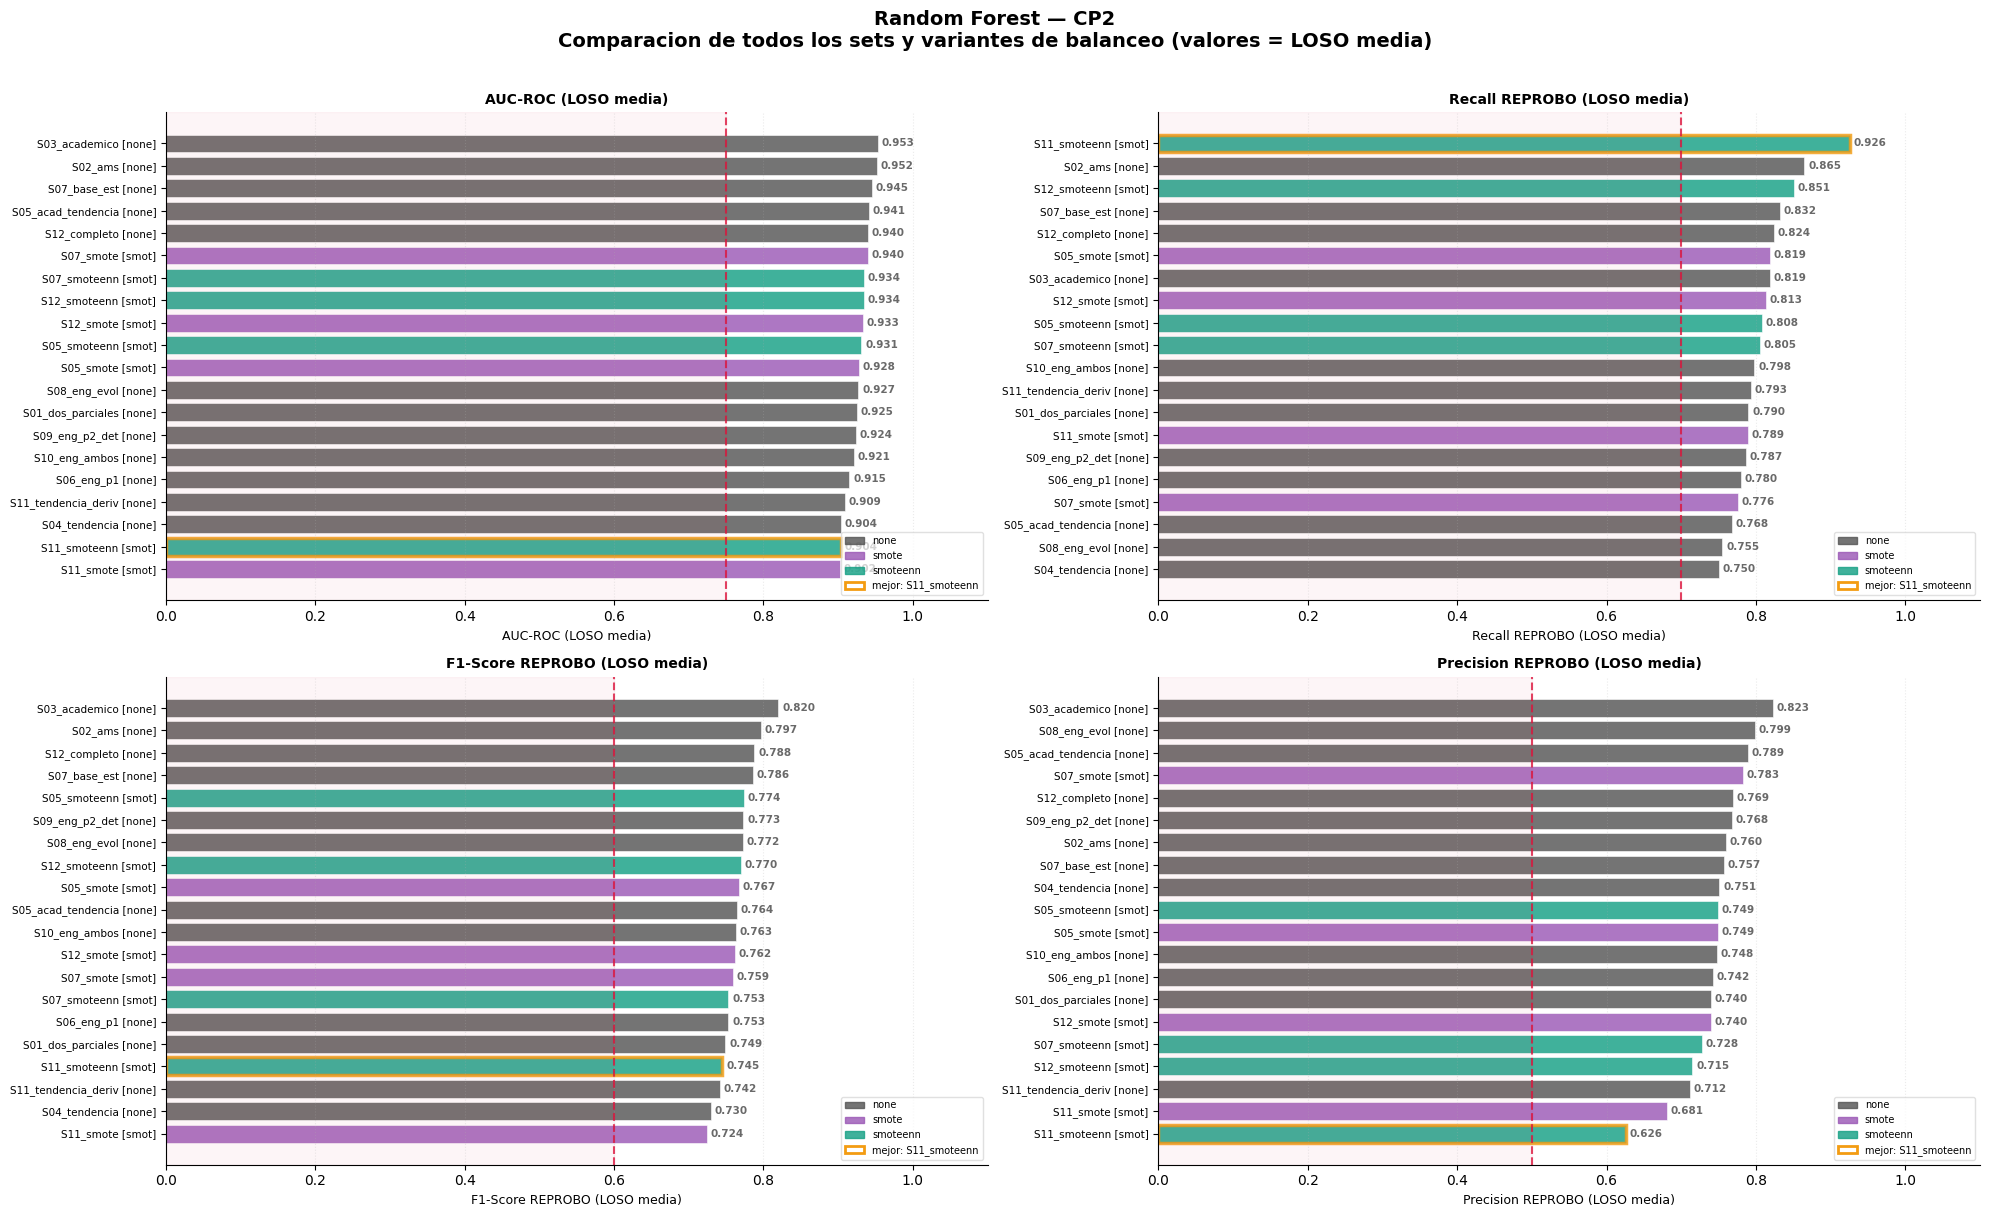

[PLOT] fig_rf_cp2.png guardado

[DIAGNOSTICO] Random Forest | CP1 | S11_smote
  AUC    LOSO=0.833 +/- 0.066
  Recall LOSO=0.774 +/- 0.132
  F1     LOSO=0.661 +/- 0.049


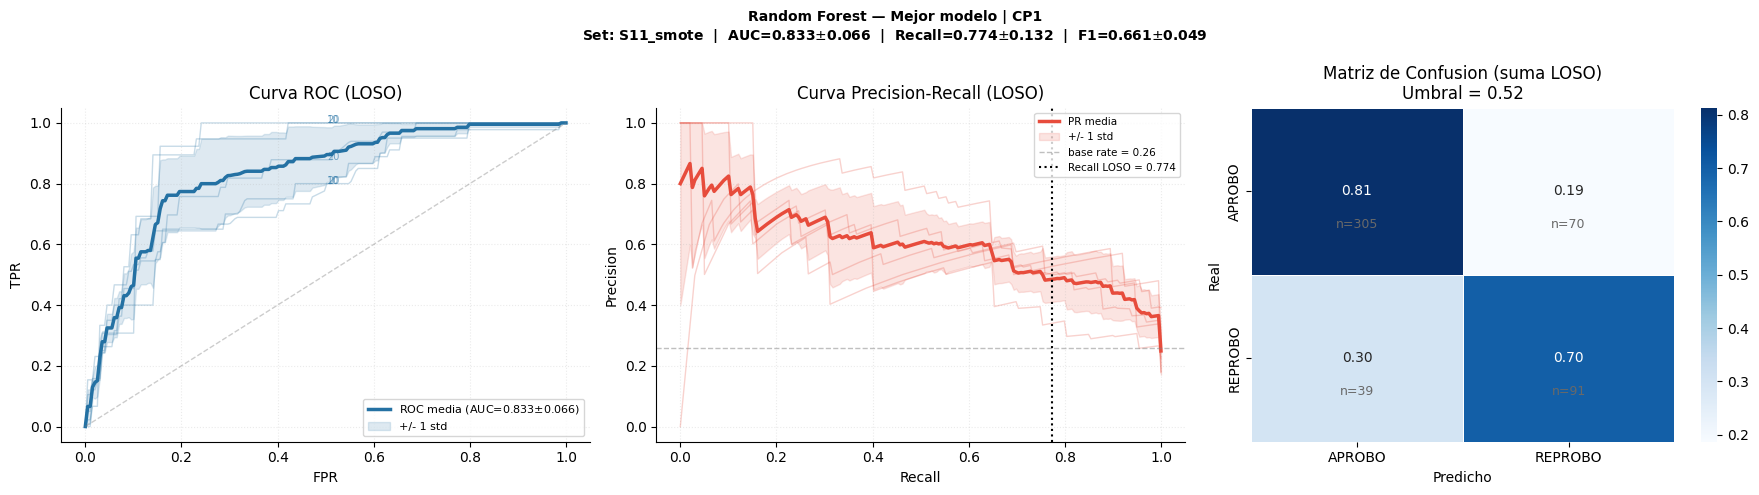

[PLOT] fig_rf_cp1_best.png guardado

[DIAGNOSTICO] Random Forest | CP2 | S11_smoteenn
  AUC    LOSO=0.904 +/- 0.071
  Recall LOSO=0.926 +/- 0.077
  F1     LOSO=0.745 +/- 0.079


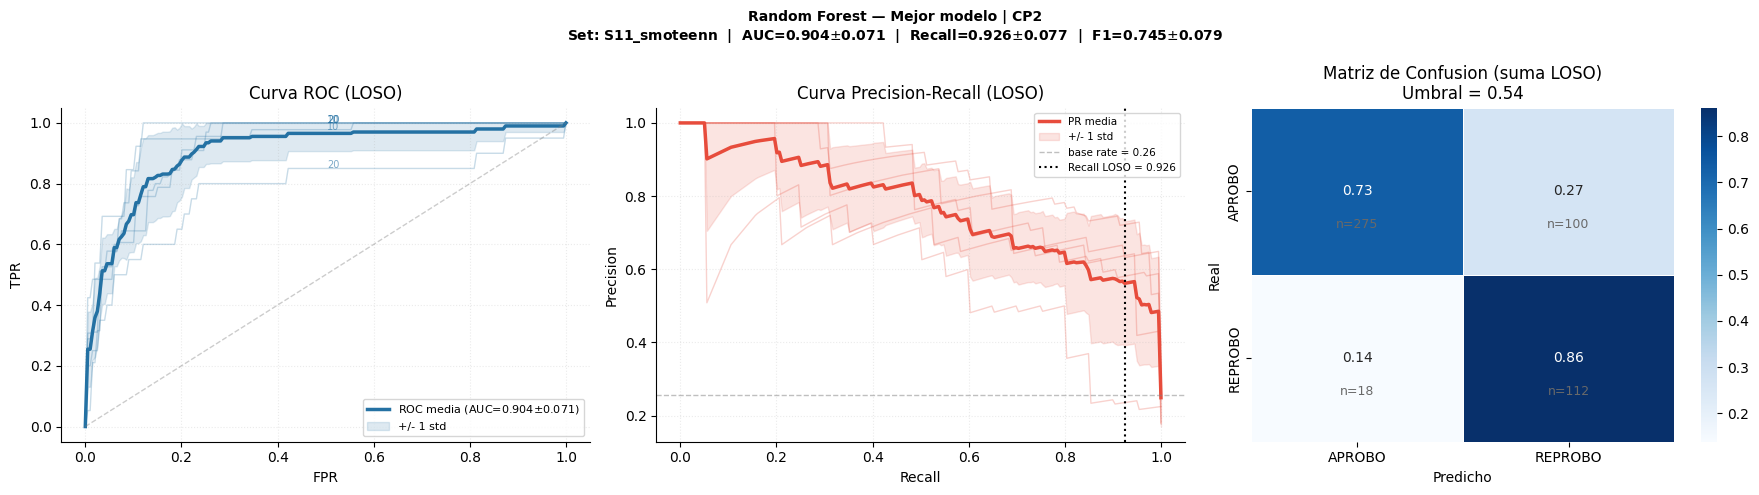

[PLOT] fig_rf_cp2_best.png guardado


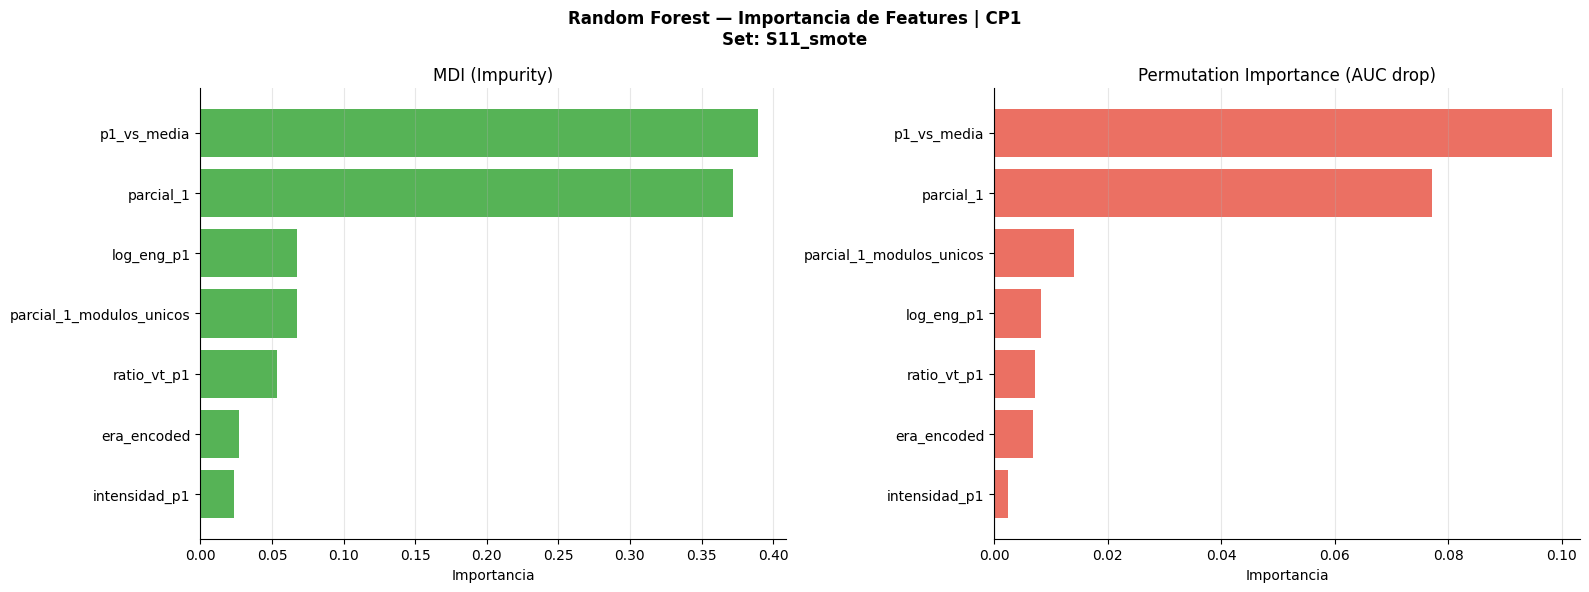

[PLOT] fig_rf_cp1_importance.png guardado

[RF CP1] Importancia permutacion por feature:
  p1_vs_media                           :   0.0983 +/- 0.0204
  parcial_1                             :   0.0771 +/- 0.0189
  parcial_1_modulos_unicos              :   0.0141 +/- 0.0071
  log_eng_p1                            :   0.0083 +/- 0.0037
  ratio_vt_p1                           :   0.0072 +/- 0.0025
  era_encoded                           :   0.0069 +/- 0.0041
  intensidad_p1                         :   0.0024 +/- 0.0014


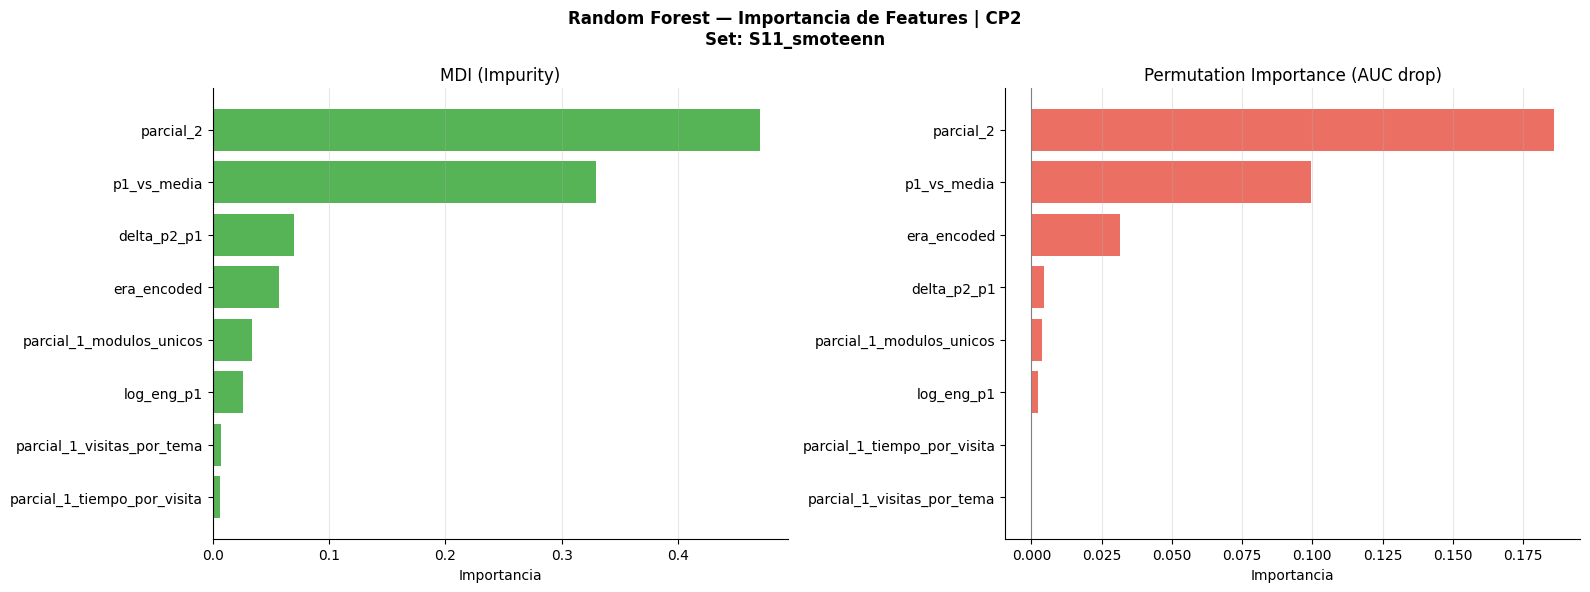

[PLOT] fig_rf_cp2_importance.png guardado

[RF CP2] Importancia permutacion por feature:
  parcial_2                             :   0.1860 +/- 0.0145
  p1_vs_media                           :   0.0994 +/- 0.0126
  era_encoded                           :   0.0314 +/- 0.0058
  delta_p2_p1                           :   0.0046 +/- 0.0025
  parcial_1_modulos_unicos              :   0.0037 +/- 0.0029
  log_eng_p1                            :   0.0022 +/- 0.0014
  parcial_1_tiempo_por_visita           :   0.0002 +/- 0.0007
  parcial_1_visitas_por_tema            :  -0.0000 +/- 0.0006


In [13]:
df_rf_cp1 = build_table(results_rf_cp1, 'RF')
df_rf_cp2 = build_table(results_rf_cp2, 'RF')
SP.out("\n[RF CP1] Top 10:"); SP.out(df_rf_cp1.head(10)[['set','n_feat','balanceo','AUC','Recall','Prec','F1','Umbral']].to_string(index=False))
SP.out("\n[RF CP2] Top 10:"); SP.out(df_rf_cp2.head(10)[['set','n_feat','balanceo','AUC','Recall','Prec','F1','Umbral']].to_string(index=False))

plot_model_comparison(df_rf_cp1, results_rf_cp1, "CP1", "Random Forest", "fig_rf_cp1.png")
plot_model_comparison(df_rf_cp2, results_rf_cp2, "CP2", "Random Forest", "fig_rf_cp2.png")
plot_best_diagnostics(results_rf_cp1, "Random Forest", "CP1", "fig_rf_cp1_best.png")
plot_best_diagnostics(results_rf_cp2, "Random Forest", "CP2", "fig_rf_cp2_best.png")

# ── Importancia MDI + Permutacion del mejor RF ────────────────────────────────
def plot_rf_importance(results_dict, df, cp_label, filename):
    """Importancia MDI y por permutacion del mejor modelo segun get_best_sn."""
    best_sn = get_best_sn(results_dict)
    r       = results_dict[best_sn]
    feats   = r['cfg']['features']
    m       = r['model_full']

    izeros = r['cfg'].get('impute_zeros', [])
    X = df[feats].copy()
    for f in izeros:
        if f in X.columns: X[f].fillna(0, inplace=True)
    sc = StandardScaler(); Xs = sc.fit_transform(X.fillna(0))
    y  = df['target'].values

    imp_mdi  = m.feature_importances_
    perm_res = permutation_importance(m, Xs, y, n_repeats=30,
                                      random_state=RANDOM_STATE, scoring='roc_auc')
    imp_perm = perm_res.importances_mean

    fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(feats) * 0.45)))
    fig.suptitle(f'Random Forest — Importancia de Features | {cp_label}\nSet: {best_sn}',
                 fontsize=12, fontweight='bold')

    idx_mdi  = np.argsort(imp_mdi)
    idx_perm = np.argsort(imp_perm)

    axes[0].barh([feats[i] for i in idx_mdi], imp_mdi[idx_mdi],
                 color='#2CA02C', alpha=0.8)
    axes[0].set(title='MDI (Impurity)', xlabel='Importancia')
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    col_perm = ['#E74C3C' if v > 0 else '#BDC3C7' for v in imp_perm[idx_perm]]
    axes[1].barh([feats[i] for i in idx_perm], imp_perm[idx_perm],
                 color=col_perm, alpha=0.8)
    axes[1].axvline(0, color='gray', lw=0.8)
    axes[1].set(title='Permutation Importance (AUC drop)', xlabel='Importancia')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    SP.out(f"[PLOT] {filename} guardado")

    SP.out(f"\n[RF {cp_label}] Importancia permutacion por feature:")
    for i in idx_perm[::-1]:
        SP.out(f"  {feats[i]:<38}: {imp_perm[i]:>8.4f} +/- {perm_res.importances_std[i]:.4f}")

plot_rf_importance(results_rf_cp1, df, "CP1", "fig_rf_cp1_importance.png")
plot_rf_importance(results_rf_cp2, df, "CP2", "fig_rf_cp2_importance.png")

# §8 — XGBoost

## 8.1 Descripción del modelo y consideraciones
**XGBoost** es el modelo de mayor capacidad predictiva de los cuatro evaluados. Al ser un algoritmo de *Gradient Boosting*, construye árboles de forma secuencial corrigiendo los errores de los anteriores. Dado el tamaño moderado del dataset ($N \approx 400$ por fold), se aplica una **regularización agresiva** para evitar que el modelo memorice el ruido de los semestres de entrenamiento.

| Parámetro de regularización | Efecto en el modelo |
| :--- | :--- |
| **max_depth** $\leq 4$ | Árboles intencionalmente "débiles" que generalizan mejor. |
| **learning_rate** bajo | Convergencia lenta y controlada para mayor robustez. |
| **reg_alpha (L1)** | Fomenta la parsimonia (pesos en cero) en los splits. |
| **reg_lambda (L2)** | Suaviza los pesos de las hojas (*shrinkage*). |
| **subsample** < 1.0 | Entrenamiento estocástico: usa solo una parte de los estudiantes por árbol. |
| **colsample_bytree** < 1.0 | Usa solo una parte de las variables por cada árbol. |
| **scale_pos_weight** | Ajusta el balance de clases (Recomendado: $N_{neg} / N_{pos} \approx 2.9$). |
| **min_child_weight** | Evita hojas que representen a muy pocos estudiantes. |

---

## 8.2 Grilla de búsqueda (Grid Search)
La exploración se centra en encontrar el punto exacto donde la capacidad del modelo se encuentra con la estabilidad temporal:

* **Estructura y Aprendizaje:**
    * `n_estimators`: [50, 100, 150, 200]
    * `max_depth`: [2, 3, 4]
    * `learning_rate`: [0.01, 0.05, 0.1, 0.2]
* **Muestreo y Robustez:**
    * `subsample`: [0.6, 0.8, 1.0]
    * `colsample_bytree`: [0.6, 0.8, 1.0]
    * `min_child_weight`: [1, 3, 5, 10]
* **Penalización y Balanceo:**
    * `reg_alpha`: [0, 0.1, 0.5, 1.0, 2.0]
    * `reg_lambda`: [1, 2, 5, 10]
    * `scale_pos_weight`: [1, 2, 3, 4]


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# §8 — XGBOOST
# ═══════════════════════════════════════════════════════════════════════════════
XGB_GRID = {
    'n_estimators':     [50, 100, 150, 200],
    'max_depth':        [2, 3, 4],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha':        [0, 0.1, 0.5, 1.0, 2.0],
    'reg_lambda':       [1, 2, 5, 10],
    'scale_pos_weight': [1, 2, 3, 4],
    'min_child_weight': [1, 3, 5, 10],
}
XGB_FIXED = {'use_label_encoder': False, 'eval_metric': 'logloss',
             'verbosity': 0, 'random_state': RANDOM_STATE}

results_xgb_cp1 = run_model_all(XGBClassifier, XGB_GRID,
                                  XGB_FIXED,
                                  FEATURE_SETS_CP1, df, loso, "XGBoost — CP1")
results_xgb_cp2 = run_model_all(XGBClassifier, XGB_GRID,
                                  XGB_FIXED,
                                  FEATURE_SETS_CP2, df, loso, "XGBoost — CP2")


########################################################################
#  XGBoost — CP1
########################################################################

  [S01_solo_parcial] buscando params...

════════════════════════════════════════════════════════════════════════
  MODELO   : XGBoost — CP1
  SET      : S01_solo_parcial
  FEATURES : ['parcial_1']
  N feat   : 1  |  Balanceo: none
────────────────────────────────────────────────────────────────────────
  HIPERPARAMETROS:
    subsample                        = 0.6
    scale_pos_weight                 = 1
    reg_lambda                       = 5
    reg_alpha                        = 1.0
    n_estimators                     = 150
    min_child_weight                 = 5
    max_depth                        = 2
    learning_rate                    = 0.01
    colsample_bytree                 = 0.6
    use_label_encoder                = False
    eval_metric                      = logloss
    verbosity                        = 

# 8.2 Tabla resumen e importancia de features


[XGB CP1] Top 10:
                 set  n_feat balanceo   AUC  Recall  Prec    F1  Umbral
   S07_eng_cobertura       5     none 0.829   0.788 0.568 0.658    0.59
       S04_eng_total       3     none 0.831   0.731 0.600 0.657    0.60
         S05_eng_log       3     none 0.831   0.731 0.600 0.657    0.60
        S08_smoteenn       6 smoteenn 0.808   0.775 0.585 0.653    0.58
        S11_completo       7     none 0.826   0.754 0.590 0.653    0.30
     S06_eng_calidad       4     none 0.837   0.792 0.564 0.649    0.28
    S09_eng_completo       7     none 0.819   0.723 0.599 0.645    0.32
        S08_base_est       6     none 0.828   0.707 0.632 0.644    0.31
           S11_smote       7    smote 0.821   0.766 0.553 0.640    0.74
S03_parcial_relativo       3     none 0.844   0.733 0.588 0.639    0.46

[XGB CP2] Top 10:
               set  n_feat balanceo   AUC  Recall  Prec    F1  Umbral
     S03_academico       5     none 0.963   0.887 0.813 0.843    0.57
      S12_completo      12    

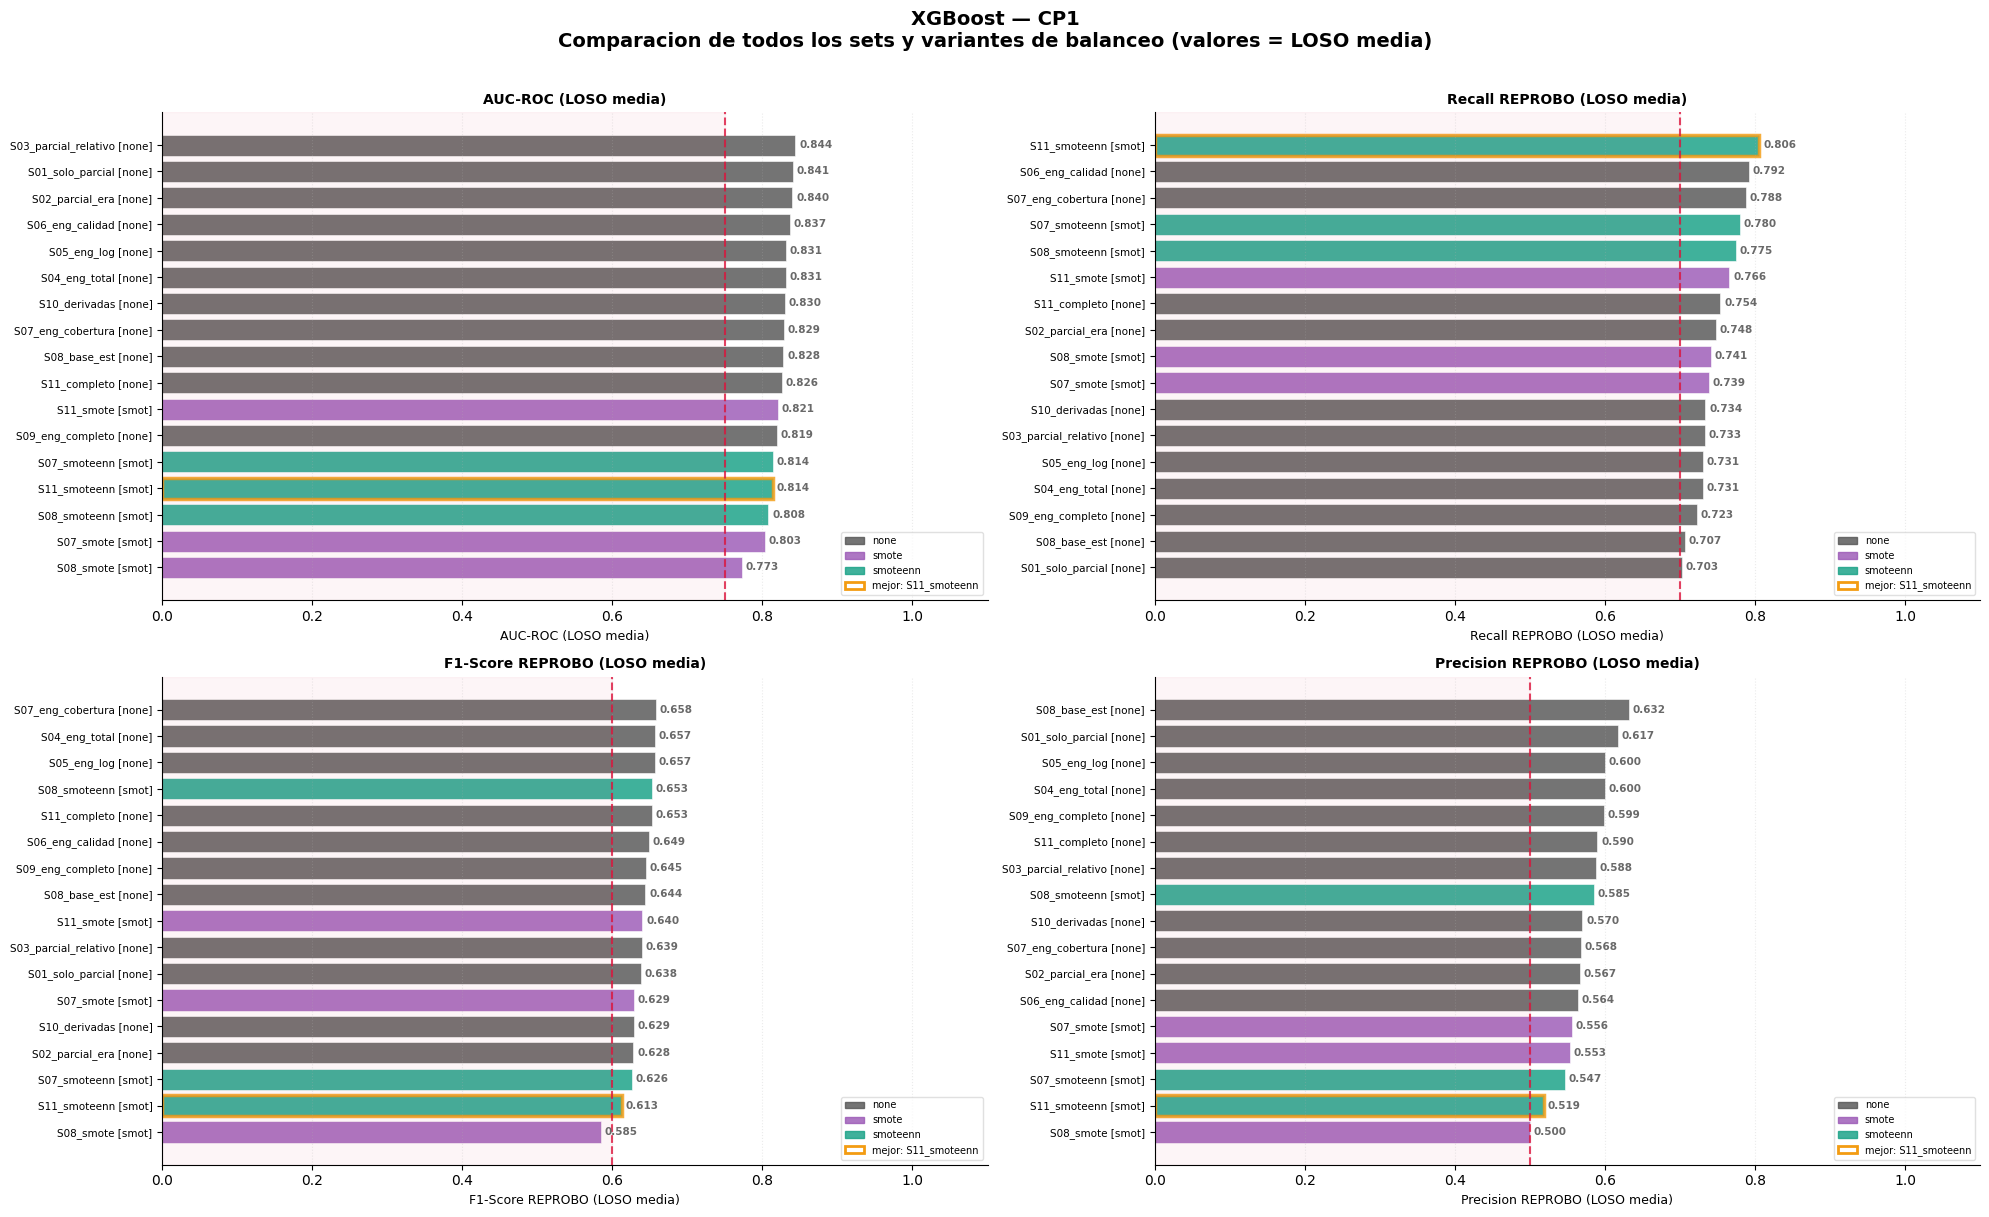

[PLOT] fig_xgb_cp1.png guardado


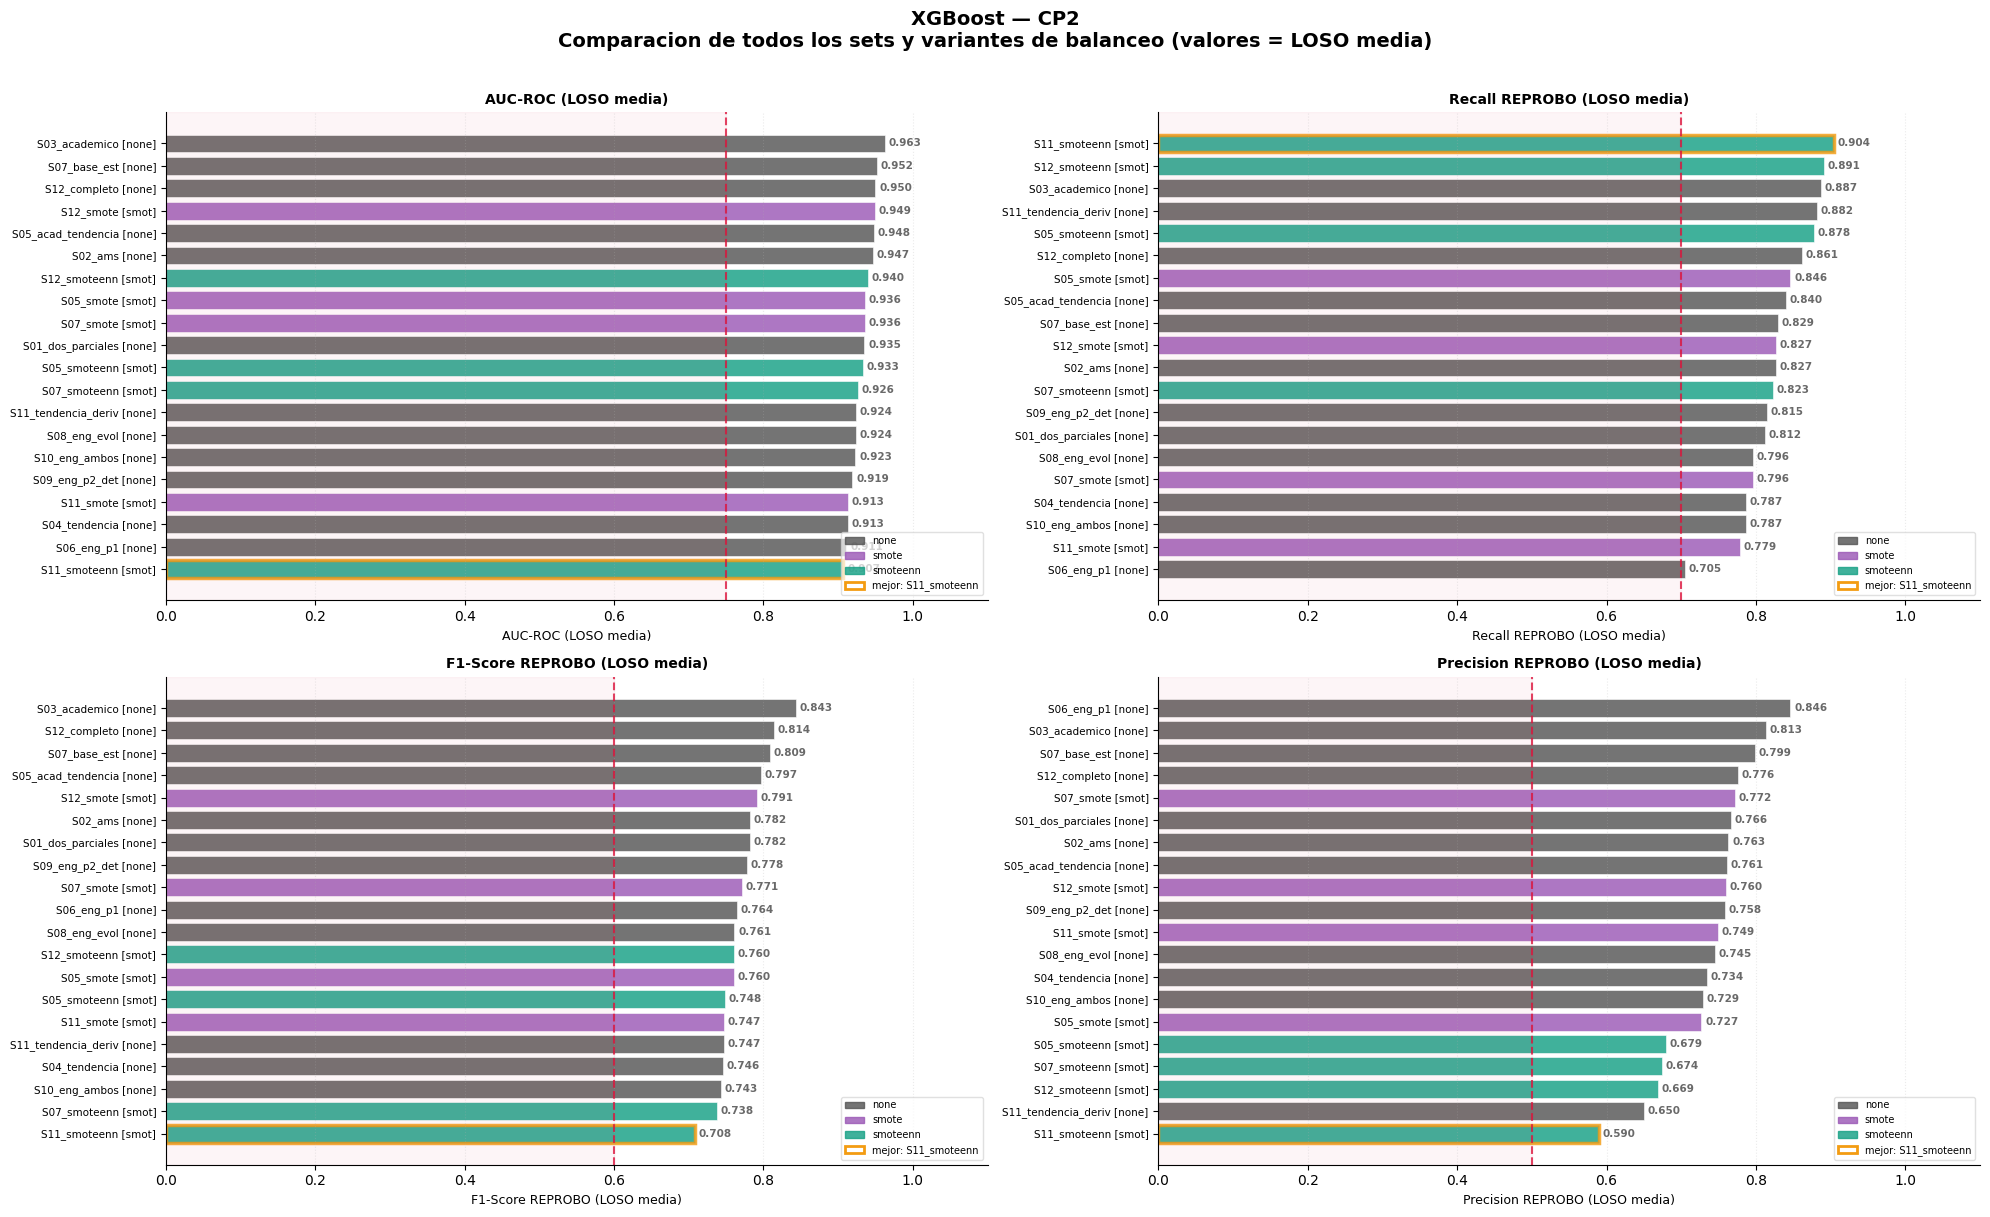

[PLOT] fig_xgb_cp2.png guardado

[DIAGNOSTICO] XGBoost | CP1 | S11_smoteenn
  AUC    LOSO=0.814 +/- 0.073
  Recall LOSO=0.806 +/- 0.133
  F1     LOSO=0.613 +/- 0.057


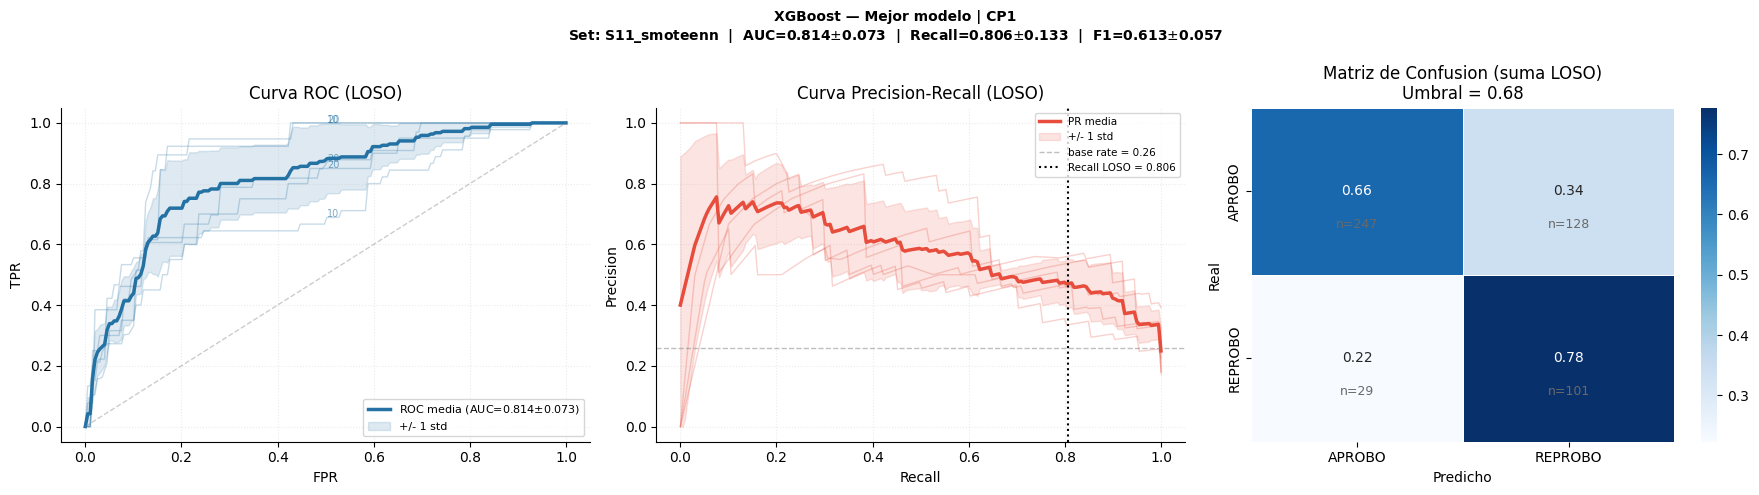

[PLOT] fig_xgb_cp1_best.png guardado

[DIAGNOSTICO] XGBoost | CP2 | S11_smoteenn
  AUC    LOSO=0.907 +/- 0.068
  Recall LOSO=0.904 +/- 0.060
  F1     LOSO=0.708 +/- 0.099


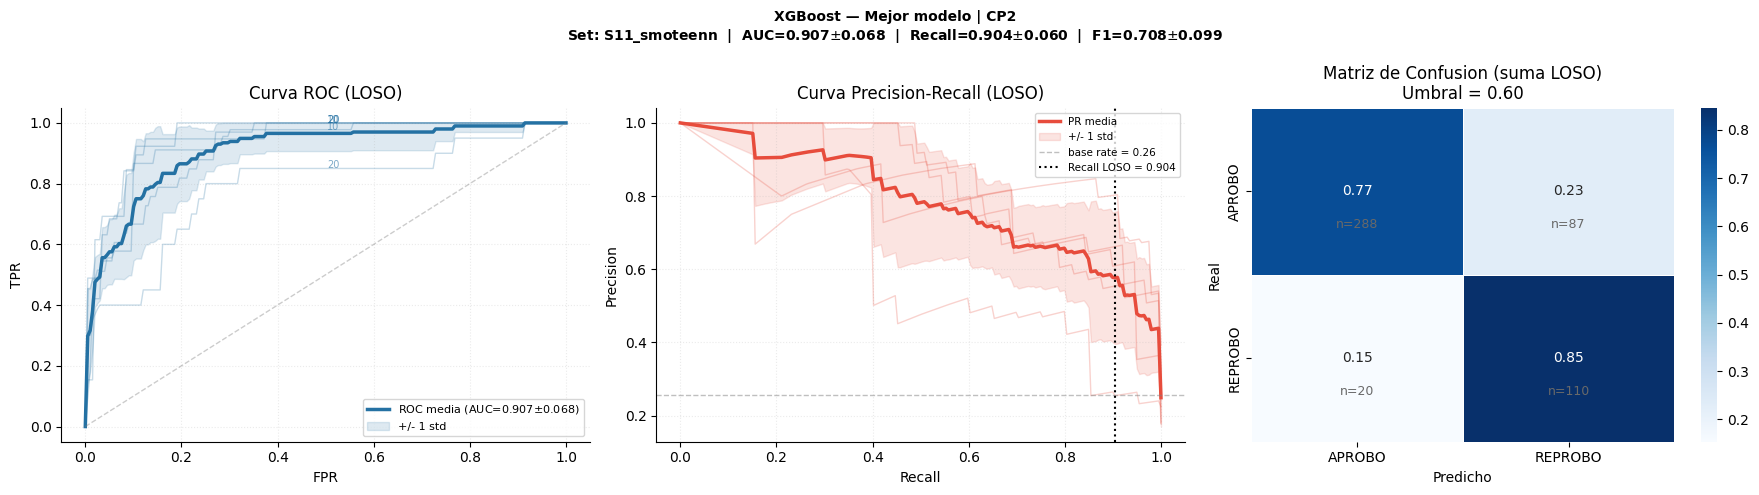

[PLOT] fig_xgb_cp2_best.png guardado


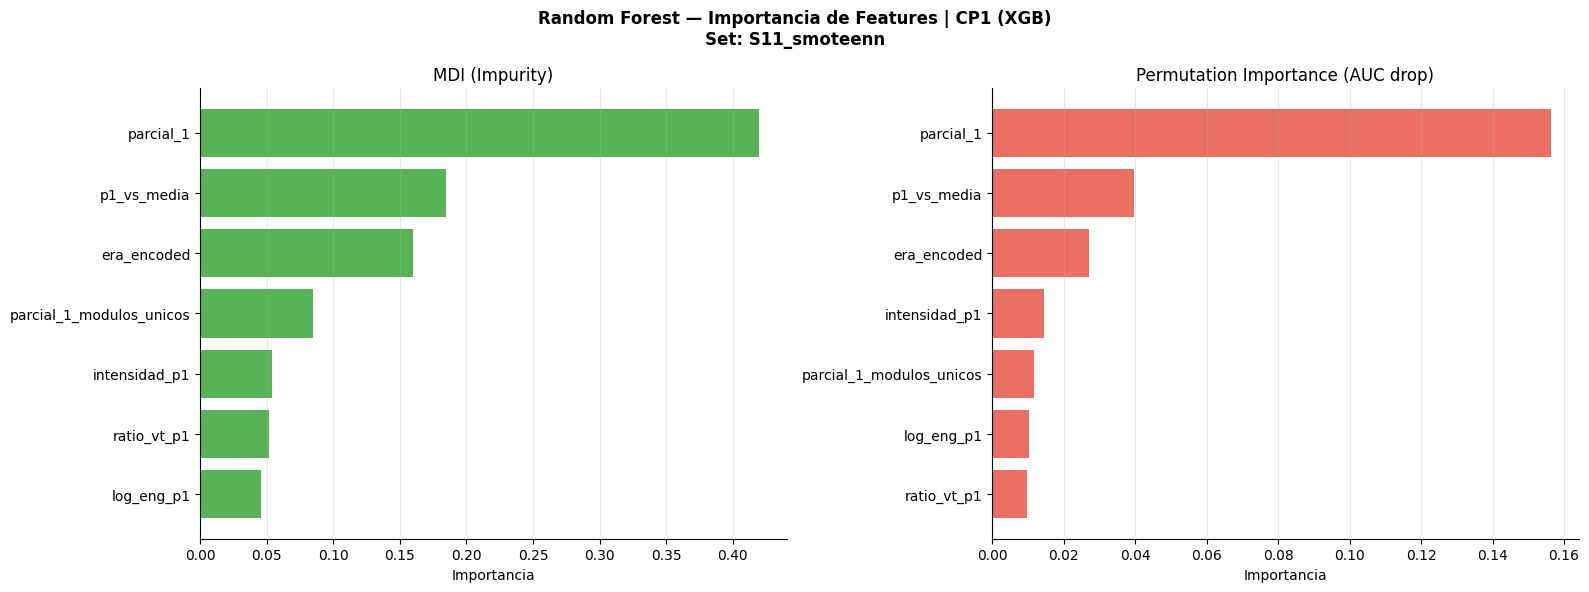

[PLOT] fig_xgb_cp1_importance.png guardado

[RF CP1 (XGB)] Importancia permutacion por feature:
  parcial_1                             :   0.1562 +/- 0.0243
  p1_vs_media                           :   0.0396 +/- 0.0120
  era_encoded                           :   0.0270 +/- 0.0095
  intensidad_p1                         :   0.0146 +/- 0.0051
  parcial_1_modulos_unicos              :   0.0117 +/- 0.0047
  log_eng_p1                            :   0.0104 +/- 0.0049
  ratio_vt_p1                           :   0.0098 +/- 0.0031


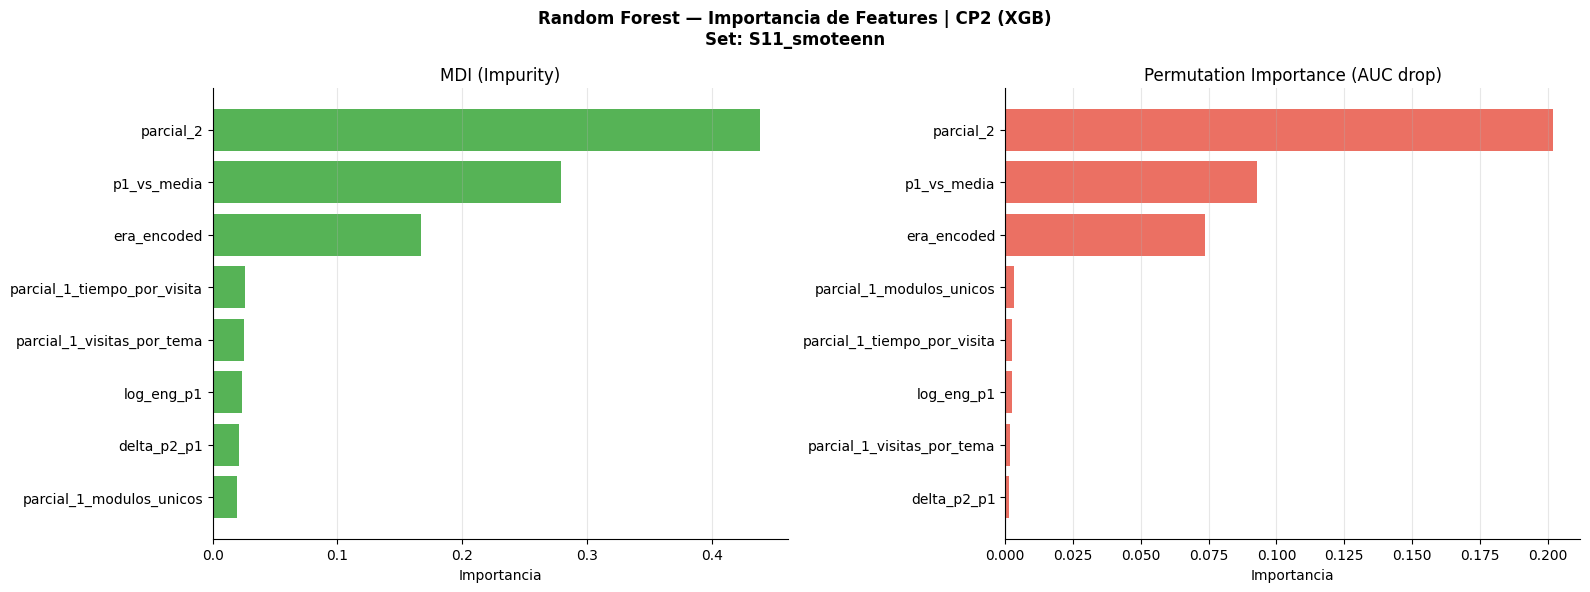

[PLOT] fig_xgb_cp2_importance.png guardado

[RF CP2 (XGB)] Importancia permutacion por feature:
  parcial_2                             :   0.2018 +/- 0.0137
  p1_vs_media                           :   0.0928 +/- 0.0097
  era_encoded                           :   0.0735 +/- 0.0123
  parcial_1_modulos_unicos              :   0.0031 +/- 0.0011
  parcial_1_tiempo_por_visita           :   0.0024 +/- 0.0018
  log_eng_p1                            :   0.0023 +/- 0.0034
  parcial_1_visitas_por_tema            :   0.0018 +/- 0.0020
  delta_p2_p1                           :   0.0012 +/- 0.0027


In [15]:
df_xgb_cp1 = build_table(results_xgb_cp1, 'XGB')
df_xgb_cp2 = build_table(results_xgb_cp2, 'XGB')
SP.out("\n[XGB CP1] Top 10:"); SP.out(df_xgb_cp1.head(10)[['set','n_feat','balanceo','AUC','Recall','Prec','F1','Umbral']].to_string(index=False))
SP.out("\n[XGB CP2] Top 10:"); SP.out(df_xgb_cp2.head(10)[['set','n_feat','balanceo','AUC','Recall','Prec','F1','Umbral']].to_string(index=False))

plot_model_comparison(df_xgb_cp1, results_xgb_cp1, "CP1", "XGBoost", "fig_xgb_cp1.png")
plot_model_comparison(df_xgb_cp2, results_xgb_cp2, "CP2", "XGBoost", "fig_xgb_cp2.png")
plot_best_diagnostics(results_xgb_cp1, "XGBoost", "CP1", "fig_xgb_cp1_best.png")
plot_best_diagnostics(results_xgb_cp2, "XGBoost", "CP2", "fig_xgb_cp2_best.png")
plot_rf_importance(results_xgb_cp1, df, "CP1 (XGB)", "fig_xgb_cp1_importance.png")
plot_rf_importance(results_xgb_cp2, df, "CP2 (XGB)", "fig_xgb_cp2_importance.png")

# §9 — Comparación final entre los cuatro modelos
## 9.1 Tabla maestra
Esta sección consolida los mejores modelos de cada familia (el set con mayor
F1-Score) y los compara directamente para cada checkpoint.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# §9 — COMPARACIÓN FINAL
# ═══════════════════════════════════════════════════════════════════════════════

def select_best(rd):
    """
    Regla de selección del mejor experimento en un results_dict:
      1. Filtrar candidatos con AUC >= 0.75 (umbral mínimo de discriminación).
      2. De los que pasan, seleccionar el de mayor Recall (REPROBÓ).
      3. En caso de empate en Recall (diferencia < 0.005), seleccionar el de mayor F1.
      4. Si ninguno supera AUC >= 0.75, relajar el filtro y seleccionar por Recall + F1
         (informando que no se alcanza el umbral mínimo).
    Retorna (set_name, entry, cumple_auc_min).
    """
    candidatos = {k: v for k, v in rd.items() if v['res']['auc_m'] >= 0.75}
    cumple_auc = True
    if not candidatos:
        candidatos = rd  # relajar filtro
        cumple_auc = False

    # Ordenar por Recall desc, luego F1 desc como desempate
    mejor_key = max(
        candidatos,
        key=lambda k: (round(candidatos[k]['res']['rec_m'], 3),
                       round(candidatos[k]['res']['f1_m'], 3))
    )
    return mejor_key, candidatos[mejor_key], cumple_auc


def master_table(all_dicts, cp_label):
    """Extrae el mejor set de cada modelo con la regla AUC>=0.75 -> max Recall -> F1."""
    SP.out(f"\n{'='*72}")
    SP.out(f"  TABLA MAESTRA — {cp_label}")
    SP.out(f"  Regla: AUC >= 0.75 -> max Recall -> F1 (desempate)")
    SP.out(f"{'='*72}")
    rows = []
    tags = [('LR', all_dicts[0]), ('DT', all_dicts[1]),
            ('RF', all_dicts[2]), ('XGB', all_dicts[3])]
    for tag, rd in tags:
        best_sn, best, cumple = select_best(rd)
        nota_auc = '' if cumple else ' [!AUC<0.75]'
        rows.append({
            'Modelo':    tag,
            'Mejor set': best_sn,
            'N feat':    len(best['cfg']['features']),
            'Balanceo':  best['cfg']['balanceo'],
            'AUC':       round(best['res']['auc_m'], 3),
            'AUC+-':     round(best['res']['auc_s'], 3),
            'Recall':    round(best['res']['rec_m'], 3),
            'Rec+-':     round(best['res']['rec_s'], 3),
            'Prec':      round(best['res']['pre_m'], 3),
            'F1':        round(best['res']['f1_m'], 3),
            'F1+-':      round(best['res']['f1_s'], 3),
            'Acc':       round(best['res']['acc_m'], 3),
            'Umbral':    round(best['res']['t_m'], 2),
            'OK_AUC':    'SI' + nota_auc if cumple else 'NO',
        })
    df_m = pd.DataFrame(rows).sort_values(['Recall', 'F1'], ascending=False)
    SP.out(df_m.to_string(index=False))

    # Ganador global: AUC >= 0.75, mayor Recall, F1 como desempate
    aptos = df_m[df_m['OK_AUC'].str.startswith('SI')]
    g = aptos.iloc[0] if len(aptos) > 0 else df_m.iloc[0]
    SP.out(f"\n  GANADOR: {g['Modelo']} — {g['Mejor set']}")
    SP.out(f"  AUC >= 0.75   : {g['OK_AUC']} ({g['AUC']:.3f})")
    SP.out(f"  Recall (max)  : {g['Recall']:.3f}")
    SP.out(f"  F1-Score      : {g['F1']:.3f}")
    return df_m

df_master_cp1 = master_table(
    [results_lr_cp1, results_dt_cp1, results_rf_cp1, results_xgb_cp1], "CP1")
df_master_cp2 = master_table(
    [results_lr_cp2, results_dt_cp2, results_rf_cp2, results_xgb_cp2], "CP2")


  TABLA MAESTRA — CP1
  Regla: AUC >= 0.75 -> max Recall -> F1 (desempate)
Modelo    Mejor set  N feat Balanceo   AUC  AUC+-  Recall  Rec+-  Prec    F1  F1+-   Acc  Umbral OK_AUC
   XGB S11_smoteenn       7 smoteenn 0.814  0.073   0.806  0.133 0.519 0.613 0.057 0.758    0.68     SI
    DT S08_smoteenn       6 smoteenn 0.795  0.081   0.783  0.126 0.523 0.606 0.071 0.754    0.56     SI
    RF    S11_smote       7    smote 0.833  0.066   0.774  0.132 0.591 0.661 0.049 0.811    0.52     SI
    LR S08_smoteenn       6 smoteenn 0.843  0.060   0.757  0.160 0.583 0.637 0.024 0.792    0.59     SI

  GANADOR: XGB — S11_smoteenn
  AUC >= 0.75   : SI (0.814)
  Recall (max)  : 0.806
  F1-Score      : 0.613

  TABLA MAESTRA — CP2
  Regla: AUC >= 0.75 -> max Recall -> F1 (desempate)
Modelo    Mejor set  N feat Balanceo   AUC  AUC+-  Recall  Rec+-  Prec    F1  F1+-   Acc  Umbral OK_AUC
    DT S11_smoteenn       8 smoteenn 0.866  0.030   0.932  0.083 0.536 0.672 0.083 0.786    0.34     SI
    RF S11_s

## 9.2 Gráficas comparativas entre modelos

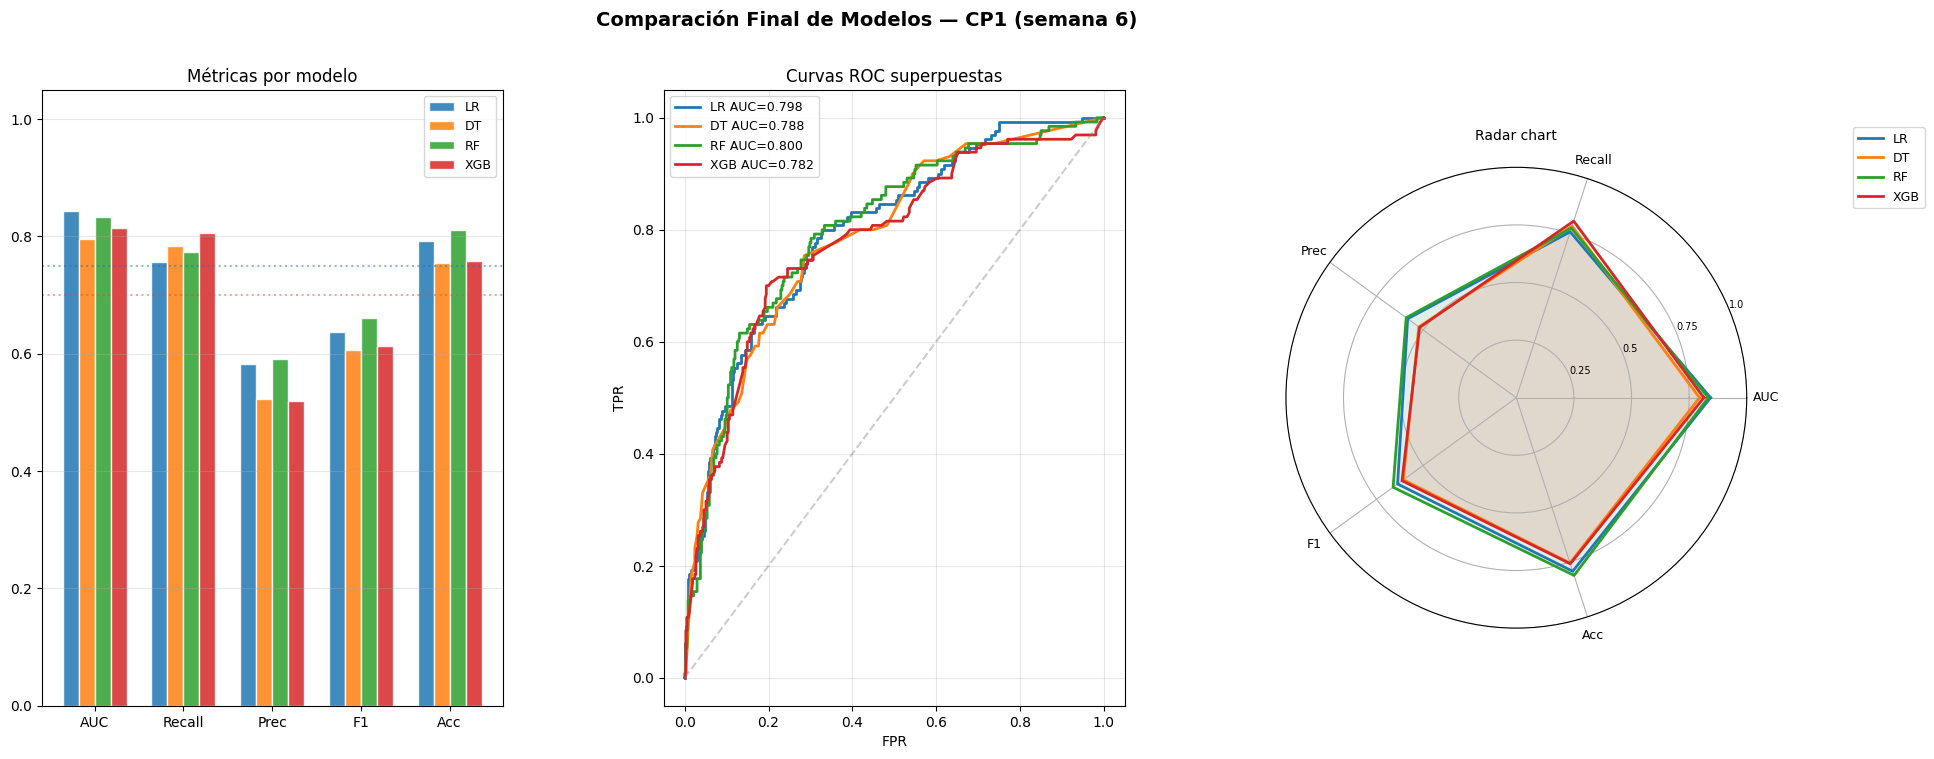

[PLOT] fig_comparacion_final_cp1.png guardado


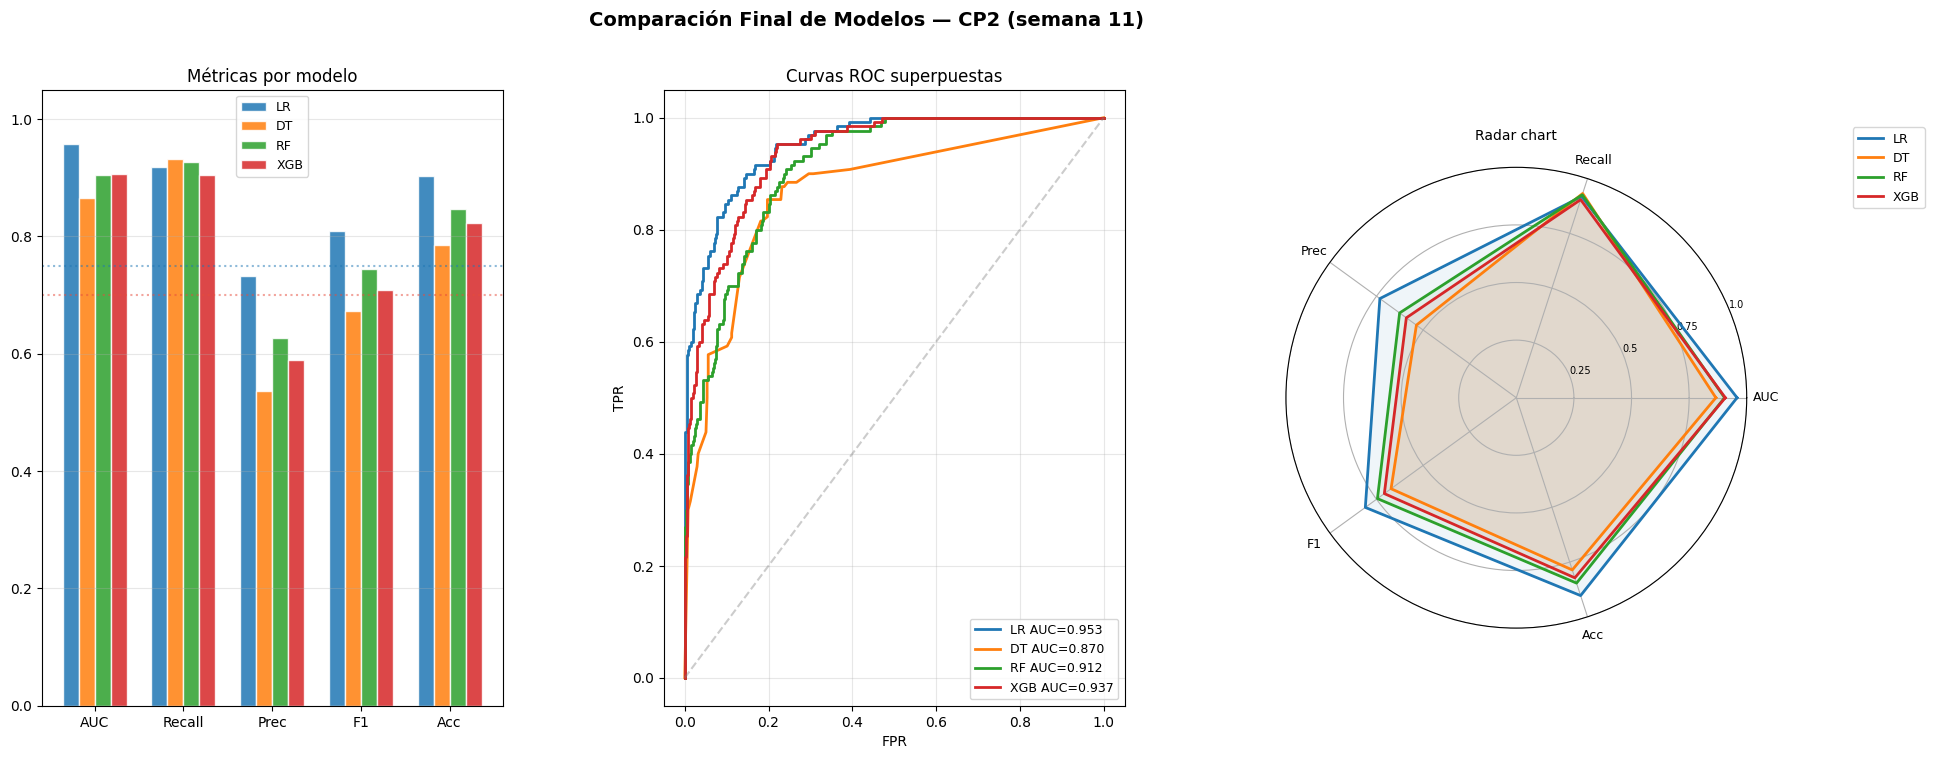

[PLOT] fig_comparacion_final_cp2.png guardado


In [17]:
# ── ROC superpuestas + barras agrupadas + radar chart ─────────────────────────
def plot_final_comparison(all_dicts, df_master, cp_label, filename):
    tags = ['LR', 'DT', 'RF', 'XGB']
    fig  = plt.figure(figsize=(22, 8))
    fig.suptitle(f'Comparación Final de Modelos — {cp_label}',
                 fontsize=14, fontweight='bold')
    gs   = fig.add_gridspec(1, 3, wspace=0.35)

    # ── Barras agrupadas ──────────────────────────────────────────────────────
    ax1    = fig.add_subplot(gs[0])
    mets   = ['AUC', 'Recall', 'Prec', 'F1', 'Acc']
    x      = np.arange(len(mets)); w = 0.18
    df_plt = df_master.set_index('Modelo').reindex(tags).reset_index()
    for i, (_, row) in enumerate(df_plt.iterrows()):
        vals = [row[m] for m in mets]
        ax1.bar(x + i*w, vals, w, label=row['Modelo'],
                color=COLORS.get(row['Modelo'],'gray'), alpha=0.85, edgecolor='white')
    ax1.set_xticks(x + w*1.5); ax1.set_xticklabels(mets)
    ax1.set_ylim(0, 1.05); ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)
    ax1.axhline(0.75, color='#1F77B4', ls=':', alpha=0.5)
    ax1.axhline(0.70, color='#E74C3C', ls=':', alpha=0.5)
    ax1.set_title('Métricas por modelo')

    # ── Curvas ROC superpuestas ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    for rd, tag in zip(all_dicts, tags):
        best = max(rd.values(), key=lambda r: r['res']['f1_m'])
        yt   = np.array(best['res']['yt']); yp = np.array(best['res']['yp'])
        try:
            fpr, tpr, _ = roc_curve(yt, yp)
            ax2.plot(fpr, tpr, lw=2, color=COLORS[tag],
                     label=f"{tag} AUC={roc_auc_score(yt,yp):.3f}")
        except: pass
    ax2.plot([0,1],[0,1],'--',color='gray',alpha=0.4)
    ax2.set(xlabel='FPR', ylabel='TPR', title='Curvas ROC superpuestas')
    ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

    # ── Radar chart ───────────────────────────────────────────────────────────
    ax3    = fig.add_subplot(gs[2], polar=True)
    rmets  = ['AUC', 'Recall', 'Prec', 'F1', 'Acc']
    N      = len(rmets)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist(); angles += angles[:1]
    ax3.set_xticks(angles[:-1]); ax3.set_xticklabels(rmets, fontsize=9)
    ax3.set_ylim(0, 1); ax3.set_yticks([0.25,0.5,0.75,1.0])
    ax3.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=7)
    df_plt2 = df_master.set_index('Modelo').reindex(tags).reset_index()
    for _, row in df_plt2.iterrows():
        vals = [row[m] for m in rmets] + [row[rmets[0]]]
        ax3.plot(angles, vals, lw=2, color=COLORS.get(row['Modelo'],'gray'),
                 label=row['Modelo'])
        ax3.fill(angles, vals, alpha=0.07, color=COLORS.get(row['Modelo'],'gray'))
    ax3.legend(loc='upper right', bbox_to_anchor=(1.4,1.1), fontsize=9)
    ax3.set_title('Radar chart', fontsize=10, pad=20)

    plt.savefig(filename, dpi=150, bbox_inches='tight'); plt.show()
    SP.out(f"[PLOT] {filename} guardado")

plot_final_comparison(
    [results_lr_cp1, results_dt_cp1, results_rf_cp1, results_xgb_cp1],
    df_master_cp1, "CP1 (semana 6)", "fig_comparacion_final_cp1.png")
plot_final_comparison(
    [results_lr_cp2, results_dt_cp2, results_rf_cp2, results_xgb_cp2],
    df_master_cp2, "CP2 (semana 11)", "fig_comparacion_final_cp2.png")

## 9.3 Estabilidad entre folds del modelo ganador
La varianza entre folds es tan importante como la media. Un modelo con AUC medio
alto pero alta desviación estándar es menos confiable para producción que uno
con AUC ligeramente menor pero consistente en todos los semestres.

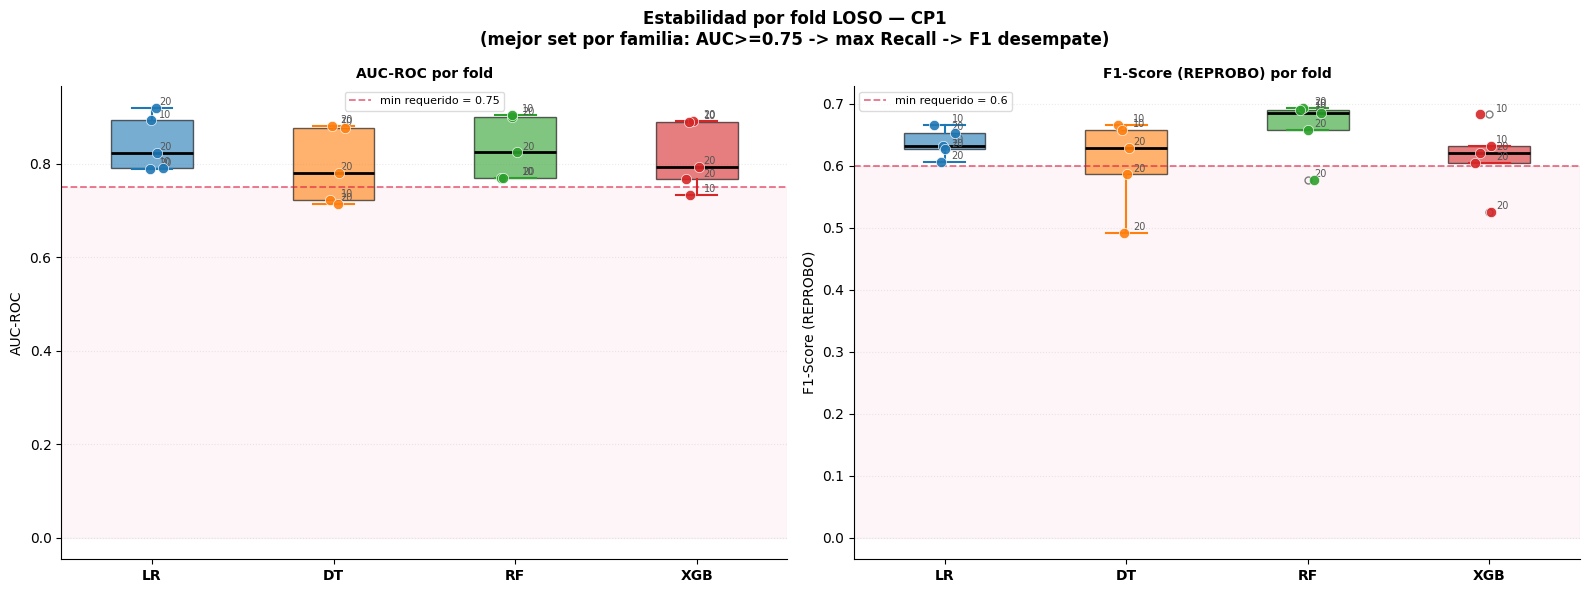

[PLOT] fig_estabilidad_cp1.png guardado


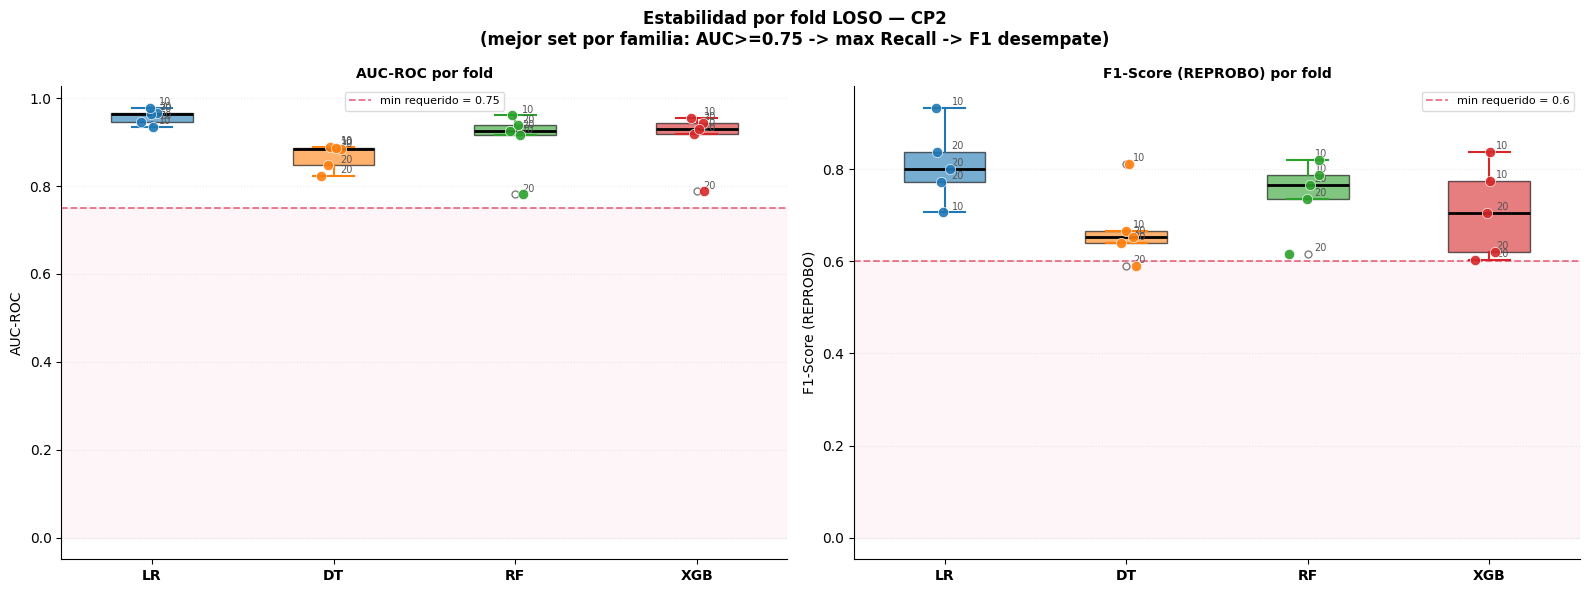

[PLOT] fig_estabilidad_cp2.png guardado


In [18]:
def plot_stability(all_dicts, tags, cp_label, filename):
    """
    Boxplot de AUC y F1 por fold LOSO para el mejor modelo de cada familia.
    La selección del 'mejor' sigue la regla: AUC>=0.75 -> max Recall -> F1.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Estabilidad por fold LOSO — {cp_label}\n'
                 f'(mejor set por familia: AUC>=0.75 -> max Recall -> F1 desempate)',
                 fontsize=12, fontweight='bold')

    refs = {'auc': 0.75, 'f1': 0.60}
    titles = {'auc': 'AUC-ROC por fold', 'f1': 'F1-Score (REPROBO) por fold'}
    ylbls  = {'auc': 'AUC-ROC',          'f1': 'F1-Score (REPROBO)'}

    sems = ['202320', '202410', '202420', '202510', '202520']

    for metric, ax in zip(['auc', 'f1'], axes):
        data, lbls, best_labels = [], [], []
        for rd, tag in zip(all_dicts, tags):
            best_sn, best, _ = select_best(rd)
            fold_vals = best['res']['folds'][metric].values
            data.append(fold_vals)
            lbls.append(tag)
            best_labels.append(f"{tag}\n({best_sn})")

        bp = ax.boxplot(data, patch_artist=True,
                        medianprops=dict(color='black', lw=2),
                        whiskerprops=dict(lw=1.5),
                        capprops=dict(lw=1.5),
                        flierprops=dict(marker='o', markersize=5, alpha=0.5))

        for i, (vals, tag) in enumerate(zip(data, tags)):
            col = COLORS.get(tag, 'gray')
            bp['boxes'][i].set_facecolor(col)
            bp['boxes'][i].set_alpha(0.6)
            bp['whiskers'][2*i].set_color(col)
            bp['whiskers'][2*i+1].set_color(col)
            bp['caps'][2*i].set_color(col)
            bp['caps'][2*i+1].set_color(col)

            jit = np.random.normal(0, 0.04, len(vals))
            ax.scatter([i + 1 + j for j in jit], vals,
                       color=col, s=55, alpha=0.9, zorder=5, edgecolors='white', lw=0.5)
            for v, sem in zip(vals, sems):
                ax.annotate(sem[-2:], (i + 1, v),
                            xytext=(5, 2), textcoords='offset points',
                            fontsize=7, color='#555555')

        ref = refs[metric]
        ax.axhline(ref, color='crimson', ls='--', lw=1.3, alpha=0.6,
                   label=f'min requerido = {ref}')
        ax.axhspan(0, ref, alpha=0.04, color='crimson')

        ax.set_xticks(range(1, len(lbls) + 1))
        ax.set_xticklabels(lbls, fontsize=10, fontweight='bold')
        ax.set_ylabel(ylbls[metric], fontsize=10)
        ax.set_title(titles[metric], fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.25, linestyle=':')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(fontsize=8, framealpha=0.7)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    SP.out(f"[PLOT] {filename} guardado")

axes_placeholder = None  # evitar shadowing de variable `ax`
plot_stability([results_lr_cp1, results_dt_cp1, results_rf_cp1, results_xgb_cp1],
               ['LR', 'DT', 'RF', 'XGB'], "CP1", "fig_estabilidad_cp1.png")
plot_stability([results_lr_cp2, results_dt_cp2, results_rf_cp2, results_xgb_cp2],
               ['LR', 'DT', 'RF', 'XGB'], "CP2", "fig_estabilidad_cp2.png")

# §10 — Documentación del modelo ganador
## 10.1 Análisis del umbral óptimo
El umbral óptimo se selecciona maximizando F1, pero es importante entender el
trade-off recall/precisión a lo largo de todos los umbrales posibles para
que el docente pueda ajustarlo según su tolerancia al riesgo.


  MODELO GANADOR — CP1 (semana 6)
  Familia    : XGB
  Feature set: S11_smoteenn
  Criterio   : AUC >= 0.75 -> max Recall -> F1 desempate
  AUC cumple : SI
  N features : 7
  Balanceo   : smoteenn
  Features   : ['parcial_1', 'p1_vs_media', 'log_eng_p1', 'parcial_1_modulos_unicos', 'intensidad_p1', 'ratio_vt_p1', 'era_encoded']
  Params     : {'subsample': 1.0, 'scale_pos_weight': 4, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 150, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8, 'use_label_encoder': False, 'eval_metric': 'logloss', 'verbosity': 0, 'random_state': 42}
  Umbral opt : 0.68

  METRICAS (media +/- std, 5 folds LOSO):
    AUC-ROC  : 0.814 +/- 0.073  [OK]
    Recall   : 0.806 +/- 0.133  [OK]
    Precision: 0.519
    F1-Score : 0.613 +/- 0.057
    Accuracy : 0.758
  DETALLE POR FOLD:
    202320.0: AUC=0.891  Rec=0.947  F1=0.621  Umbral=0.82
    202410.0: AUC=0.890  Rec=0.923  F1=0.632  Umbral=0.28
    202420.0: AUC=0.793  Rec=0.78

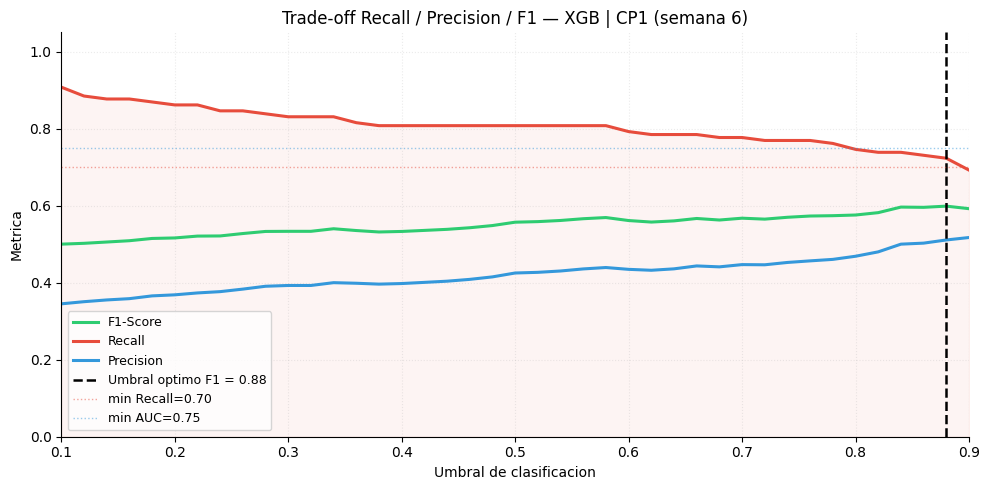

[PLOT] fig_umbral_cp1(semana6).png guardado

  MODELO GANADOR — CP2 (semana 11)
  Familia    : DT
  Feature set: S11_smoteenn
  Criterio   : AUC >= 0.75 -> max Recall -> F1 desempate
  AUC cumple : SI
  N features : 8
  Balanceo   : smoteenn
  Features   : ['parcial_2', 'delta_p2_p1', 'p1_vs_media', 'log_eng_p1', 'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema', 'parcial_1_tiempo_por_visita', 'era_encoded']
  Params     : {'min_samples_split': 15, 'min_samples_leaf': 8, 'max_depth': 2, 'criterion': 'entropy', 'class_weight': 'balanced', 'ccp_alpha': 0.02, 'random_state': 42}
  Umbral opt : 0.34

  METRICAS (media +/- std, 5 folds LOSO):
    AUC-ROC  : 0.866 +/- 0.030  [OK]
    Recall   : 0.932 +/- 0.083  [OK]
    Precision: 0.536
    F1-Score : 0.672 +/- 0.083
    Accuracy : 0.786
  DETALLE POR FOLD:
    202320.0: AUC=0.847  Rec=0.947  F1=0.590  Umbral=0.80
    202410.0: AUC=0.890  Rec=1.000  F1=0.667  Umbral=0.60
    202420.0: AUC=0.883  Rec=1.000  F1=0.653  Umbral=0.10
    20

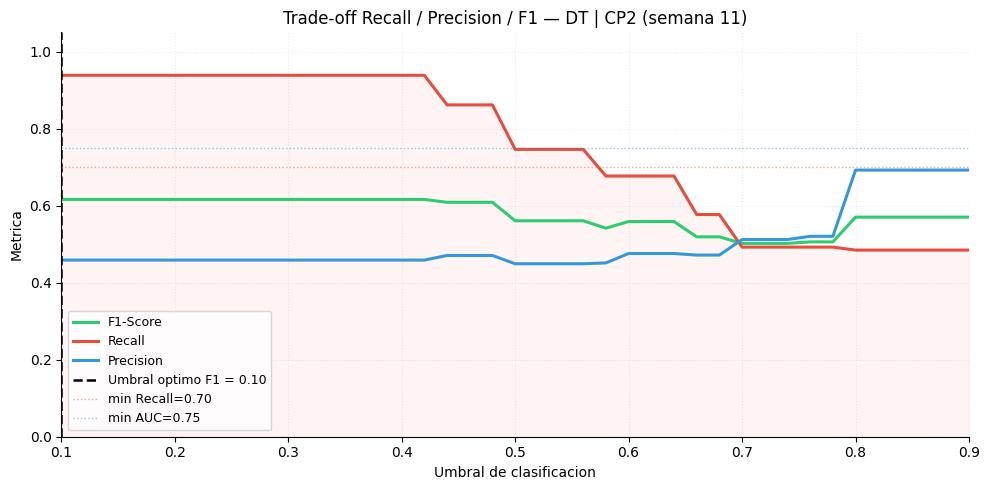

[PLOT] fig_umbral_cp2(semana11).png guardado


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# §10 — MODELO GANADOR: DOCUMENTACIÓN COMPLETA
# ═══════════════════════════════════════════════════════════════════════════════
def document_winner(all_dicts, df_master, cp_label):
    tags = ['LR', 'DT', 'RF', 'XGB']

    # Ganador: primer modelo en df_master (ya ordenado por Recall desc, F1 desc)
    # Solo considerar los que cumplen AUC >= 0.75
    aptos = df_master[df_master['OK_AUC'].str.startswith('SI')]
    winner_tag = aptos.iloc[0]['Modelo'] if len(aptos) > 0 else df_master.iloc[0]['Modelo']

    rd = dict(zip(tags, all_dicts))[winner_tag]
    best_sn, best, cumple = select_best(rd)
    res, cfg = best['res'], best['cfg']

    SP.out(f"\n{'='*72}")
    SP.out(f"  MODELO GANADOR — {cp_label}")
    SP.out(f"  Familia    : {winner_tag}")
    SP.out(f"  Feature set: {best_sn}")
    SP.out(f"  Criterio   : AUC >= 0.75 -> max Recall -> F1 desempate")
    SP.out(f"  AUC cumple : {'SI' if cumple else 'NO — relajado (ninguno supera 0.75)'}")
    SP.out(f"  N features : {len(cfg['features'])}")
    SP.out(f"  Balanceo   : {cfg['balanceo']}")
    SP.out(f"  Features   : {cfg['features']}")
    SP.out(f"  Params     : {best['params']}")
    SP.out(f"  Umbral opt : {res['t_m']:.2f}")
    SP.out(f"\n  METRICAS (media +/- std, 5 folds LOSO):")
    SP.out(f"    AUC-ROC  : {res['auc_m']:.3f} +/- {res['auc_s']:.3f}  "
           f"{'[OK]' if res['auc_m']>=0.75 else '[<MIN]'}")
    SP.out(f"    Recall   : {res['rec_m']:.3f} +/- {res['rec_s']:.3f}  "
           f"{'[OK]' if res['rec_m']>=0.70 else '[<MIN]'}")
    SP.out(f"    Precision: {res['pre_m']:.3f}")
    SP.out(f"    F1-Score : {res['f1_m']:.3f} +/- {res['f1_s']:.3f}")
    SP.out(f"    Accuracy : {res['acc_m']:.3f}")
    SP.out(f"  DETALLE POR FOLD:")
    for _, row in res['folds'].iterrows():
        SP.out(f"    {row['sem']}: AUC={row['auc']:.3f}  Rec={row['rec']:.3f}  "
               f"F1={row['f1']:.3f}  Umbral={row['t']:.2f}")
    SP.out('='*72)

    # Curva de umbral
    yt = np.array(res['yt']); yp = np.array(res['yp'])
    ts = np.arange(0.10, 0.91, 0.02)
    f1s  = [f1_score(yt, (yp >= t).astype(int), pos_label=1, zero_division=0) for t in ts]
    recs = [recall_score(yt, (yp >= t).astype(int), pos_label=1, zero_division=0) for t in ts]
    pres = [precision_score(yt, (yp >= t).astype(int), pos_label=1, zero_division=0) for t in ts]

    t_best = ts[np.argmax(f1s)]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ts, f1s,  lw=2.2, color='#2ECC71', label='F1-Score')
    ax.plot(ts, recs, lw=2.2, color='#E74C3C', label='Recall')
    ax.plot(ts, pres, lw=2.2, color='#3498DB', label='Precision')
    ax.axvline(t_best, color='black', ls='--', lw=1.8,
               label=f'Umbral optimo F1 = {t_best:.2f}')
    ax.axhline(0.70, color='#E74C3C', ls=':', lw=1, alpha=0.5, label='min Recall=0.70')
    ax.axhline(0.75, color='#3498DB', ls=':', lw=1, alpha=0.5, label='min AUC=0.75')
    ax.fill_between(ts, recs, 0, alpha=0.06, color='#E74C3C')
    ax.set(xlabel='Umbral de clasificacion', ylabel='Metrica',
           title=f'Trade-off Recall / Precision / F1 — {winner_tag} | {cp_label}')
    ax.set_xlim(0.1, 0.9); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9, framealpha=0.8); ax.grid(alpha=0.25, linestyle=':')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    fn = f"fig_umbral_{cp_label.replace(' ','').lower()}.png"
    plt.tight_layout(); plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show()
    SP.out(f"[PLOT] {fn} guardado")

document_winner([results_lr_cp1, results_dt_cp1, results_rf_cp1, results_xgb_cp1],
                df_master_cp1, "CP1 (semana 6)")
document_winner([results_lr_cp2, results_dt_cp2, results_rf_cp2, results_xgb_cp2],
                df_master_cp2, "CP2 (semana 11)")

# §11 — Tabla consolidada global y heatmap


[CONSOLIDADO CP1] 68 experimentos totales
 CP modelo                  set  n_feat balanceo   AUC  Recall  Prec    F1  Umbral
CP1     DT     S01_solo_parcial       1     none 0.827   0.751 0.539 0.624    0.50
CP1     DT            S07_smote       5    smote 0.807   0.741 0.560 0.624    0.37
CP1     DT         S07_smoteenn       5 smoteenn 0.808   0.749 0.561 0.623    0.37
CP1     DT         S11_smoteenn       7 smoteenn 0.808   0.727 0.574 0.613    0.72
CP1     DT          S05_eng_log       3     none 0.785   0.683 0.565 0.611    0.30
CP1     DT        S04_eng_total       3     none 0.785   0.683 0.565 0.611    0.30
CP1     DT     S09_eng_completo       7     none 0.783   0.682 0.569 0.608    0.18
CP1     DT         S08_smoteenn       6 smoteenn 0.795   0.783 0.523 0.606    0.56
CP1     DT      S02_parcial_era       2     none 0.810   0.783 0.503 0.605    0.35
CP1     DT         S11_completo       7     none 0.786   0.648 0.612 0.604    0.55
CP1     DT         S08_base_est       6     

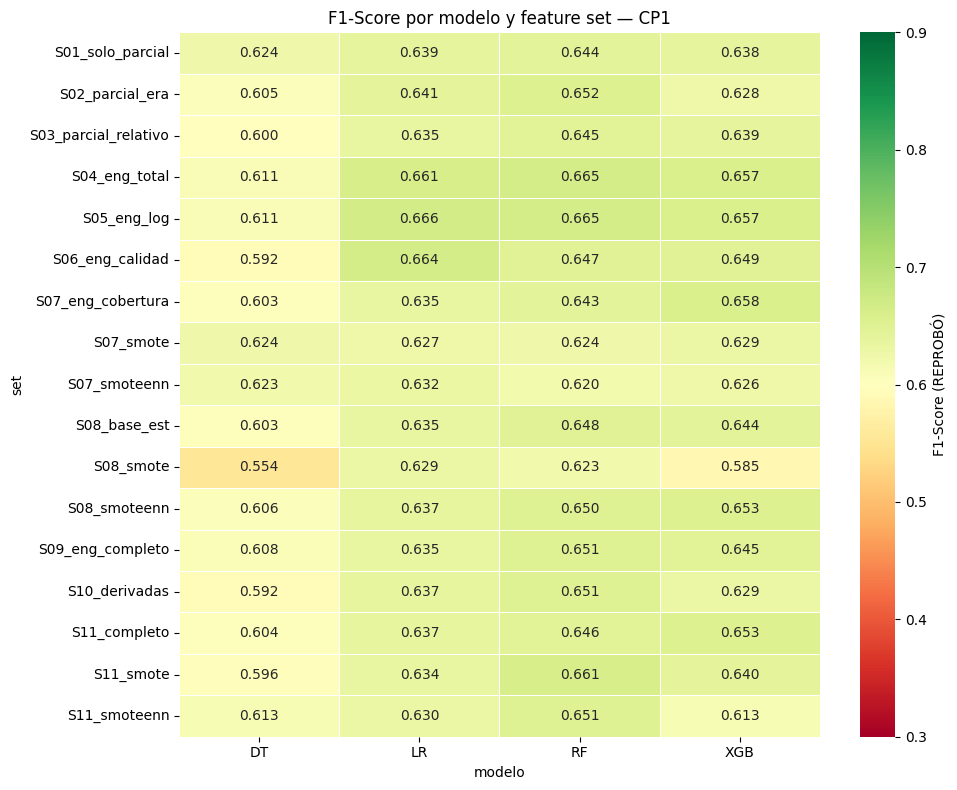

[PLOT] fig_heatmap_f1_cp1.png guardado

[CONSOLIDADO CP2] 80 experimentos totales
 CP modelo                 set  n_feat balanceo   AUC  Recall  Prec    F1  Umbral
CP2     DT           S07_smote      10    smote 0.906   0.853 0.688 0.749    0.42
CP2     DT   S01_dos_parciales       3     none 0.913   0.762 0.744 0.747    0.44
CP2     DT        S08_eng_evol       4     none 0.911   0.822 0.681 0.736    0.39
CP2     DT        S07_base_est      10     none 0.911   0.871 0.660 0.735    0.48
CP2     DT       S10_eng_ambos       8     none 0.909   0.822 0.679 0.734    0.40
CP2     DT      S09_eng_p2_det       8     none 0.904   0.822 0.677 0.732    0.40
CP2     DT       S03_academico       5     none 0.905   0.877 0.639 0.730    0.48
CP2     DT  S05_acad_tendencia       5     none 0.884   0.830 0.672 0.730    0.36
CP2     DT        S12_completo      12     none 0.894   0.842 0.668 0.724    0.49
CP2     DT           S11_smote       8    smote 0.902   0.782 0.693 0.719    0.58
CP2     DT      

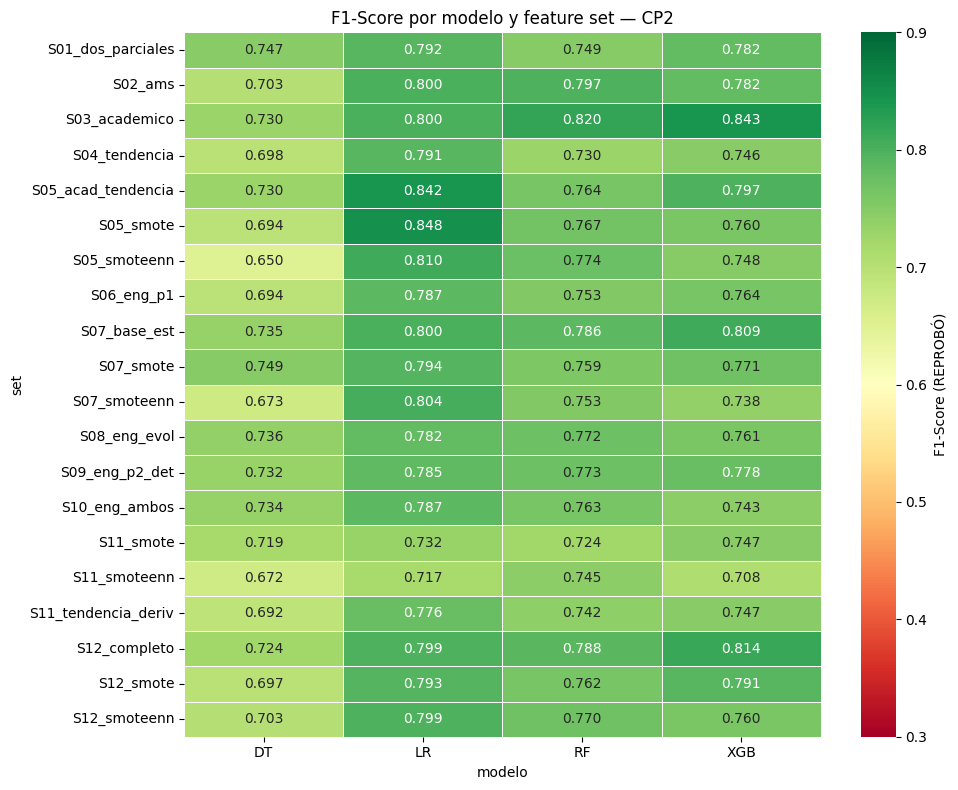

[PLOT] fig_heatmap_f1_cp2.png guardado


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# §11 — CONSOLIDADO GLOBAL
# ═══════════════════════════════════════════════════════════════════════════════
def full_consolidate(cp_label, lr, dt, rf, xgb):
    dfs = [build_table(lr,'LR'), build_table(dt,'DT'),
           build_table(rf,'RF'), build_table(xgb,'XGB')]
    df_all = pd.concat(dfs, ignore_index=True).sort_values(['modelo','F1'],
                                                            ascending=[True,False])
    df_all['CP'] = cp_label
    SP.out(f"\n[CONSOLIDADO {cp_label}] {len(df_all)} experimentos totales")
    SP.out(df_all[['CP','modelo','set','n_feat','balanceo',
                   'AUC','Recall','Prec','F1','Umbral']].to_string(index=False))
    fn_csv = f"resultados_{cp_label.replace(' ','_').lower()}.csv"
    df_all.to_csv(fn_csv, index=False)
    SP.out(f"[EXPORT] {fn_csv} guardado")

    # Heatmap F1 × modelo × set
    pivot = df_all.pivot_table(index='set', columns='modelo', values='F1', aggfunc='max')
    fig, ax = plt.subplots(figsize=(10, max(8, len(pivot)*0.4)))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.3, vmax=0.9, linewidths=0.5, ax=ax,
                cbar_kws={'label': 'F1-Score (REPROBÓ)'})
    ax.set_title(f'F1-Score por modelo y feature set — {cp_label}', fontsize=12)
    fn_heat = f"fig_heatmap_f1_{cp_label.replace(' ','_').lower()}.png"
    plt.tight_layout(); plt.savefig(fn_heat, dpi=150, bbox_inches='tight'); plt.show()
    SP.out(f"[PLOT] {fn_heat} guardado")
    return df_all

df_all_cp1 = full_consolidate("CP1", results_lr_cp1, results_dt_cp1,
                                results_rf_cp1, results_xgb_cp1)
df_all_cp2 = full_consolidate("CP2", results_lr_cp2, results_dt_cp2,
                                results_rf_cp2, results_xgb_cp2)